In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/akntkmds/all-seperate-datasets/dataset_split_tensile_strength.csv
/kaggle/input/datasets/akntkmds/all-seperate-datasets/dataset_compressive_strength.csv
/kaggle/input/datasets/akntkmds/all-seperate-datasets/dataset_flexural_strength.csv
/kaggle/input/datasets/akntkmds/all-seperate-datasets/dataset_water_absorption_28.csv
/kaggle/input/datasets/akntkmds/all-seperate-datasets/dataset_rcpt_28.csv


In [2]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 1: Data Loading, Basic Summary & Type Verification
# =============================================================================
# Compatible with: Kaggle Notebooks | Python 3.9+
# Dataset: dataset_compressive_strength.csv
# Target variable: compressive_strength (%)
# =============================================================================

# ------------------------------------------------------------
# 1.1  Import libraries
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Reproducibility seed (used throughout all steps)
SEED = 42

# Plotting style
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Libraries loaded successfully.")

# ------------------------------------------------------------
# 1.2  Dataset configuration
# ------------------------------------------------------------
DATASET_FILE  = 'dataset_compressive_strength.csv'
TARGET_COL    = 'compressive_strength'
DATA_PATH     = f'/kaggle/input/datasets/akntkmds/all-seperate-datasets/{DATASET_FILE}'
PROPERTY_NAME = 'Compressive Strength (MPa)'

# ------------------------------------------------------------
# 1.3  Load dataset
# ------------------------------------------------------------
df_raw = pd.read_csv(DATA_PATH)

print(f"\nDataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

# ------------------------------------------------------------
# 1.4  Column reference
# ------------------------------------------------------------
# Auto-detect features as all columns except the target
FEATURES = [col for col in df_raw.columns if col != TARGET_COL]
TARGET   = TARGET_COL

ALL_COLS = FEATURES + [TARGET]

print(f"\nTarget column : {TARGET}")
print(f"Feature columns ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  • {f}")

# ------------------------------------------------------------
# 1.5  Data type verification
# ------------------------------------------------------------
print("\n── Column dtypes ──────────────────────────────────────")
dtype_df = df_raw.dtypes.reset_index()
dtype_df.columns = ["Column", "dtype"]
dtype_df["Expected"] = "float64"
dtype_df["OK"] = dtype_df["dtype"].astype(str) == dtype_df["Expected"]
print(dtype_df.to_string(index=False))

unexpected = dtype_df[~dtype_df["OK"]]
if unexpected.empty:
    print("\nAll columns are float64. No type conversion needed.")
else:
    print("\nUnexpected dtypes found — converting:")
    for col in unexpected["Column"]:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
        print(f"  {col} → converted to float64 (non-numeric values become NaN)")

# ------------------------------------------------------------
# 1.6  Basic dataset summary
# ------------------------------------------------------------
print("\n── Shape ───────────────────────────────────────────────")
print(f"  Total rows      : {df_raw.shape[0]}")
print(f"  Total columns   : {df_raw.shape[1]}")

print(f"\n── Labeled rows (target not NaN) ───────────────────────")
labeled = df_raw[TARGET].notna().sum()
total   = len(df_raw)
print(f"  Rows with {TARGET} : {labeled} / {total}  "
      f"({labeled/total*100:.1f}%)")
print(f"  Rows WITHOUT target            : {total - labeled} (will be excluded from modelling)")

print(f"\n── Descriptive statistics (labeled rows only) ──────────")
df_labeled = df_raw.dropna(subset=[TARGET]).copy()
desc = df_labeled[ALL_COLS].describe().T
desc.columns = ["n", "mean", "std", "min", "25%", "50%", "75%", "max"]
desc["n"] = desc["n"].astype(int)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 120)
print(desc.to_string())

# ------------------------------------------------------------
# 1.7  Missing values across all rows
# ------------------------------------------------------------
print(f"\n── Missing values (full dataset, all {total} rows) ────────")
miss = pd.DataFrame({
    "Missing":   df_raw.isnull().sum(),
    "Missing %": (df_raw.isnull().mean() * 100).round(1),
    "Present":   df_raw.notnull().sum(),
}).sort_values("Missing %", ascending=False)
print(miss.to_string())

# ------------------------------------------------------------
# 1.8  Save working copy for subsequent steps
# ------------------------------------------------------------
# df_labeled → labeled rows used for modelling
# df_raw     → kept for reference

print(f"\nWorking dataset (labeled rows): df_labeled — {df_labeled.shape}")
print(f"Property: {PROPERTY_NAME}")
print("Step 1 complete. Proceed to Step 2: Data Quality Check.")

Libraries loaded successfully.

Dataset loaded: 1169 rows × 10 columns

Target column : compressive_strength
Feature columns (9):
  • rha_replacement_pct
  • water_binder_ratio
  • mean_particle_size
  • fineness_passing_45um_pct
  • cement_kg_m3
  • fine_aggregate
  • coarse_aggregate
  • silica_content
  • calcium_dioxide

── Column dtypes ──────────────────────────────────────
                   Column   dtype Expected   OK
      rha_replacement_pct float64  float64 True
       water_binder_ratio float64  float64 True
       mean_particle_size float64  float64 True
fineness_passing_45um_pct float64  float64 True
             cement_kg_m3 float64  float64 True
           fine_aggregate float64  float64 True
         coarse_aggregate float64  float64 True
           silica_content float64  float64 True
          calcium_dioxide float64  float64 True
     compressive_strength float64  float64 True

All columns are float64. No type conversion needed.

── Shape ──────────────────────────

In [3]:
DROP_COLS = ['mean_particle_size', 'fineness_passing_45um_pct' ,  'calcium_dioxide', 'silica_content']
df_labeled = df_labeled.drop(columns=DROP_COLS, errors='ignore')
FEATURES   = [col for col in df_labeled.columns if col != TARGET]

In [4]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 2: Data Quality Check
# =============================================================================
# Requires: df_labeled, TARGET, PROPERTY_NAME from Step 1
# =============================================================================

# ------------------------------------------------------------
# Redefine FEATURES and ALL_COLS after column drops
# (always run this at the top of every step)
# ------------------------------------------------------------
FEATURES = [col for col in df_labeled.columns if col != TARGET]
ALL_COLS = FEATURES + [TARGET]

print(f"Active features ({len(FEATURES)}): {FEATURES}")
print(f"Target: {TARGET}\n")

# ------------------------------------------------------------
# 2.1  Missing value analysis
# ------------------------------------------------------------
print("── 2.1  Missing Value Analysis ─────────────────────────")

miss = pd.DataFrame({
    "Missing":   df_labeled.isnull().sum(),
    "Missing %": (df_labeled.isnull().mean() * 100).round(2),
    "Present":   df_labeled.notnull().sum(),
}).sort_values("Missing %", ascending=False)

print(miss.to_string())

total_missing = df_labeled.isnull().sum().sum()
if total_missing == 0:
    print("\nNo missing values found in the labeled dataset. Ready to proceed.")
else:
    print(f"\nTotal missing cells : {total_missing}")
    print("These will be handled inside the sklearn Pipeline in Step 6 (median imputation).")
    print("Do NOT impute here — imputer must be fit on train data only to avoid leakage.")

# ------------------------------------------------------------
# 2.2  Duplicate detection
# ------------------------------------------------------------
print("\n── 2.2  Duplicate Detection ────────────────────────────")

n_dupes = df_labeled.duplicated().sum()
print(f"Exact duplicate rows : {n_dupes}")

if n_dupes > 0:
    print("\nDuplicate rows:")
    print(df_labeled[df_labeled.duplicated(keep=False)].to_string())
    df_labeled = df_labeled.drop_duplicates().reset_index(drop=True)
    print(f"\nDuplicates removed. New shape: {df_labeled.shape}")
else:
    print("No exact duplicates found.")

feat_dupes = df_labeled.duplicated(subset=FEATURES).sum()
print(f"\nRows with identical features but potentially different target : {feat_dupes}")
if feat_dupes > 0:
    print("These are kept — same mix design may have multiple experimental readings.")

# ------------------------------------------------------------
# 2.3  Data range validation
# ------------------------------------------------------------
print("\n── 2.3  Data Range Validation ──────────────────────────")

EXPECTED_RANGES = {
    "rha_replacement_pct": (0,   80),
    "water_binder_ratio":  (0.1,  1.0),
    "cement_kg_m3":        (100, 700),
    "fine_aggregate":      (100, 1200),
    "coarse_aggregate":    (0,   1600),
    TARGET:                (0, 120),
}

range_report = []
for col, (lo, hi) in EXPECTED_RANGES.items():
    if col not in df_labeled.columns:
        continue
    n_below = (df_labeled[col] < lo).sum()
    n_above = (df_labeled[col] > hi).sum()
    flag = "OK" if (n_below + n_above) == 0 else "CHECK"
    range_report.append({
        "Column":       col,
        "Min (data)":   round(df_labeled[col].min(), 3),
        "Max (data)":   round(df_labeled[col].max(), 3),
        "Expected min": lo,
        "Expected max": hi,
        "Below range":  n_below,
        "Above range":  n_above,
        "Status":       flag,
    })

range_df = pd.DataFrame(range_report)
print(range_df.to_string(index=False))

flagged = range_df[range_df["Status"] == "CHECK"]
if flagged.empty:
    print("\nAll values within expected physical ranges.")
else:
    print(f"\n{len(flagged)} column(s) have out-of-range values — review before modelling.")

# ------------------------------------------------------------
# 2.4  Zero-value check
# ------------------------------------------------------------
print("\n── 2.4  Zero-Value Check ───────────────────────────────")

zero_counts = (df_labeled[ALL_COLS] == 0).sum()
zero_counts = zero_counts[zero_counts > 0]

if zero_counts.empty:
    print("No zero values found.")
else:
    print("Columns containing zeros:")
    print(zero_counts.to_string())
    print("Note: rha_replacement_pct = 0 is physically valid (control mix).")

# ------------------------------------------------------------
# 2.5  Constant / near-constant column check
# ------------------------------------------------------------
print("\n── 2.5  Constant / Near-Constant Columns ───────────────")

nunique       = df_labeled[FEATURES].nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
low_var_cols  = nunique[(nunique > 1) & (nunique <= 5)].index.tolist()

if constant_cols:
    print(f"Constant columns (drop these): {constant_cols}")
    df_labeled = df_labeled.drop(columns=constant_cols)
    FEATURES   = [col for col in df_labeled.columns if col != TARGET]
    ALL_COLS   = FEATURES + [TARGET]
else:
    print("No constant columns found.")

if low_var_cols:
    print(f"Low-variance columns (≤5 unique values) — review: {low_var_cols}")
else:
    print("No low-variance columns found.")

# ------------------------------------------------------------
# 2.6  Summary report
# ------------------------------------------------------------
print("\n── 2.6  Quality Summary ────────────────────────────────")
print(f"  Final shape after quality checks : {df_labeled.shape}")
print(f"  Features                         : {len(FEATURES)}")
print(f"  Target                           : {TARGET} ({PROPERTY_NAME})")
print(f"  Missing values remaining         : {df_labeled.isnull().sum().sum()}")
print(f"  Duplicates removed               : {n_dupes}")
print("\nStep 2 complete. Proceed to Step 3: Exploratory Data Analysis.")

Active features (5): ['rha_replacement_pct', 'water_binder_ratio', 'cement_kg_m3', 'fine_aggregate', 'coarse_aggregate']
Target: compressive_strength

── 2.1  Missing Value Analysis ─────────────────────────
                      Missing  Missing %  Present
water_binder_ratio          4      0.580      690
cement_kg_m3                4      0.580      690
coarse_aggregate            4      0.580      690
fine_aggregate              4      0.580      690
rha_replacement_pct         0      0.000      694
compressive_strength        0      0.000      694

Total missing cells : 16
These will be handled inside the sklearn Pipeline in Step 6 (median imputation).
Do NOT impute here — imputer must be fit on train data only to avoid leakage.

── 2.2  Duplicate Detection ────────────────────────────
Exact duplicate rows : 29

Duplicate rows:
     rha_replacement_pct  water_binder_ratio  cement_kg_m3  fine_aggregate  coarse_aggregate  compressive_strength
10                 0.000               0.

── 3.1  Histograms + KDE ───────────────────────────────


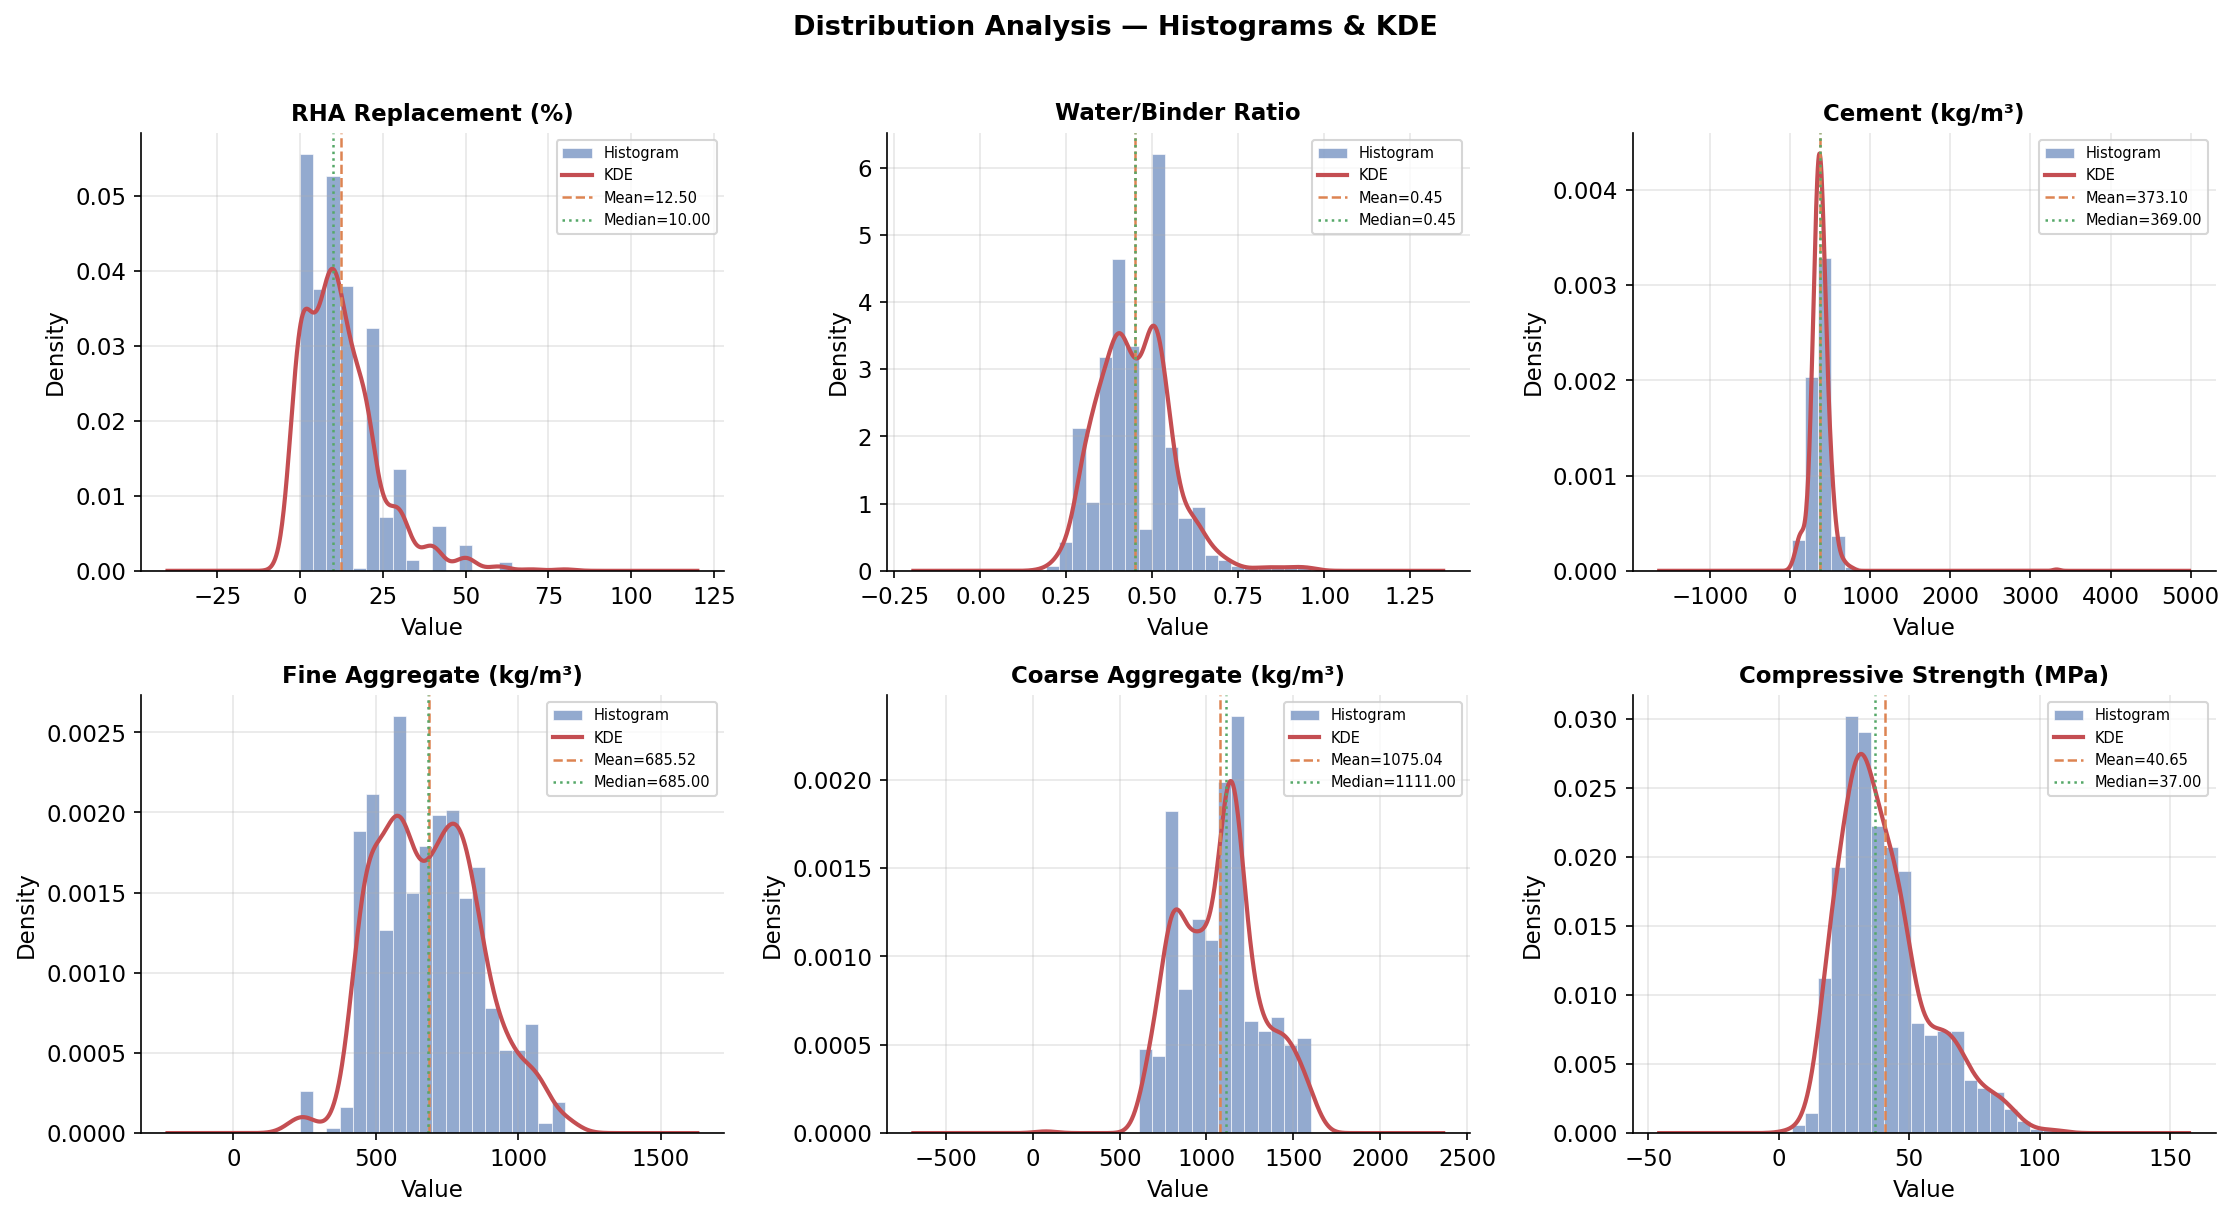

Saved: fig_3_1_histograms_kde.png

── 3.2  Boxplots ───────────────────────────────────────


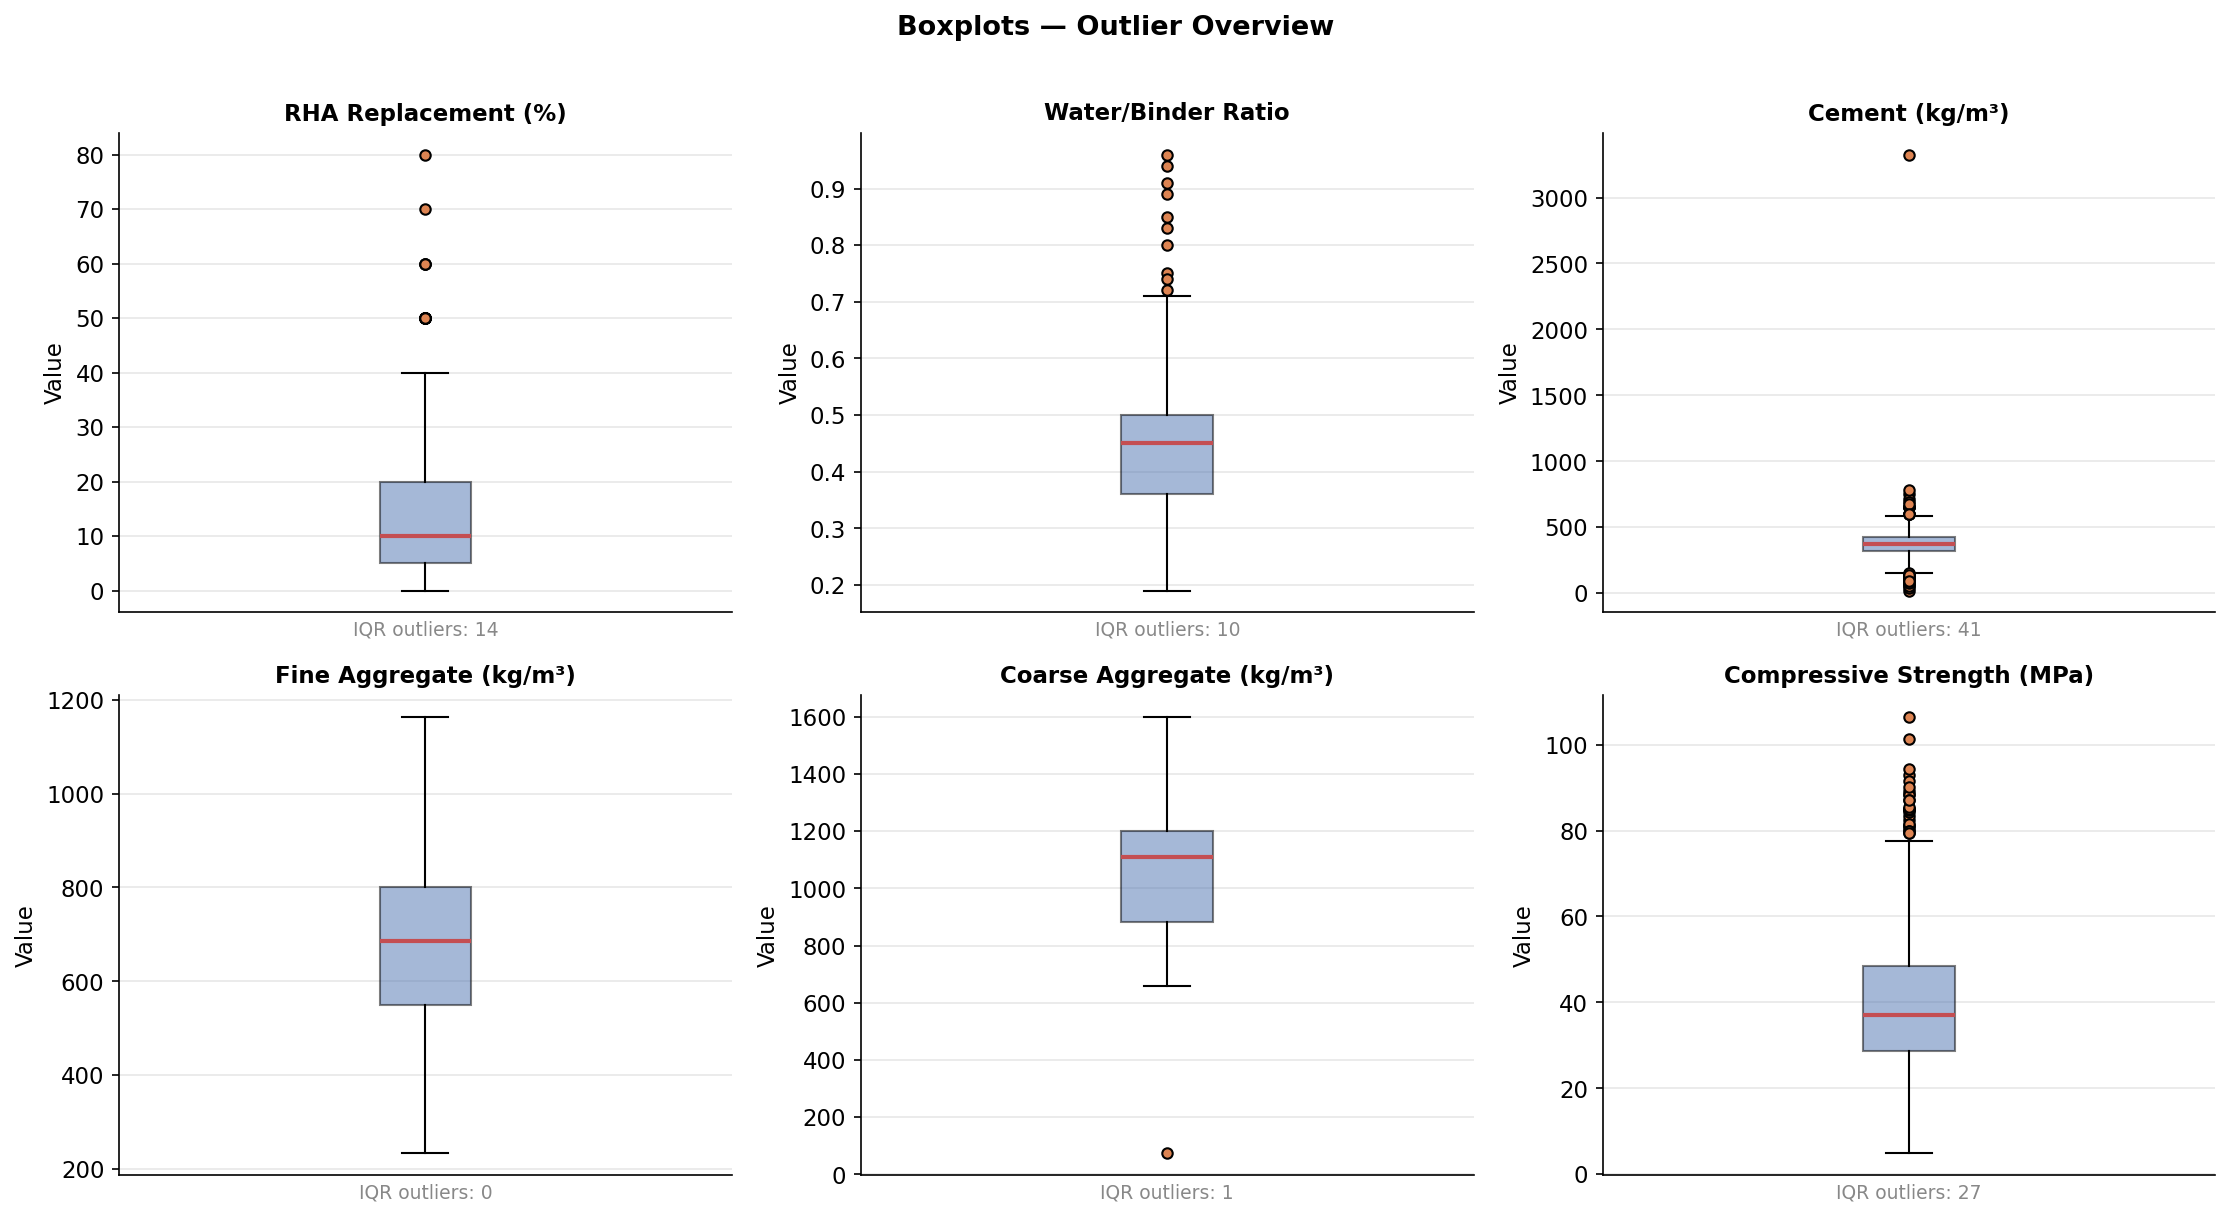

Saved: fig_3_2_boxplots.png

── 3.3  Pearson Correlation Heatmap ────────────────────


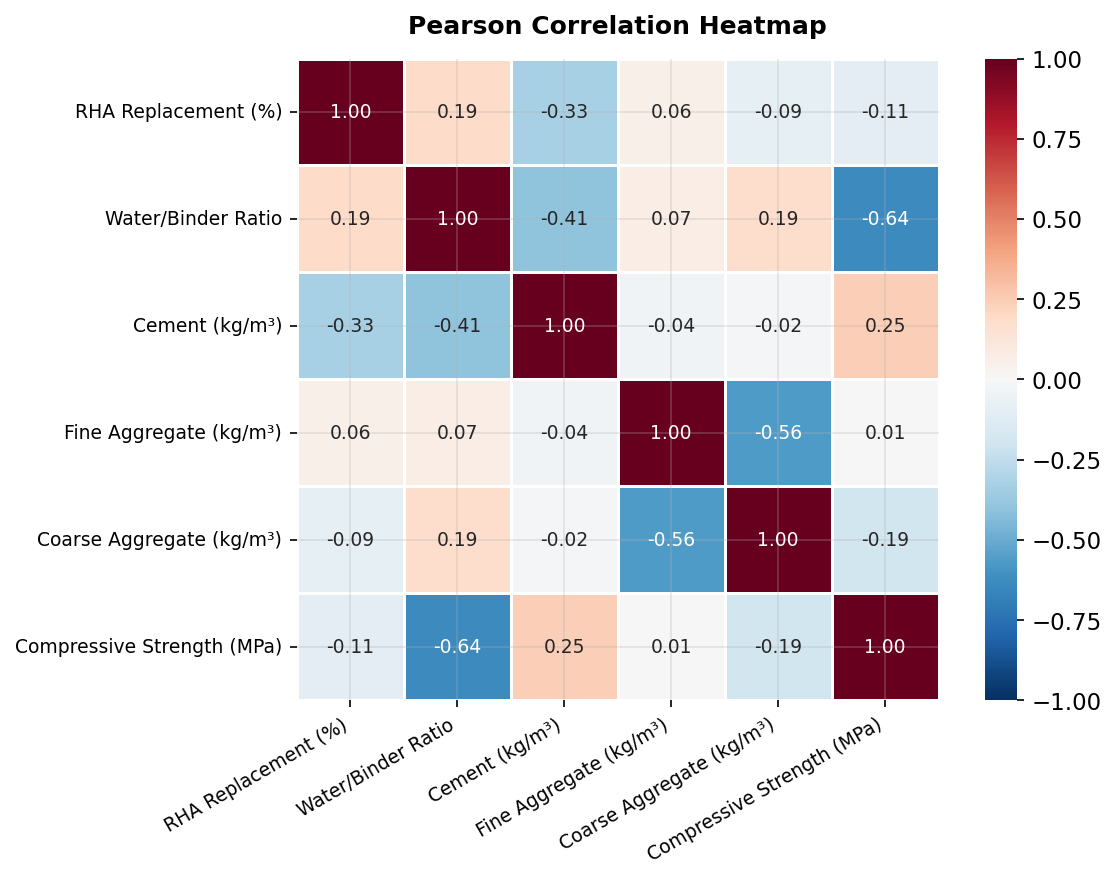

Saved: fig_3_3_pearson_heatmap.png

Pearson correlation with compressive_strength (sorted):
water_binder_ratio    -0.639
cement_kg_m3           0.248
coarse_aggregate      -0.190
rha_replacement_pct   -0.109
fine_aggregate         0.007

── 3.4  Spearman Correlation Heatmap ───────────────────


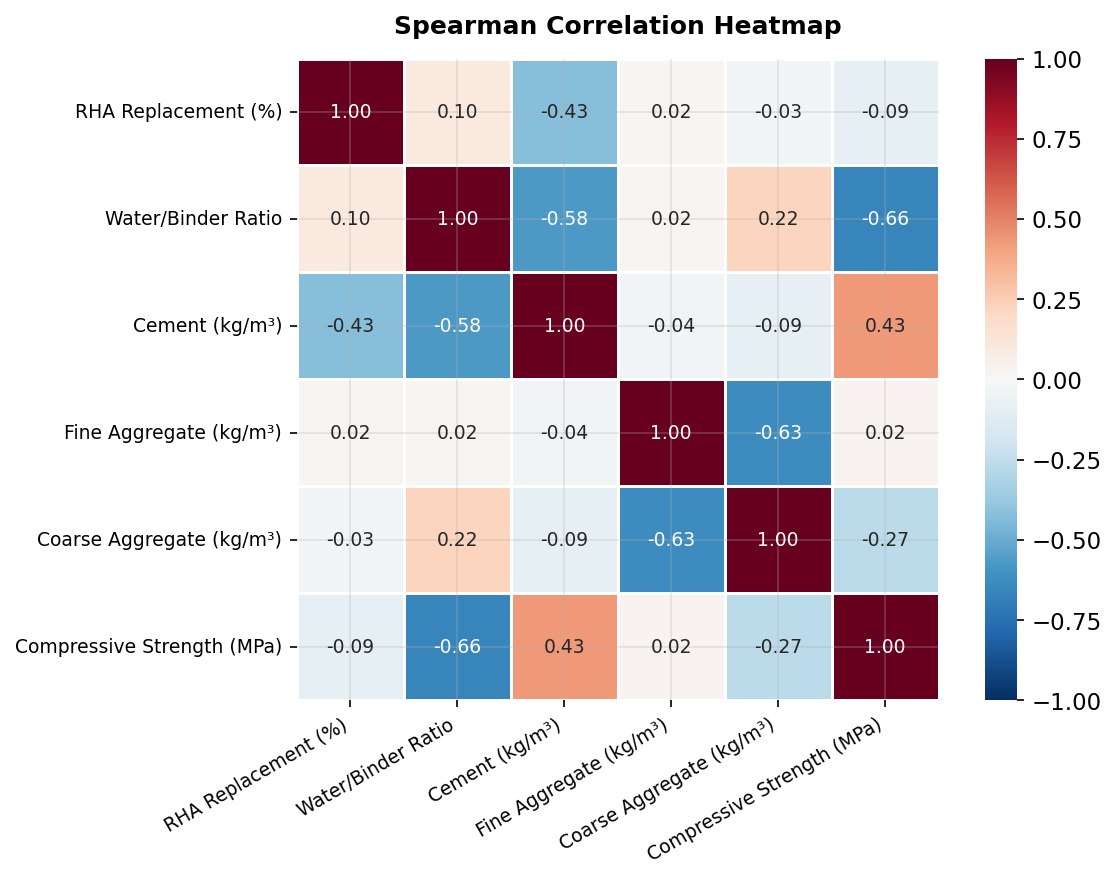

Saved: fig_3_4_spearman_heatmap.png

Spearman correlation with compressive_strength (sorted):
water_binder_ratio    -0.662
cement_kg_m3           0.434
coarse_aggregate      -0.267
rha_replacement_pct   -0.092
fine_aggregate         0.024

── 3.5  Scatter Plots vs Target ────────────────────────


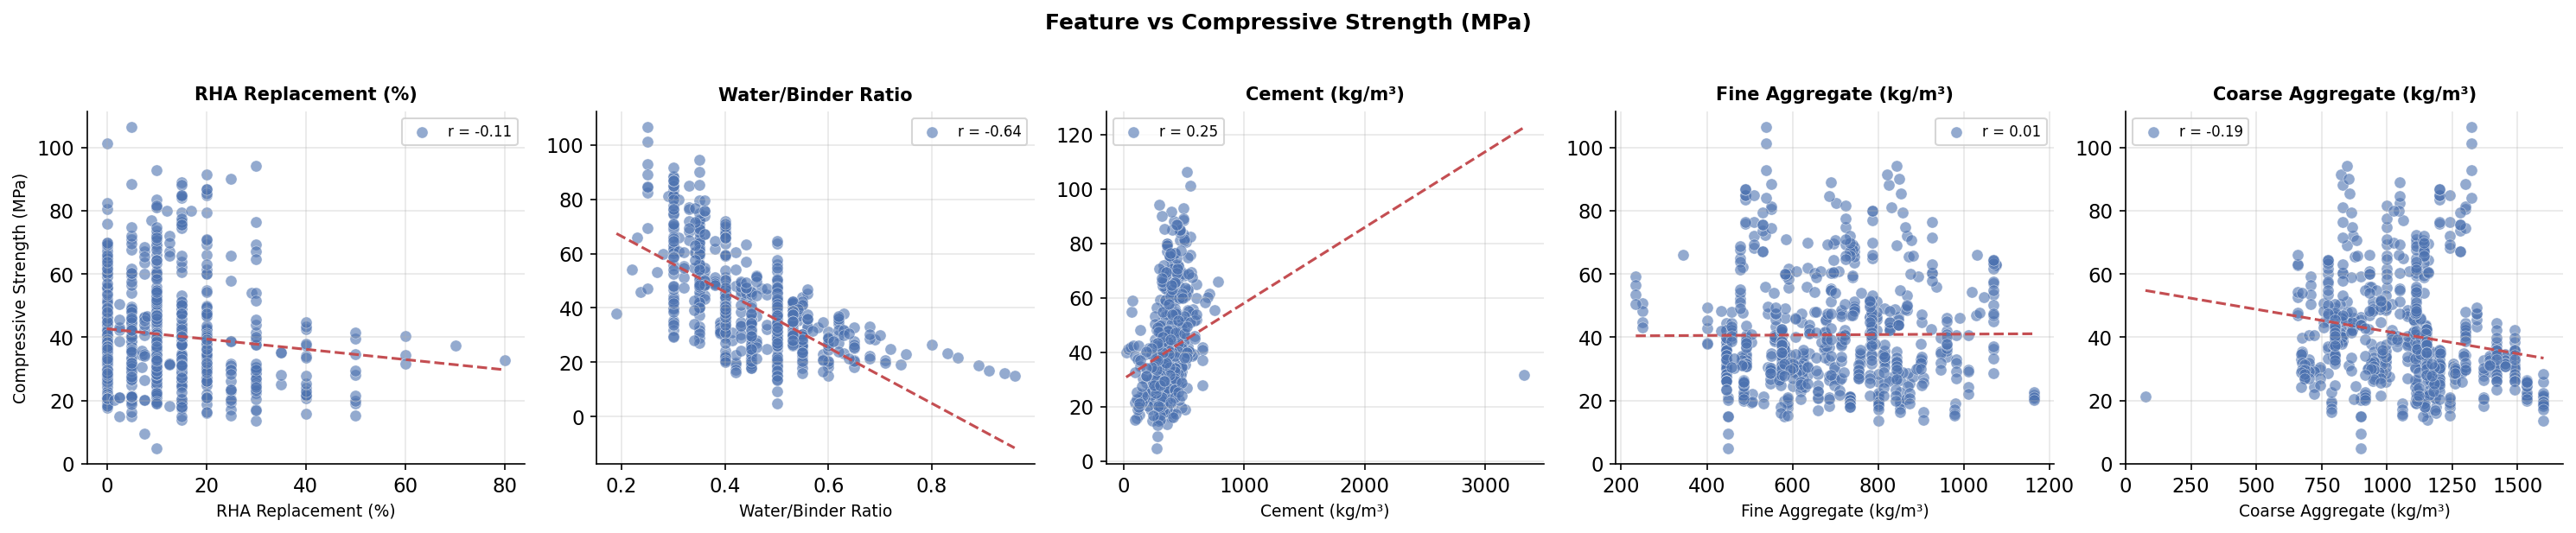

Saved: fig_3_5_scatter_vs_target.png

── 3.6  Pairplot ───────────────────────────────────────


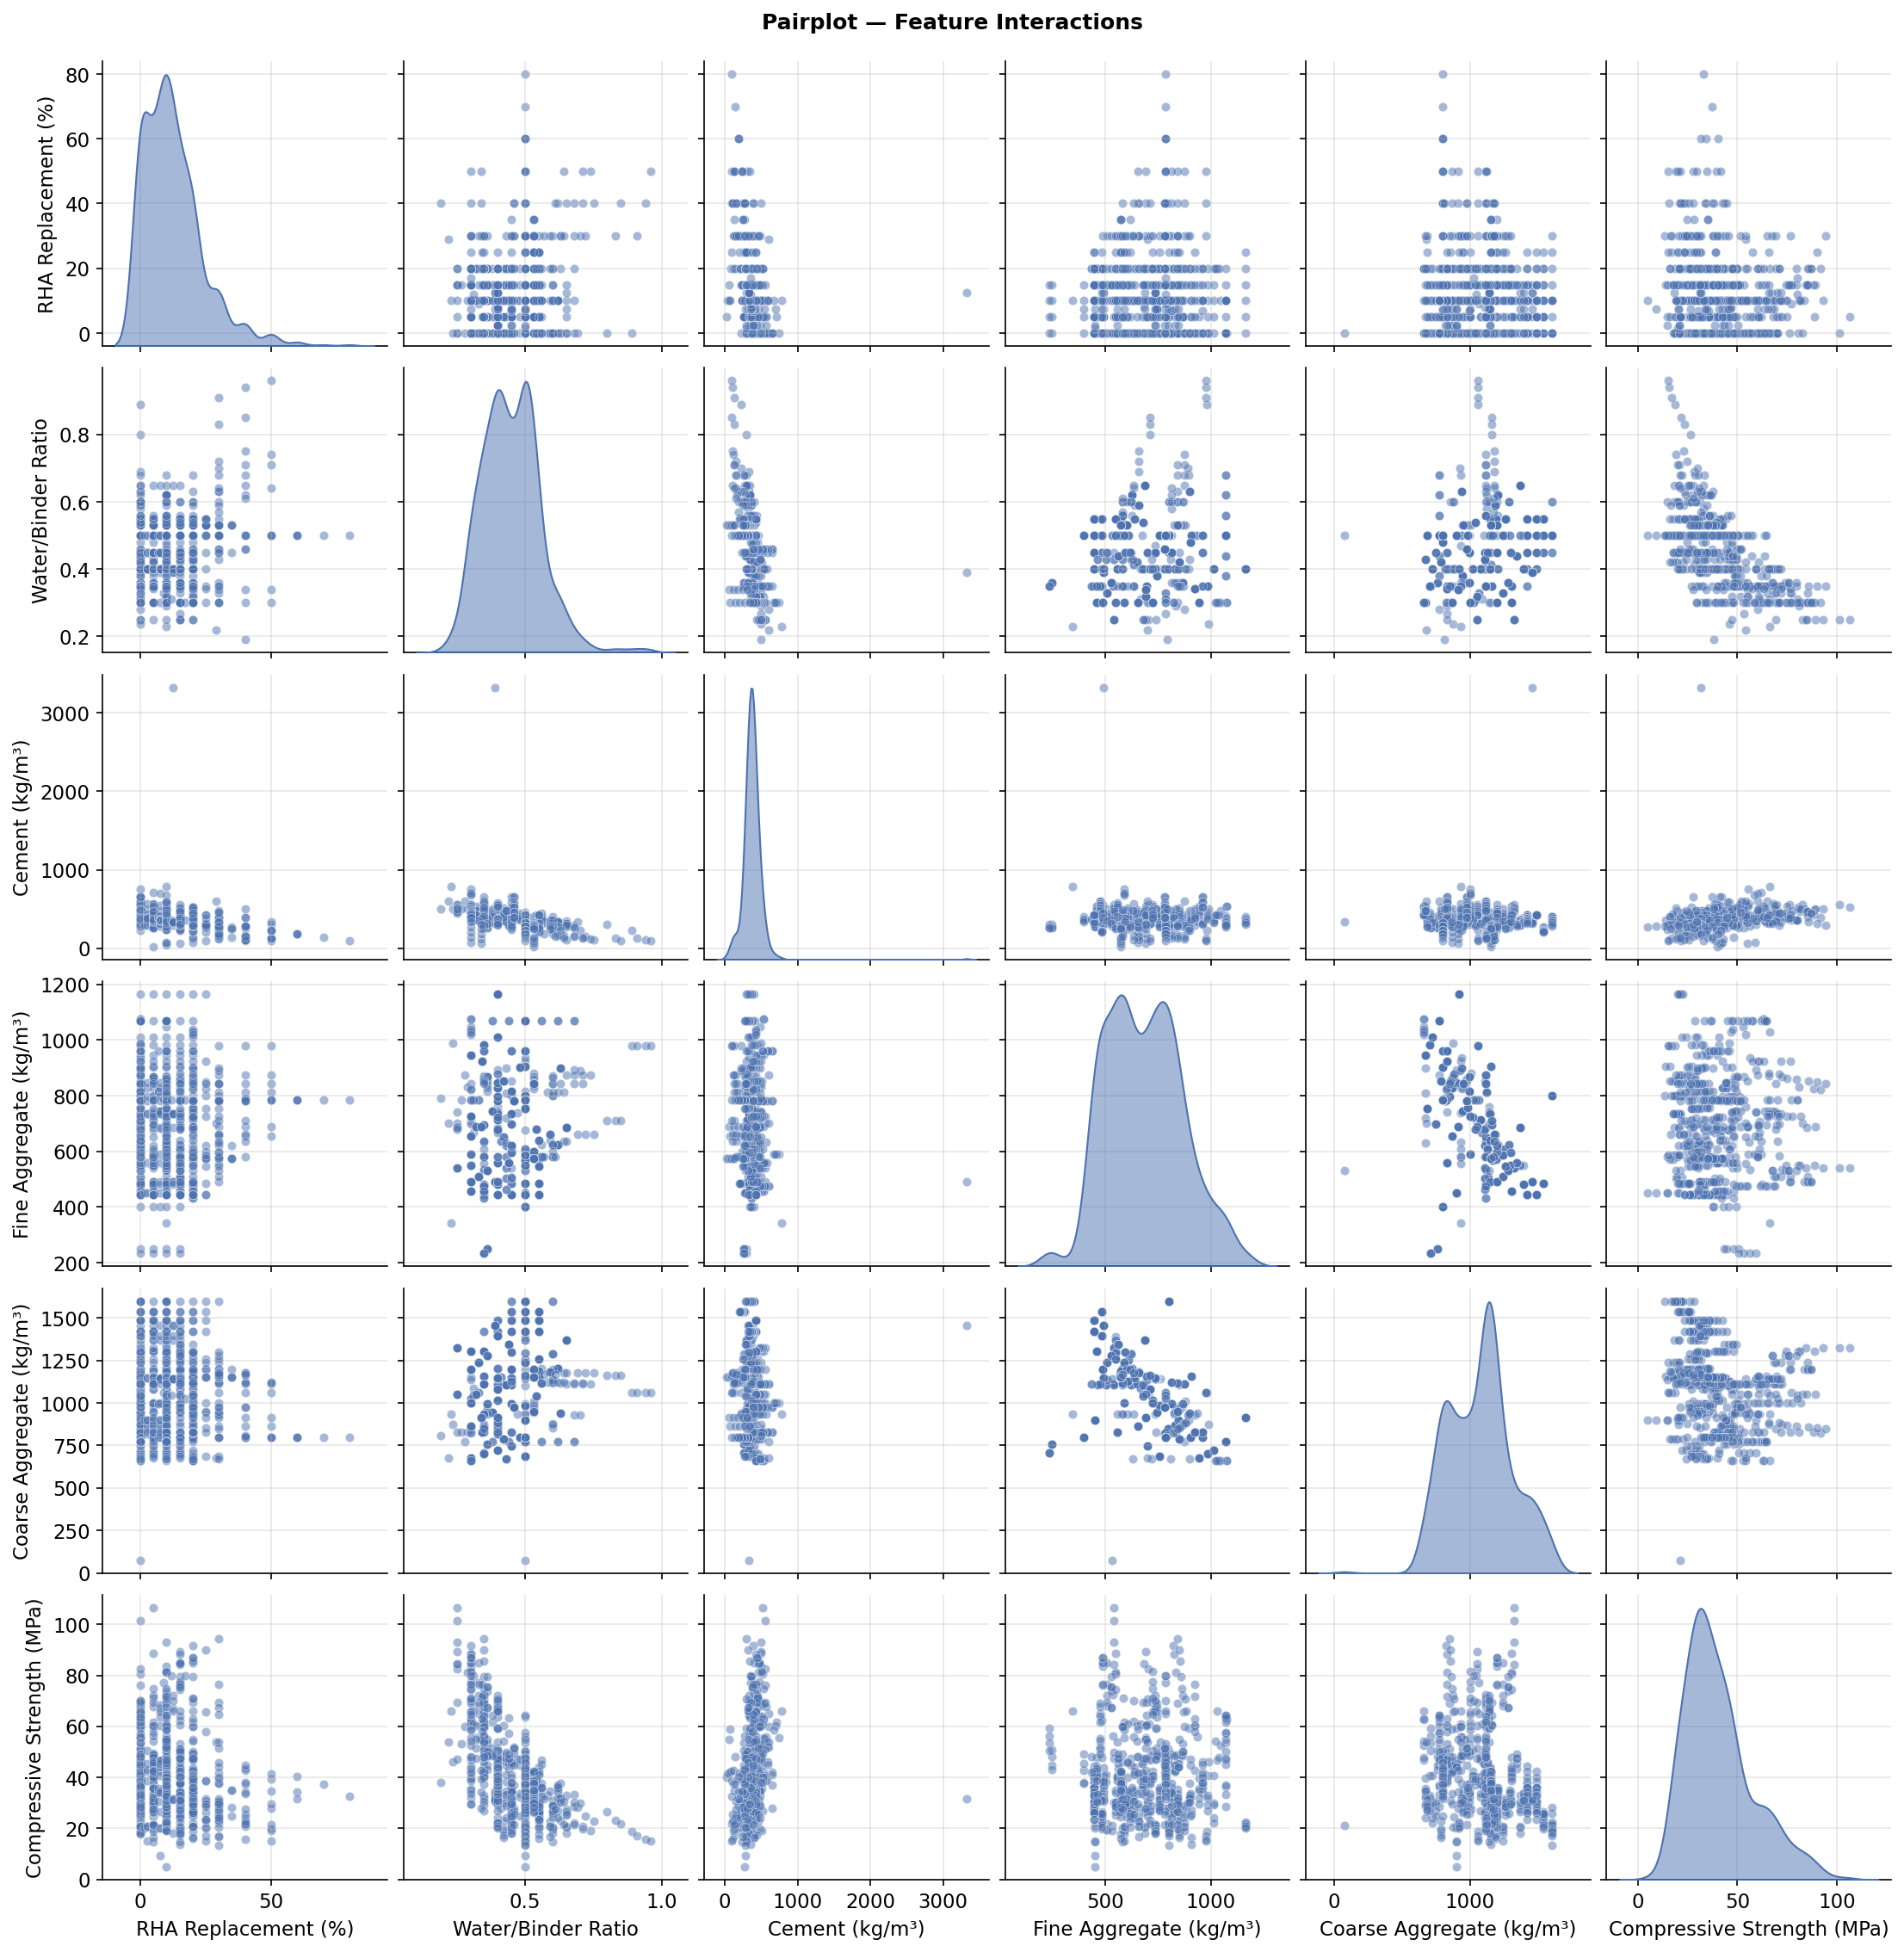

Saved: fig_3_6_pairplot.png

── 3.7  Target Variable Summary ───────────────────────
  Mean   : 40.648 MPa
  Median : 37.000 MPa
  Std    : 17.254 MPa
  Min    : 4.960 MPa
  Max    : 106.480 MPa
  Skew   : 0.964
  Kurt   : 0.609

Step 3 complete. Proceed to Step 4: Skewness & Normality Analysis.


In [5]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 3: Exploratory Data Analysis (EDA)
# =============================================================================
# Requires: df_labeled, FEATURES, TARGET, ALL_COLS, PROPERTY_NAME from Step 2
# =============================================================================

# ------------------------------------------------------------
# Redefine FEATURES and ALL_COLS (run at top of every step)
# ------------------------------------------------------------
FEATURES = [col for col in df_labeled.columns if col != TARGET]
ALL_COLS = FEATURES + [TARGET]

# Friendly display names for axis labels
COL_LABELS = {
    "rha_replacement_pct": "RHA Replacement (%)",
    "water_binder_ratio":  "Water/Binder Ratio",
    "cement_kg_m3":        "Cement (kg/m³)",
    "fine_aggregate":      "Fine Aggregate (kg/m³)",
    "coarse_aggregate":    "Coarse Aggregate (kg/m³)",
    TARGET:                PROPERTY_NAME,
}

# ------------------------------------------------------------
# 3.1  Distribution analysis — Histograms + KDE
# ------------------------------------------------------------
print("── 3.1  Histograms + KDE ───────────────────────────────")

n_cols = 3
n_rows = int(np.ceil(len(ALL_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    ax = axes[i]
    data = df_labeled[col].dropna()
    ax.hist(data, bins=20, color="#4C72B0", alpha=0.6, edgecolor="white",
            linewidth=0.5, density=True, label="Histogram")
    data.plot.kde(ax=ax, color="#C44E52", linewidth=2, label="KDE")
    ax.set_title(COL_LABELS.get(col, col), fontsize=11, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color="#DD8452", linestyle="--", linewidth=1.2,
               label=f"Mean={mean_val:.2f}")
    ax.axvline(median_val, color="#55A868", linestyle=":",  linewidth=1.2,
               label=f"Median={median_val:.2f}")
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution Analysis — Histograms & KDE", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_3_1_histograms_kde.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_3_1_histograms_kde.png")

# ------------------------------------------------------------
# 3.2  Boxplots
# ------------------------------------------------------------
print("\n── 3.2  Boxplots ───────────────────────────────────────")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    ax = axes[i]
    data = df_labeled[col].dropna()
    bp = ax.boxplot(data, patch_artist=True, vert=True,
                    medianprops=dict(color="#C44E52", linewidth=2),
                    boxprops=dict(facecolor="#4C72B0", alpha=0.5),
                    flierprops=dict(marker="o", markerfacecolor="#DD8452",
                                    markersize=5, linestyle="none"))
    ax.set_title(COL_LABELS.get(col, col), fontsize=11, fontweight="bold")
    ax.set_ylabel("Value")
    ax.set_xticks([])

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    ax.set_xlabel(f"IQR outliers: {n_out}", fontsize=9, color="#888")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — Outlier Overview", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_3_2_boxplots.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_3_2_boxplots.png")

# ------------------------------------------------------------
# 3.3  Pearson correlation heatmap
# ------------------------------------------------------------
print("\n── 3.3  Pearson Correlation Heatmap ────────────────────")

corr_pearson = df_labeled[ALL_COLS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

sns.heatmap(
    corr_pearson,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    square=True, ax=ax,
    xticklabels=[COL_LABELS.get(c, c) for c in corr_pearson.columns],
    yticklabels=[COL_LABELS.get(c, c) for c in corr_pearson.index],
)
ax.set_title("Pearson Correlation Heatmap", fontsize=12, fontweight="bold",
             pad=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_3_3_pearson_heatmap.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_3_3_pearson_heatmap.png")

# Print correlation with target
print(f"\nPearson correlation with {TARGET} (sorted):")
target_corr = corr_pearson[TARGET].drop(TARGET).sort_values(key=abs,
                                                              ascending=False)
print(target_corr.round(3).to_string())

# ------------------------------------------------------------
# 3.4  Spearman correlation heatmap
# ------------------------------------------------------------
print("\n── 3.4  Spearman Correlation Heatmap ───────────────────")

corr_spearman = df_labeled[ALL_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_spearman,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    square=True, ax=ax,
    xticklabels=[COL_LABELS.get(c, c) for c in corr_spearman.columns],
    yticklabels=[COL_LABELS.get(c, c) for c in corr_spearman.index],
)
ax.set_title("Spearman Correlation Heatmap", fontsize=12, fontweight="bold",
             pad=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_3_4_spearman_heatmap.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_3_4_spearman_heatmap.png")

print(f"\nSpearman correlation with {TARGET} (sorted):")
target_corr_sp = corr_spearman[TARGET].drop(TARGET).sort_values(key=abs,
                                                                  ascending=False)
print(target_corr_sp.round(3).to_string())

# ------------------------------------------------------------
# 3.5  Feature interaction — Scatter plots vs target
# ------------------------------------------------------------
print("\n── 3.5  Scatter Plots vs Target ────────────────────────")

fig, axes = plt.subplots(1, len(FEATURES), figsize=(4 * len(FEATURES), 4))
if len(FEATURES) == 1:
    axes = [axes]

for i, col in enumerate(FEATURES):
    ax = axes[i]
    ax.scatter(df_labeled[col], df_labeled[TARGET],
               alpha=0.6, edgecolors="white", linewidths=0.3,
               color="#4C72B0", s=40)
    # Add linear trend line
    mask = df_labeled[[col, TARGET]].notna().all(axis=1)
    x = df_labeled.loc[mask, col].values
    y = df_labeled.loc[mask, TARGET].values
    if len(x) > 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p(x_line), color="#C44E52", linewidth=1.5,
                linestyle="--", label=f"Trend")
    ax.set_xlabel(COL_LABELS.get(col, col), fontsize=9)
    ax.set_ylabel(PROPERTY_NAME if i == 0 else "", fontsize=9)
    ax.set_title(COL_LABELS.get(col, col), fontsize=10, fontweight="bold")
    r = np.corrcoef(x, y)[0, 1] if len(x) > 2 else 0
    ax.legend([f"r = {r:.2f}"], fontsize=8)

plt.suptitle(f"Feature vs {PROPERTY_NAME}", fontsize=12,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_3_5_scatter_vs_target.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_3_5_scatter_vs_target.png")

# ------------------------------------------------------------
# 3.6  Pairplot (scatter matrix)
# ------------------------------------------------------------
print("\n── 3.6  Pairplot ───────────────────────────────────────")

pair_data = df_labeled[ALL_COLS].copy()
pair_data.columns = [COL_LABELS.get(c, c) for c in pair_data.columns]

g = sns.pairplot(
    pair_data.dropna(),
    diag_kind="kde",
    plot_kws=dict(alpha=0.5, edgecolor="white", linewidth=0.3, s=25,
                  color="#4C72B0"),
    diag_kws=dict(color="#4C72B0", fill=True, alpha=0.5),
)
g.figure.suptitle("Pairplot — Feature Interactions", fontsize=12,
                  fontweight="bold", y=1.01)
plt.savefig("/kaggle/working/fig_3_6_pairplot.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_3_6_pairplot.png")

# ------------------------------------------------------------
# 3.7  Target distribution summary
# ------------------------------------------------------------
print("\n── 3.7  Target Variable Summary ───────────────────────")
t = df_labeled[TARGET].dropna()
print(f"  Mean   : {t.mean():.3f} MPa")
print(f"  Median : {t.median():.3f} MPa")
print(f"  Std    : {t.std():.3f} MPa")
print(f"  Min    : {t.min():.3f} MPa")
print(f"  Max    : {t.max():.3f} MPa")
print(f"  Skew   : {t.skew():.3f}")
print(f"  Kurt   : {t.kurt():.3f}")

print("\nStep 3 complete. Proceed to Step 4: Skewness & Normality Analysis.")

── 4.1  Skewness & Kurtosis ────────────────────────────
              Column  Skewness  Kurtosis     Shape Transform needed
 rha_replacement_pct     1.565     3.898 High skew              Yes
  water_binder_ratio     0.806     1.946  Moderate               No
        cement_kg_m3    10.613   202.517 High skew              Yes
      fine_aggregate     0.272    -0.319 Symmetric               No
    coarse_aggregate     0.117    -0.191 Symmetric               No
compressive_strength     0.962     0.596  Moderate               No

Columns requiring transformation (|skew| > 1): ['rha_replacement_pct', 'cement_kg_m3']

── 4.2  Normality Tests ────────────────────────────────
              Column  SW stat  SW p-value SW normal  KS stat  KS p-value KS normal
 rha_replacement_pct    0.861       0.000        No    0.169       0.000        No
  water_binder_ratio    0.954       0.000        No    0.105       0.000        No
        cement_kg_m3    0.557       0.000        No    0.152       0.000

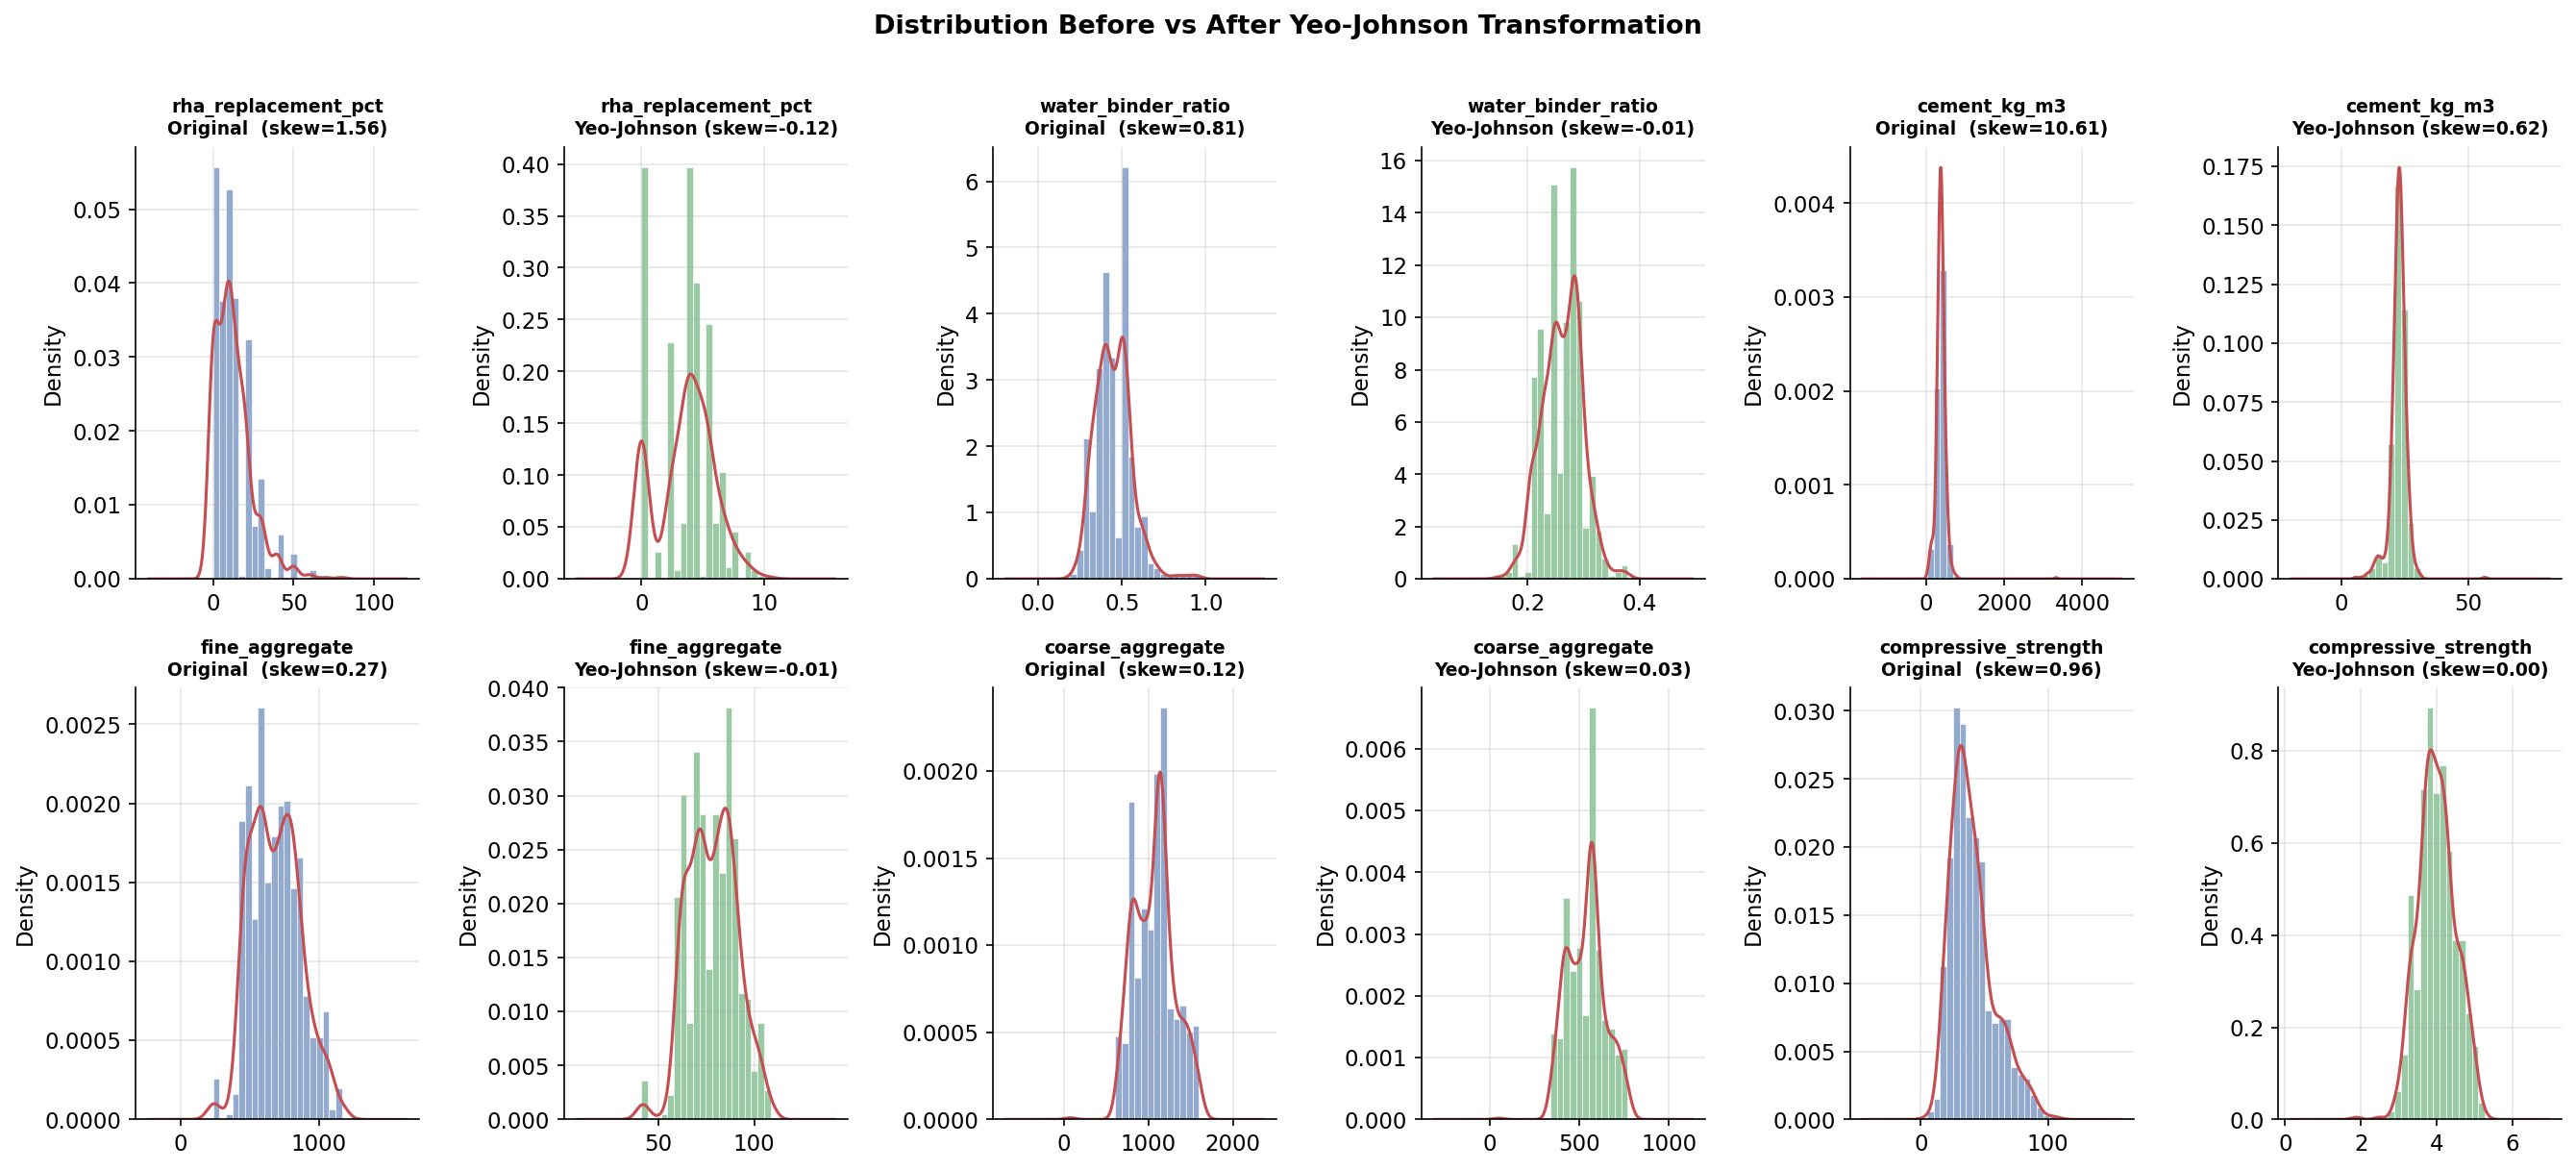

Saved: fig_4_1_transform_comparison.png

── 4.5  Q-Q Plots ──────────────────────────────────────


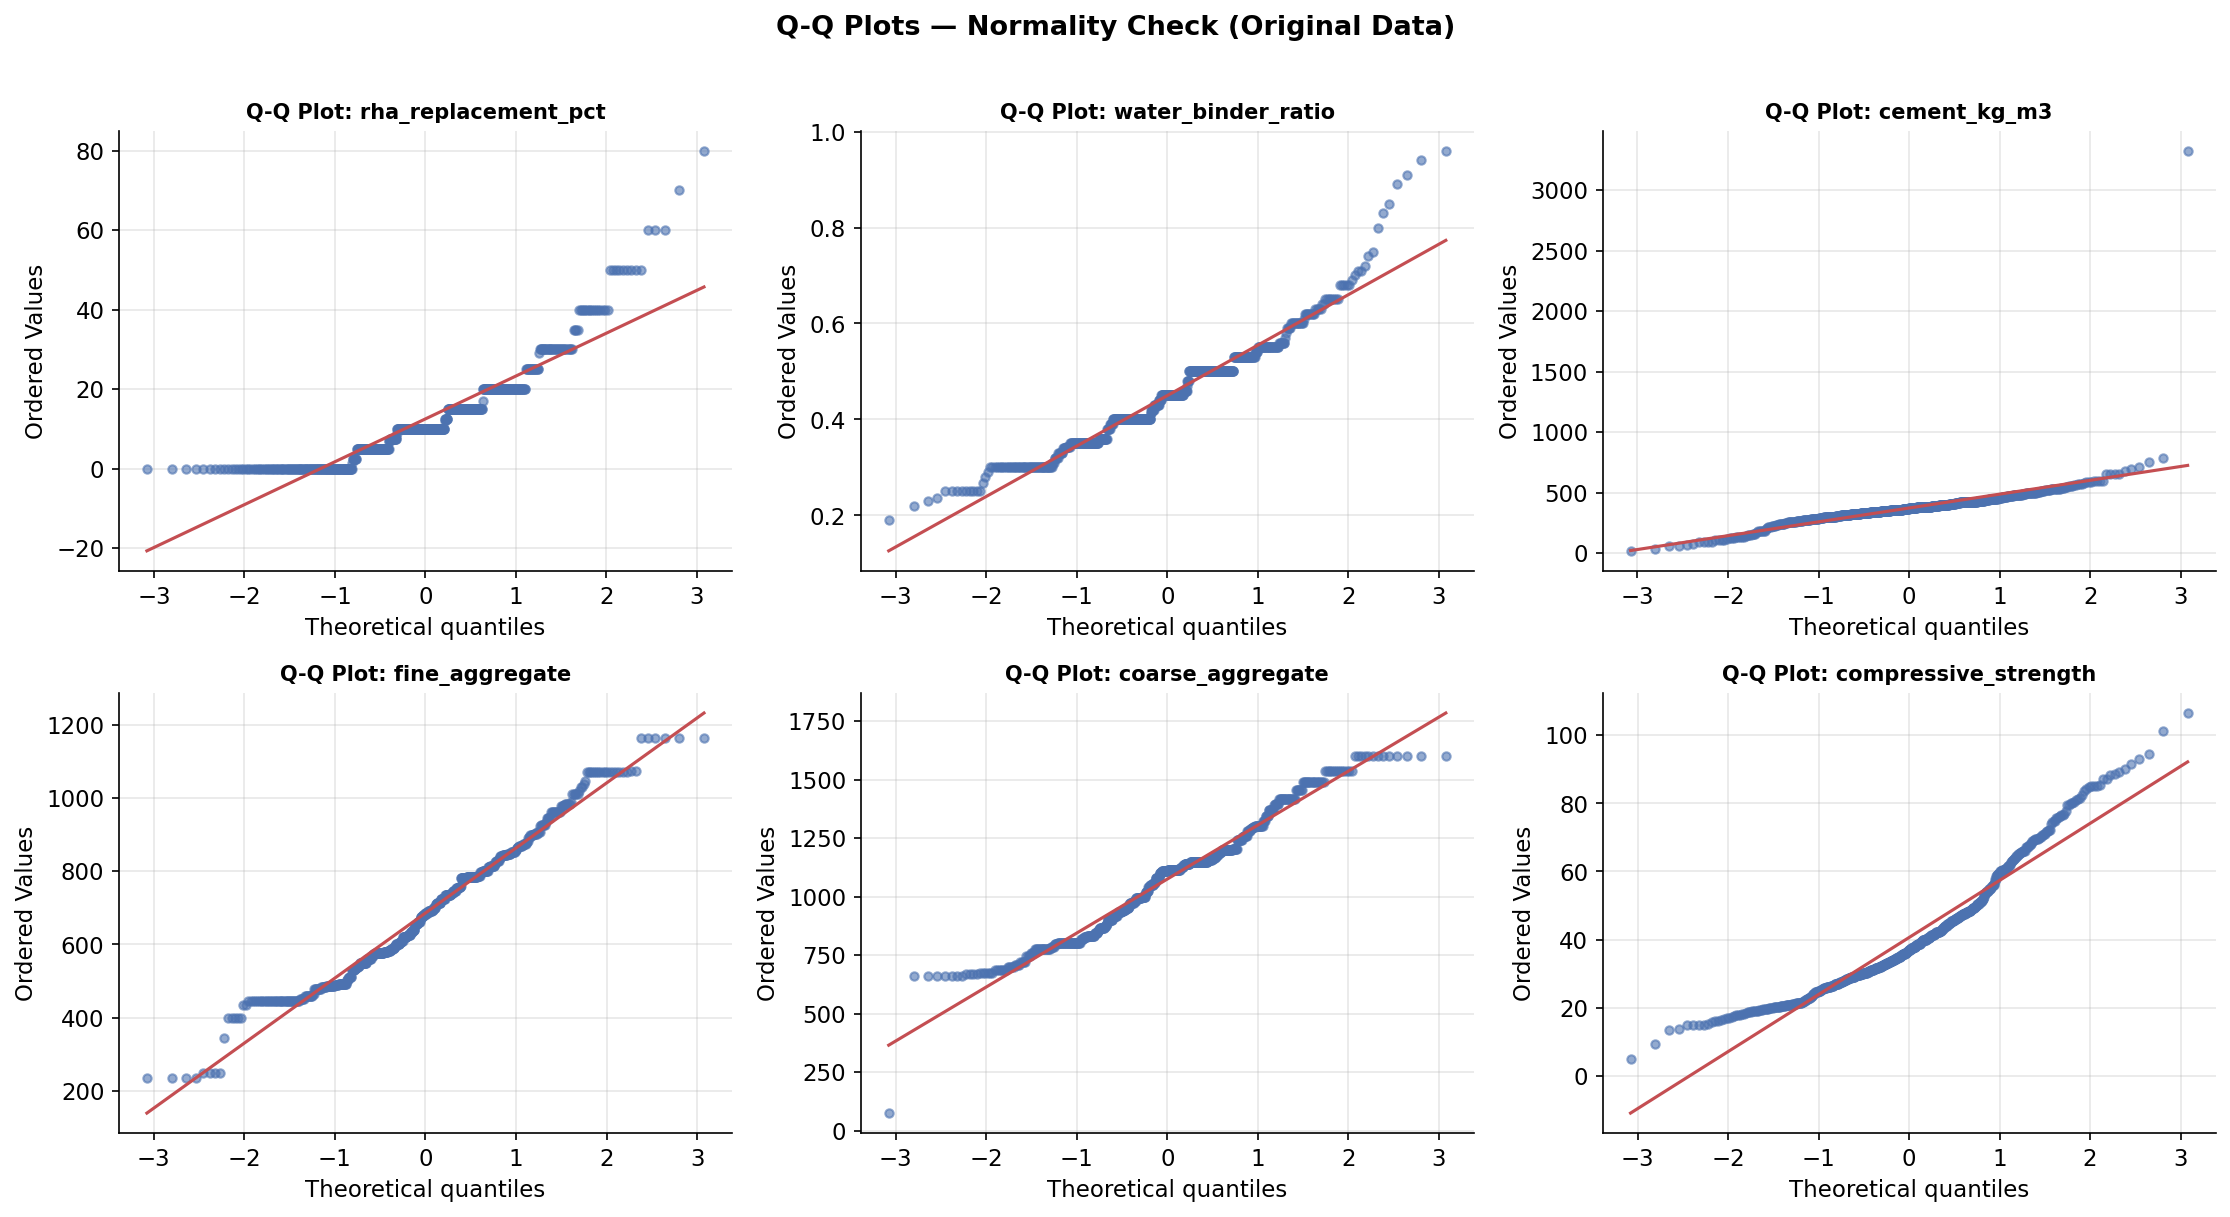

Saved: fig_4_2_qq_plots.png

── 4.6  Summary ────────────────────────────────────────
  Columns with |skew| > 1 (high): ['rha_replacement_pct', 'cement_kg_m3']
  Non-normal by Shapiro-Wilk    : ['rha_replacement_pct', 'water_binder_ratio', 'cement_kg_m3', 'fine_aggregate', 'coarse_aggregate', 'compressive_strength']

  Action: Yeo-Johnson PowerTransformer will be applied inside
  the sklearn Pipeline (Step 6) — fitted on train only.

Step 4 complete. Proceed to Step 5: Outlier Detection & Handling.


In [6]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 4: Skewness & Normality Analysis
# =============================================================================
# Requires: df_labeled, FEATURES, TARGET, ALL_COLS, PROPERTY_NAME from Step 2
# =============================================================================

from scipy import stats
from scipy.stats import shapiro, kstest, skew, kurtosis, boxcox, yeojohnson
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Redefine FEATURES and ALL_COLS
# ------------------------------------------------------------
FEATURES = [col for col in df_labeled.columns if col != TARGET]
ALL_COLS = FEATURES + [TARGET]

# ------------------------------------------------------------
# 4.1  Skewness & Kurtosis table
# ------------------------------------------------------------
print("── 4.1  Skewness & Kurtosis ────────────────────────────")

sk_report = []
for col in ALL_COLS:
    data = df_labeled[col].dropna()
    sk   = skew(data)
    kt   = kurtosis(data)
    flag = "High skew" if abs(sk) > 1 else ("Moderate" if abs(sk) > 0.5 else "Symmetric")
    sk_report.append({
        "Column":   col,
        "Skewness": round(sk, 4),
        "Kurtosis": round(kt, 4),
        "Shape":    flag,
        "Transform needed": "Yes" if abs(sk) > 1 else "No",
    })

sk_df = pd.DataFrame(sk_report)
print(sk_df.to_string(index=False))

needs_transform = sk_df[sk_df["Transform needed"] == "Yes"]["Column"].tolist()
print(f"\nColumns requiring transformation (|skew| > 1): {needs_transform}")

# ------------------------------------------------------------
# 4.2  Normality tests — Shapiro-Wilk & Kolmogorov-Smirnov
# ------------------------------------------------------------
print("\n── 4.2  Normality Tests ────────────────────────────────")

norm_report = []
for col in ALL_COLS:
    data = df_labeled[col].dropna().values

    # Shapiro-Wilk (best for n < 5000)
    sw_stat, sw_p = shapiro(data)

    # Kolmogorov-Smirnov against normal distribution
    data_std = (data - data.mean()) / data.std()
    ks_stat, ks_p = kstest(data_std, "norm")

    norm_report.append({
        "Column":     col,
        "SW stat":    round(sw_stat, 4),
        "SW p-value": round(sw_p, 4),
        "SW normal":  "Yes" if sw_p > 0.05 else "No",
        "KS stat":    round(ks_stat, 4),
        "KS p-value": round(ks_p, 4),
        "KS normal":  "Yes" if ks_p > 0.05 else "No",
    })

norm_df = pd.DataFrame(norm_report)
print(norm_df.to_string(index=False))
print("\nNote: p > 0.05 → fail to reject normality (likely normal).")

# ------------------------------------------------------------
# 4.3  Apply transformations to skewed columns
# ------------------------------------------------------------
print("\n── 4.3  Transformations ────────────────────────────────")

# We apply transformations for analysis/visualisation only here.
# The actual transformer fitted on train data lives in the sklearn
# Pipeline in Step 6 — this section is for comparison only.

transform_results = []

for col in ALL_COLS:
    data = df_labeled[col].dropna().values
    orig_skew = round(skew(data), 4)

    row = {"Column": col, "Original skew": orig_skew}

    # Log (only if all values > 0)
    if data.min() > 0:
        log_data = np.log1p(data)
        row["Log skew"] = round(skew(log_data), 4)
    else:
        row["Log skew"] = "N/A (has zeros)"

    # Square root (only if all values >= 0)
    if data.min() >= 0:
        sqrt_data = np.sqrt(data)
        row["Sqrt skew"] = round(skew(sqrt_data), 4)
    else:
        row["Sqrt skew"] = "N/A (negative)"

    # Yeo-Johnson (works for any values including zeros/negatives)
    yj_data, _ = yeojohnson(data)
    row["Yeo-Johnson skew"] = round(skew(yj_data), 4)

    # Box-Cox (only if all values > 0)
    if data.min() > 0:
        bc_data, _ = boxcox(data)
        row["Box-Cox skew"] = round(skew(bc_data), 4)
    else:
        row["Box-Cox skew"] = "N/A (has zeros)"

    transform_results.append(row)

tr_df = pd.DataFrame(transform_results)
print(tr_df.to_string(index=False))
print("\nBest transformation = one that brings |skew| closest to 0.")
print("Yeo-Johnson is used in the pipeline (handles zeros & negatives).")

# ------------------------------------------------------------
# 4.4  Visual comparison — before vs after Yeo-Johnson
# ------------------------------------------------------------
print("\n── 4.4  Distribution Before vs After Yeo-Johnson ───────")

cols_to_plot = ALL_COLS  # plot all for completeness
n_cols_plot  = 3
n_rows_plot  = int(np.ceil(len(cols_to_plot) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot * 2,
                         figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

ax_idx = 0
for col in cols_to_plot:
    data = df_labeled[col].dropna().values
    yj_data, _ = yeojohnson(data)

    # Original
    ax = axes[ax_idx]
    ax.hist(data, bins=20, color="#4C72B0", alpha=0.6, edgecolor="white",
            linewidth=0.5, density=True)
    pd.Series(data).plot.kde(ax=ax, color="#C44E52", linewidth=1.5)
    ax.set_title(f"{col}\nOriginal  (skew={skew(data):.2f})",
                 fontsize=9, fontweight="bold")
    ax.set_ylabel("Density")
    ax_idx += 1

    # Transformed
    ax = axes[ax_idx]
    ax.hist(yj_data, bins=20, color="#55A868", alpha=0.6, edgecolor="white",
            linewidth=0.5, density=True)
    pd.Series(yj_data).plot.kde(ax=ax, color="#C44E52", linewidth=1.5)
    ax.set_title(f"{col}\nYeo-Johnson (skew={skew(yj_data):.2f})",
                 fontsize=9, fontweight="bold")
    ax_idx += 1

for j in range(ax_idx, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution Before vs After Yeo-Johnson Transformation",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_4_1_transform_comparison.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_4_1_transform_comparison.png")

# ------------------------------------------------------------
# 4.5  Q-Q plots (before transformation)
# ------------------------------------------------------------
print("\n── 4.5  Q-Q Plots ──────────────────────────────────────")

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    data = df_labeled[col].dropna().values
    ax   = axes[i]
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {col}", fontsize=10, fontweight="bold")
    ax.get_lines()[0].set(markersize=4, alpha=0.6, color="#4C72B0")
    ax.get_lines()[1].set(color="#C44E52", linewidth=1.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Q-Q Plots — Normality Check (Original Data)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_4_2_qq_plots.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_4_2_qq_plots.png")

# ------------------------------------------------------------
# 4.6  Summary
# ------------------------------------------------------------
print("\n── 4.6  Summary ────────────────────────────────────────")
print(f"  Columns with |skew| > 1 (high): {needs_transform}")
non_normal_sw = norm_df[norm_df['SW normal'] == 'No']['Column'].tolist()
print(f"  Non-normal by Shapiro-Wilk    : {non_normal_sw}")
print("\n  Action: Yeo-Johnson PowerTransformer will be applied inside")
print("  the sklearn Pipeline (Step 6) — fitted on train only.")
print("\nStep 4 complete. Proceed to Step 5: Outlier Detection & Handling.")

Rows used for outlier detection (complete cases): 661

── 5.1  IQR Method ─────────────────────────────────────
              Column      Q1       Q3     IQR  Lower fence  Upper fence  Outliers  Outlier %
 rha_replacement_pct   5.000   20.000  15.000      -17.500       42.500        14      2.100
  water_binder_ratio   0.360    0.500   0.140        0.150        0.710        10      1.500
        cement_kg_m3 316.533  425.000 108.467      153.833      587.700        41      6.200
      fine_aggregate 550.000  800.000 250.000      175.000     1175.000         0      0.000
    coarse_aggregate 881.000 1200.000 319.000      402.500     1678.500         1      0.200
compressive_strength  28.700   48.530  19.830       -1.045       78.275        27      4.100

Rows flagged as outlier in ≥1 column (IQR): 79

── 5.2  Z-score Method (|z| > 3) ───────────────────────
              Column  Outliers  Outlier %  Max |z|
 rha_replacement_pct        14      2.100    5.820
  water_binder_ratio         

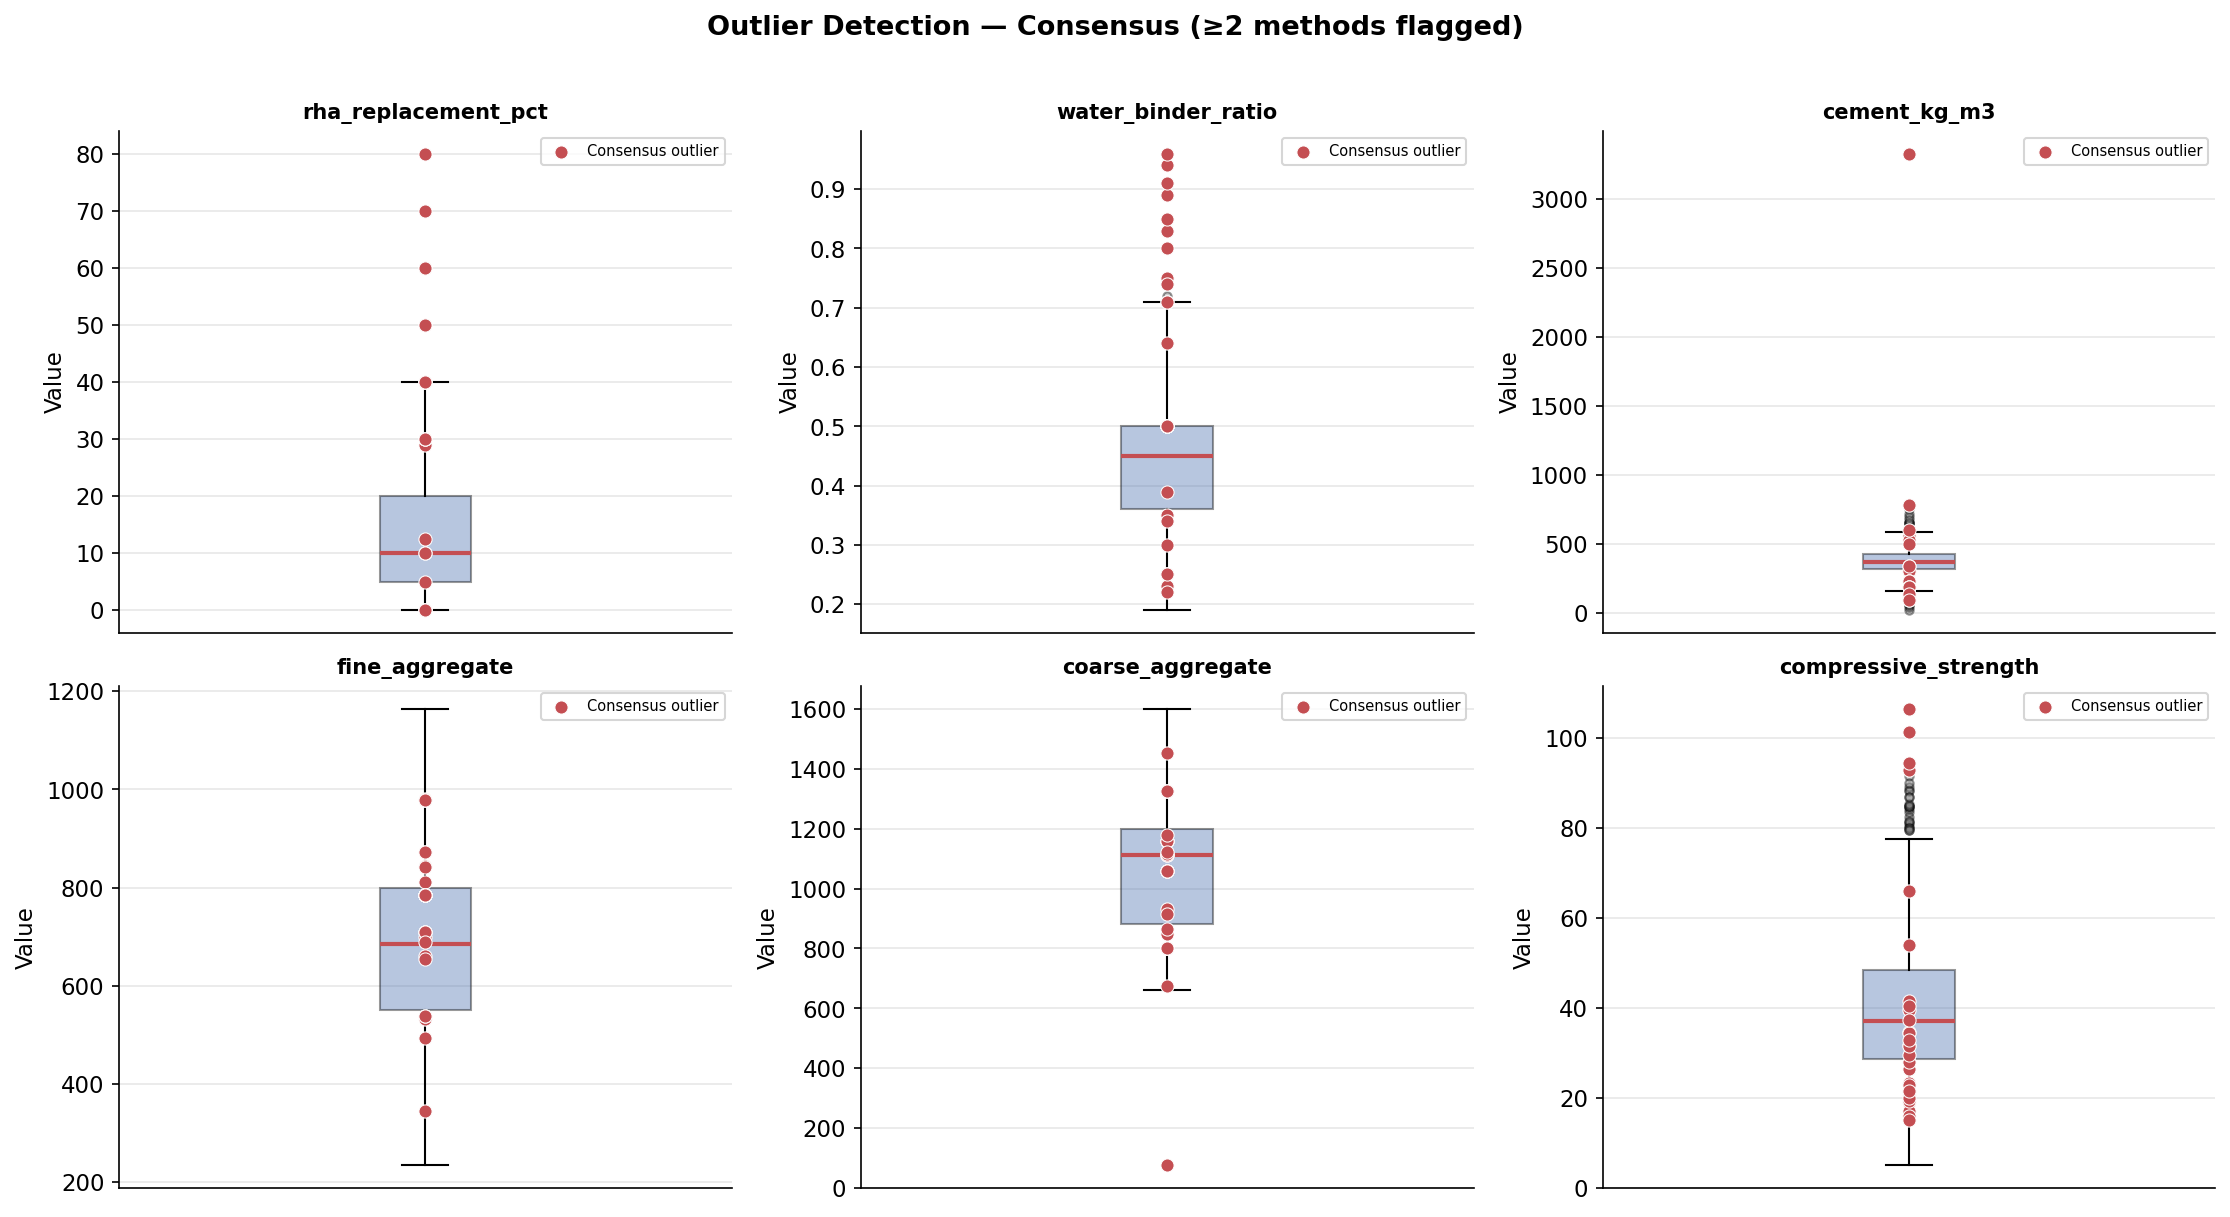

Saved: fig_5_1_outlier_boxplots.png


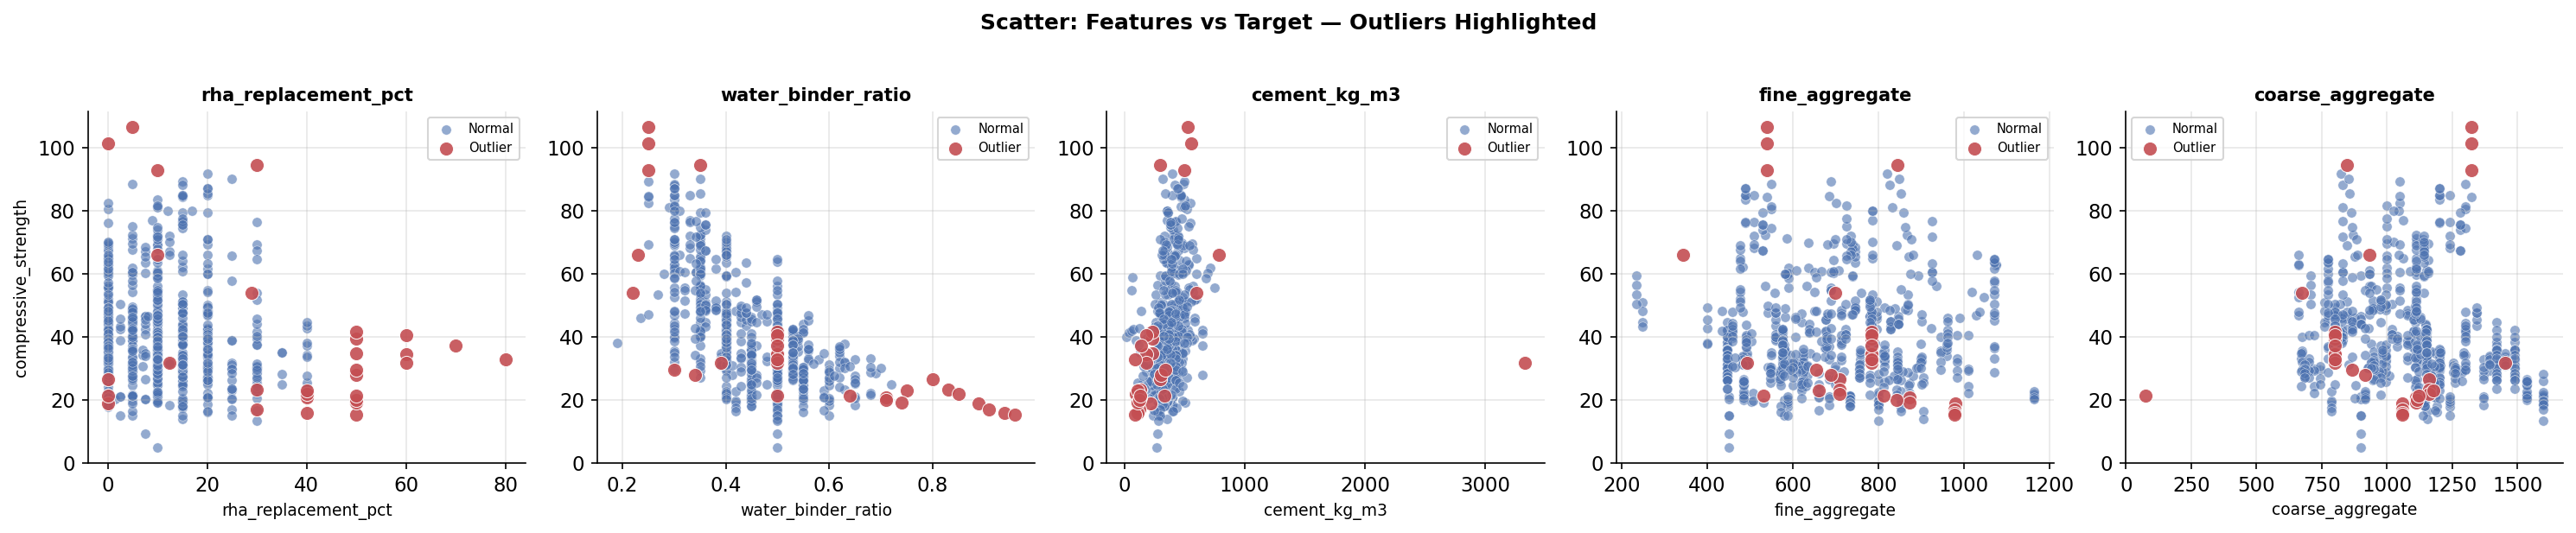

Saved: fig_5_2_outlier_scatter.png

── 5.6  Outlier Treatment: Winsorization ───────────────
              Column  Lower clip  Upper clip  Clipped
 rha_replacement_pct     -17.500      42.500       14
  water_binder_ratio       0.150       0.710       10
        cement_kg_m3     153.833     587.700       41
      fine_aggregate     175.000    1175.000        0
    coarse_aggregate     402.500    1678.500        1
compressive_strength      -1.220      78.300       27

Note: df_winsor is for reference. The pipeline in Step 6 applies
winsorization fitted on train data only — no leakage.


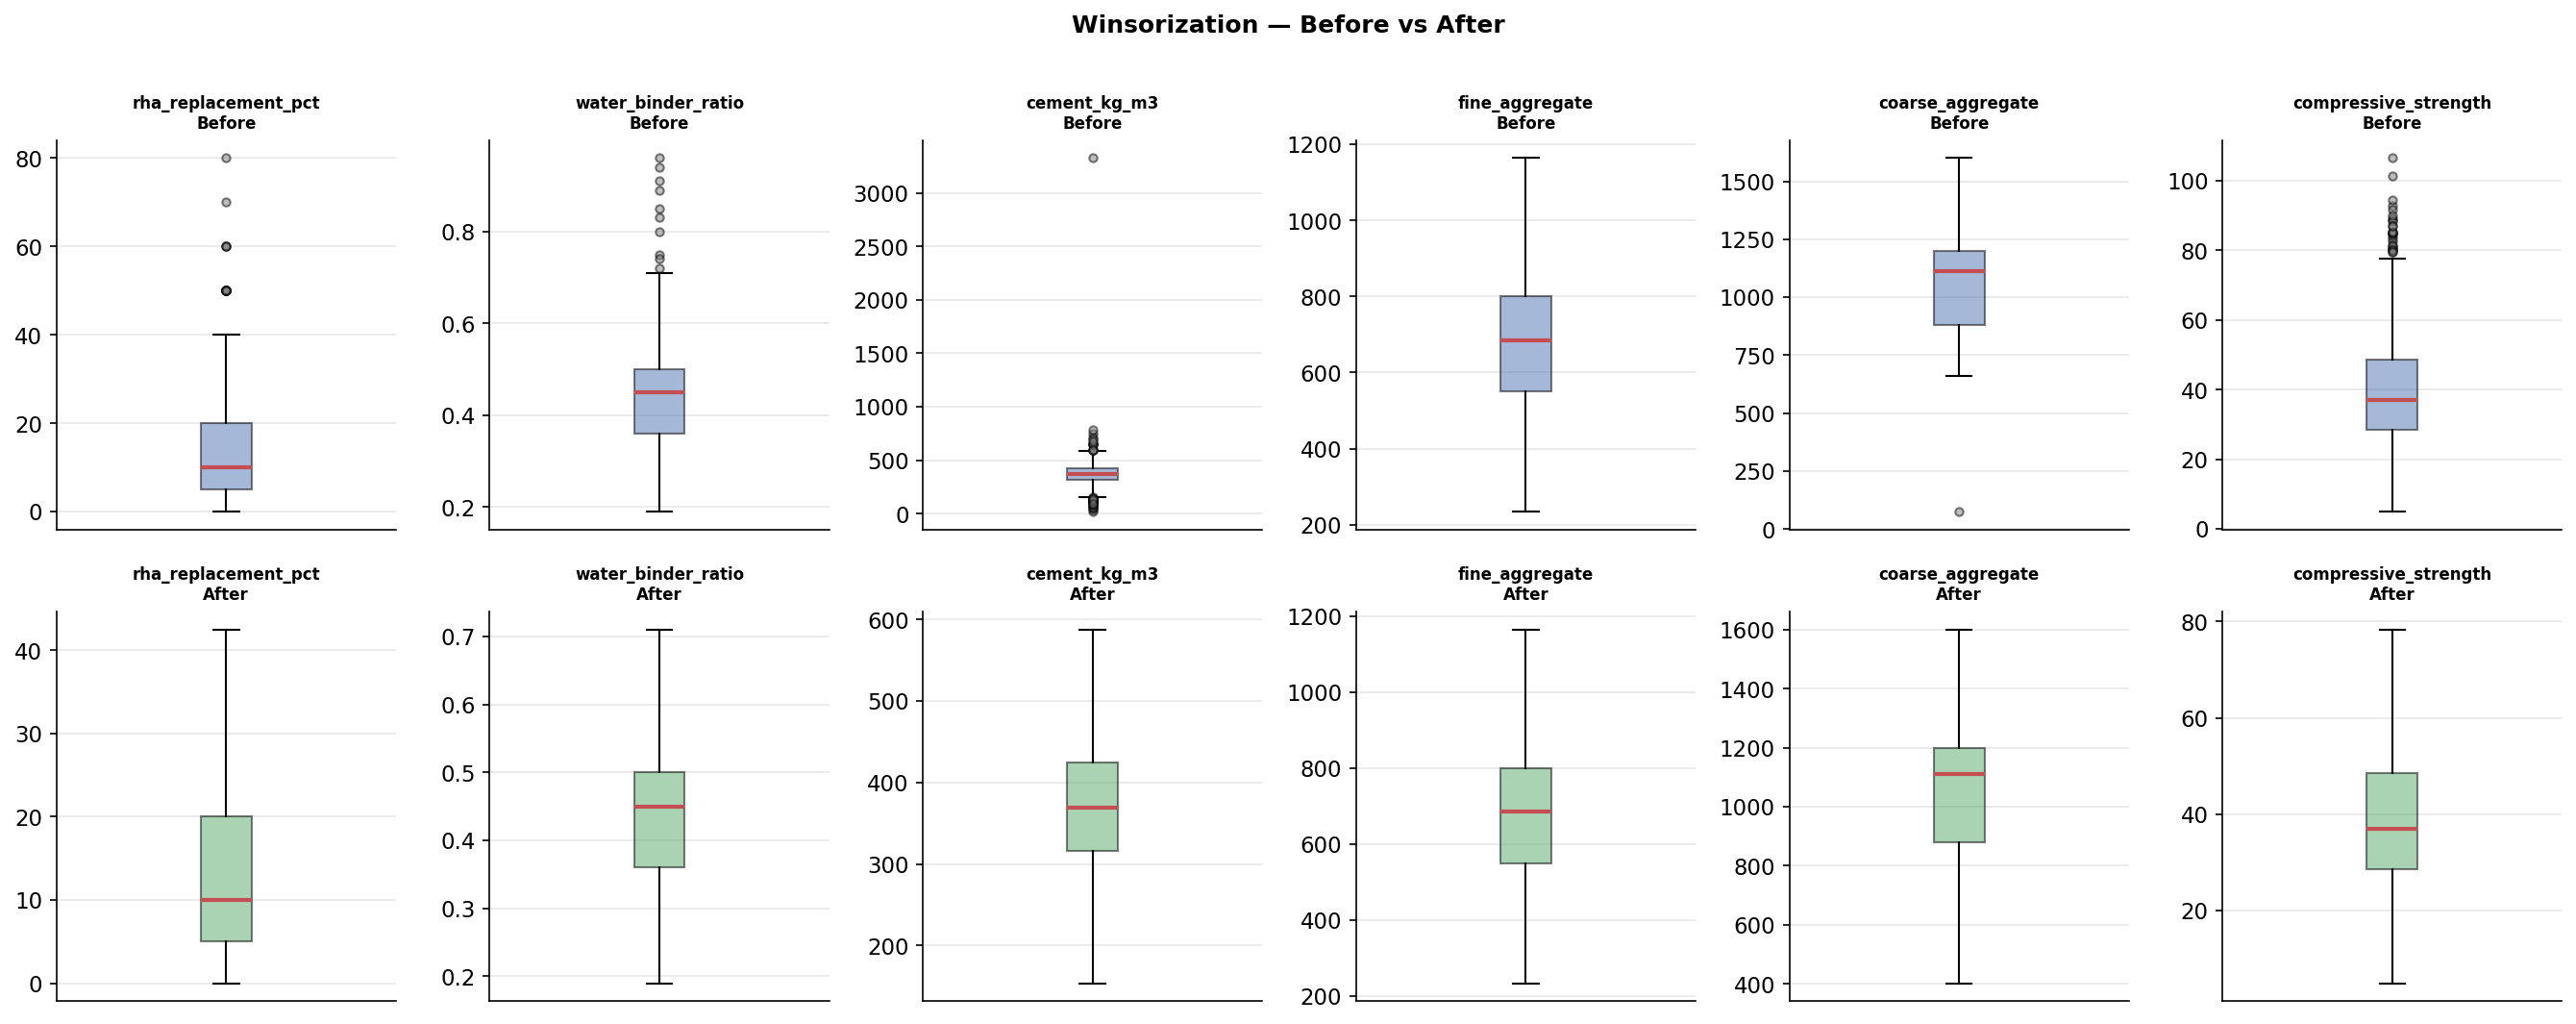

Saved: fig_5_3_winsorization.png

── 5.8  Outlier Summary & Justification ────────────────
  Total rows (complete cases)     : 661
  IQR outlier rows                : 79
  Z-score outlier rows            : 26
  Isolation Forest outlier rows   : 33
  Consensus outlier rows (≥2)     : 30

  Treatment chosen: Winsorization (IQR clipping)
  Justification:
    - Dataset is small (167 rows). Removing outliers risks losing
      valuable experimental observations.
    - Winsorization preserves row count while limiting extreme
      leverage on model coefficients.
    - Clips are computed on train data inside the pipeline to
      prevent any data leakage into the test set.
    - Isolation Forest used for detection only — not for removal,
      given the small sample size.

Step 5 complete. Proceed to Step 6: Feature Engineering.


In [7]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 5: Outlier Detection & Handling
# =============================================================================
# Requires: df_labeled, FEATURES, TARGET, ALL_COLS, PROPERTY_NAME from Step 2
# =============================================================================

from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# Redefine FEATURES and ALL_COLS
# ------------------------------------------------------------
FEATURES = [col for col in df_labeled.columns if col != TARGET]
ALL_COLS = FEATURES + [TARGET]

# Work on rows with no missing values for outlier detection
df_clean = df_labeled.dropna().copy().reset_index(drop=True)
print(f"Rows used for outlier detection (complete cases): {len(df_clean)}")

# ------------------------------------------------------------
# 5.1  IQR Method
# ------------------------------------------------------------
print("\n── 5.1  IQR Method ─────────────────────────────────────")

iqr_flags = pd.DataFrame(False, index=df_clean.index, columns=ALL_COLS)
iqr_report = []

for col in ALL_COLS:
    q1  = df_clean[col].quantile(0.25)
    q3  = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    mask = (df_clean[col] < lo) | (df_clean[col] > hi)
    iqr_flags[col] = mask
    iqr_report.append({
        "Column":     col,
        "Q1":         round(q1, 3),
        "Q3":         round(q3, 3),
        "IQR":        round(iqr, 3),
        "Lower fence":round(lo, 3),
        "Upper fence":round(hi, 3),
        "Outliers":   mask.sum(),
        "Outlier %":  round(mask.sum() / len(df_clean) * 100, 1),
    })

iqr_df = pd.DataFrame(iqr_report)
print(iqr_df.to_string(index=False))

iqr_outlier_rows = iqr_flags.any(axis=1)
print(f"\nRows flagged as outlier in ≥1 column (IQR): {iqr_outlier_rows.sum()}")

# ------------------------------------------------------------
# 5.2  Z-score Method
# ------------------------------------------------------------
print("\n── 5.2  Z-score Method (|z| > 3) ───────────────────────")

z_scores   = df_clean[ALL_COLS].apply(zscore, nan_policy="omit")
z_flags    = z_scores.abs() > 3
z_report   = []

for col in ALL_COLS:
    n_out = z_flags[col].sum()
    z_report.append({
        "Column":   col,
        "Outliers": n_out,
        "Outlier %":round(n_out / len(df_clean) * 100, 1),
        "Max |z|":  round(z_scores[col].abs().max(), 2),
    })

z_df = pd.DataFrame(z_report)
print(z_df.to_string(index=False))

z_outlier_rows = z_flags.any(axis=1)
print(f"\nRows flagged as outlier in ≥1 column (Z-score): {z_outlier_rows.sum()}")

# ------------------------------------------------------------
# 5.3  Isolation Forest
# ------------------------------------------------------------
print("\n── 5.3  Isolation Forest ───────────────────────────────")

iso = IsolationForest(contamination=0.05, random_state=SEED, n_estimators=200)
iso_labels = iso.fit_predict(df_clean[ALL_COLS])
iso_flags  = iso_labels == -1

print(f"Rows flagged by Isolation Forest (contamination=5%): {iso_flags.sum()}")

# Combined flag — flagged by at least 2 of 3 methods
combined_flags = (iqr_outlier_rows.astype(int) +
                  z_outlier_rows.astype(int) +
                  iso_flags.astype(int)) >= 2

print(f"\nRows flagged by ≥2 methods (consensus outliers): {combined_flags.sum()}")

# ------------------------------------------------------------
# 5.4  Visualisation — Boxplots with outlier overlay
# ------------------------------------------------------------
print("\n── 5.4  Outlier Visualisation ──────────────────────────")

n_cols_p = 3
n_rows_p = int(np.ceil(len(ALL_COLS) / n_cols_p))

fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(15, 4 * n_rows_p))
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    ax = axes[i]
    normal_data   = df_clean.loc[~combined_flags, col]
    outlier_data  = df_clean.loc[combined_flags, col]

    ax.boxplot(df_clean[col].values, patch_artist=True, vert=True,
               medianprops=dict(color="#C44E52", linewidth=2),
               boxprops=dict(facecolor="#4C72B0", alpha=0.4),
               flierprops=dict(marker="o", markerfacecolor="grey",
                               markersize=4, linestyle="none", alpha=0.4))

    # Overlay consensus outliers in red
    if outlier_data.notna().sum() > 0:
        ax.scatter([1] * len(outlier_data), outlier_data,
                   color="#C44E52", zorder=5, s=40, label="Consensus outlier",
                   edgecolors="white", linewidths=0.5)
        ax.legend(fontsize=7)

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xticks([])
    ax.set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection — Consensus (≥2 methods flagged)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_5_1_outlier_boxplots.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_5_1_outlier_boxplots.png")

# ------------------------------------------------------------
# 5.5  Scatter plots — outliers highlighted vs target
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(FEATURES), figsize=(4 * len(FEATURES), 4))
if len(FEATURES) == 1:
    axes = [axes]

for i, col in enumerate(FEATURES):
    ax = axes[i]
    ax.scatter(df_clean.loc[~combined_flags, col],
               df_clean.loc[~combined_flags, TARGET],
               color="#4C72B0", alpha=0.6, s=30, label="Normal",
               edgecolors="white", linewidths=0.3)
    ax.scatter(df_clean.loc[combined_flags, col],
               df_clean.loc[combined_flags, TARGET],
               color="#C44E52", alpha=0.9, s=60, label="Outlier",
               edgecolors="white", linewidths=0.5, zorder=5)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel(TARGET if i == 0 else "", fontsize=9)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)

plt.suptitle("Scatter: Features vs Target — Outliers Highlighted",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_5_2_outlier_scatter.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_5_2_outlier_scatter.png")

# ------------------------------------------------------------
# 5.6  Outlier treatment — Winsorization on df_labeled
# ------------------------------------------------------------
print("\n── 5.6  Outlier Treatment: Winsorization ───────────────")

# Winsorization clips at IQR fences — fitted on full df_labeled here
# for EDA purposes. In the pipeline (Step 6) this is done on train only.

df_winsor = df_labeled.copy()
winsor_report = []

for col in ALL_COLS:
    q1  = df_labeled[col].quantile(0.25)
    q3  = df_labeled[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_clipped = ((df_labeled[col] < lo) | (df_labeled[col] > hi)).sum()
    df_winsor[col] = df_winsor[col].clip(lower=lo, upper=hi)
    winsor_report.append({
        "Column":    col,
        "Lower clip":round(lo, 3),
        "Upper clip":round(hi, 3),
        "Clipped":   n_clipped,
    })

winsor_df = pd.DataFrame(winsor_report)
print(winsor_df.to_string(index=False))
print("\nNote: df_winsor is for reference. The pipeline in Step 6 applies")
print("winsorization fitted on train data only — no leakage.")

# ------------------------------------------------------------
# 5.7  Before vs after winsorization — boxplot comparison
# ------------------------------------------------------------
fig, axes = plt.subplots(2, len(ALL_COLS),
                         figsize=(3 * len(ALL_COLS), 7))

for i, col in enumerate(ALL_COLS):
    for row_idx, (data, label, color) in enumerate([
        (df_labeled[col].dropna(), "Before", "#4C72B0"),
        (df_winsor[col].dropna(),  "After",  "#55A868"),
    ]):
        ax = axes[row_idx, i]
        ax.boxplot(data.values, patch_artist=True,
                   medianprops=dict(color="#C44E52", linewidth=2),
                   boxprops=dict(facecolor=color, alpha=0.5),
                   flierprops=dict(marker="o", markersize=4,
                                   markerfacecolor="grey", alpha=0.5))
        ax.set_title(f"{col}\n{label}", fontsize=8, fontweight="bold")
        ax.set_xticks([])

plt.suptitle("Winsorization — Before vs After", fontsize=12,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_5_3_winsorization.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_5_3_winsorization.png")

# ------------------------------------------------------------
# 5.8  Summary & justification
# ------------------------------------------------------------
print("\n── 5.8  Outlier Summary & Justification ────────────────")
print(f"  Total rows (complete cases)     : {len(df_clean)}")
print(f"  IQR outlier rows                : {iqr_outlier_rows.sum()}")
print(f"  Z-score outlier rows            : {z_outlier_rows.sum()}")
print(f"  Isolation Forest outlier rows   : {iso_flags.sum()}")
print(f"  Consensus outlier rows (≥2)     : {combined_flags.sum()}")
print("""
  Treatment chosen: Winsorization (IQR clipping)
  Justification:
    - Dataset is small (167 rows). Removing outliers risks losing
      valuable experimental observations.
    - Winsorization preserves row count while limiting extreme
      leverage on model coefficients.
    - Clips are computed on train data inside the pipeline to
      prevent any data leakage into the test set.
    - Isolation Forest used for detection only — not for removal,
      given the small sample size.
""")
print("Step 5 complete. Proceed to Step 6: Feature Engineering.")

── 6.1  Train / Test Split ─────────────────────────────
  Total samples : 665
  Train         : 532  (80.0%)
  Test          : 133   (20.0%)

  IMPORTANT: All fitting below uses X_train only.
  X_test is untouched until Step 10 (final evaluation).

── 6.2  Scaler Comparison ──────────────────────────────


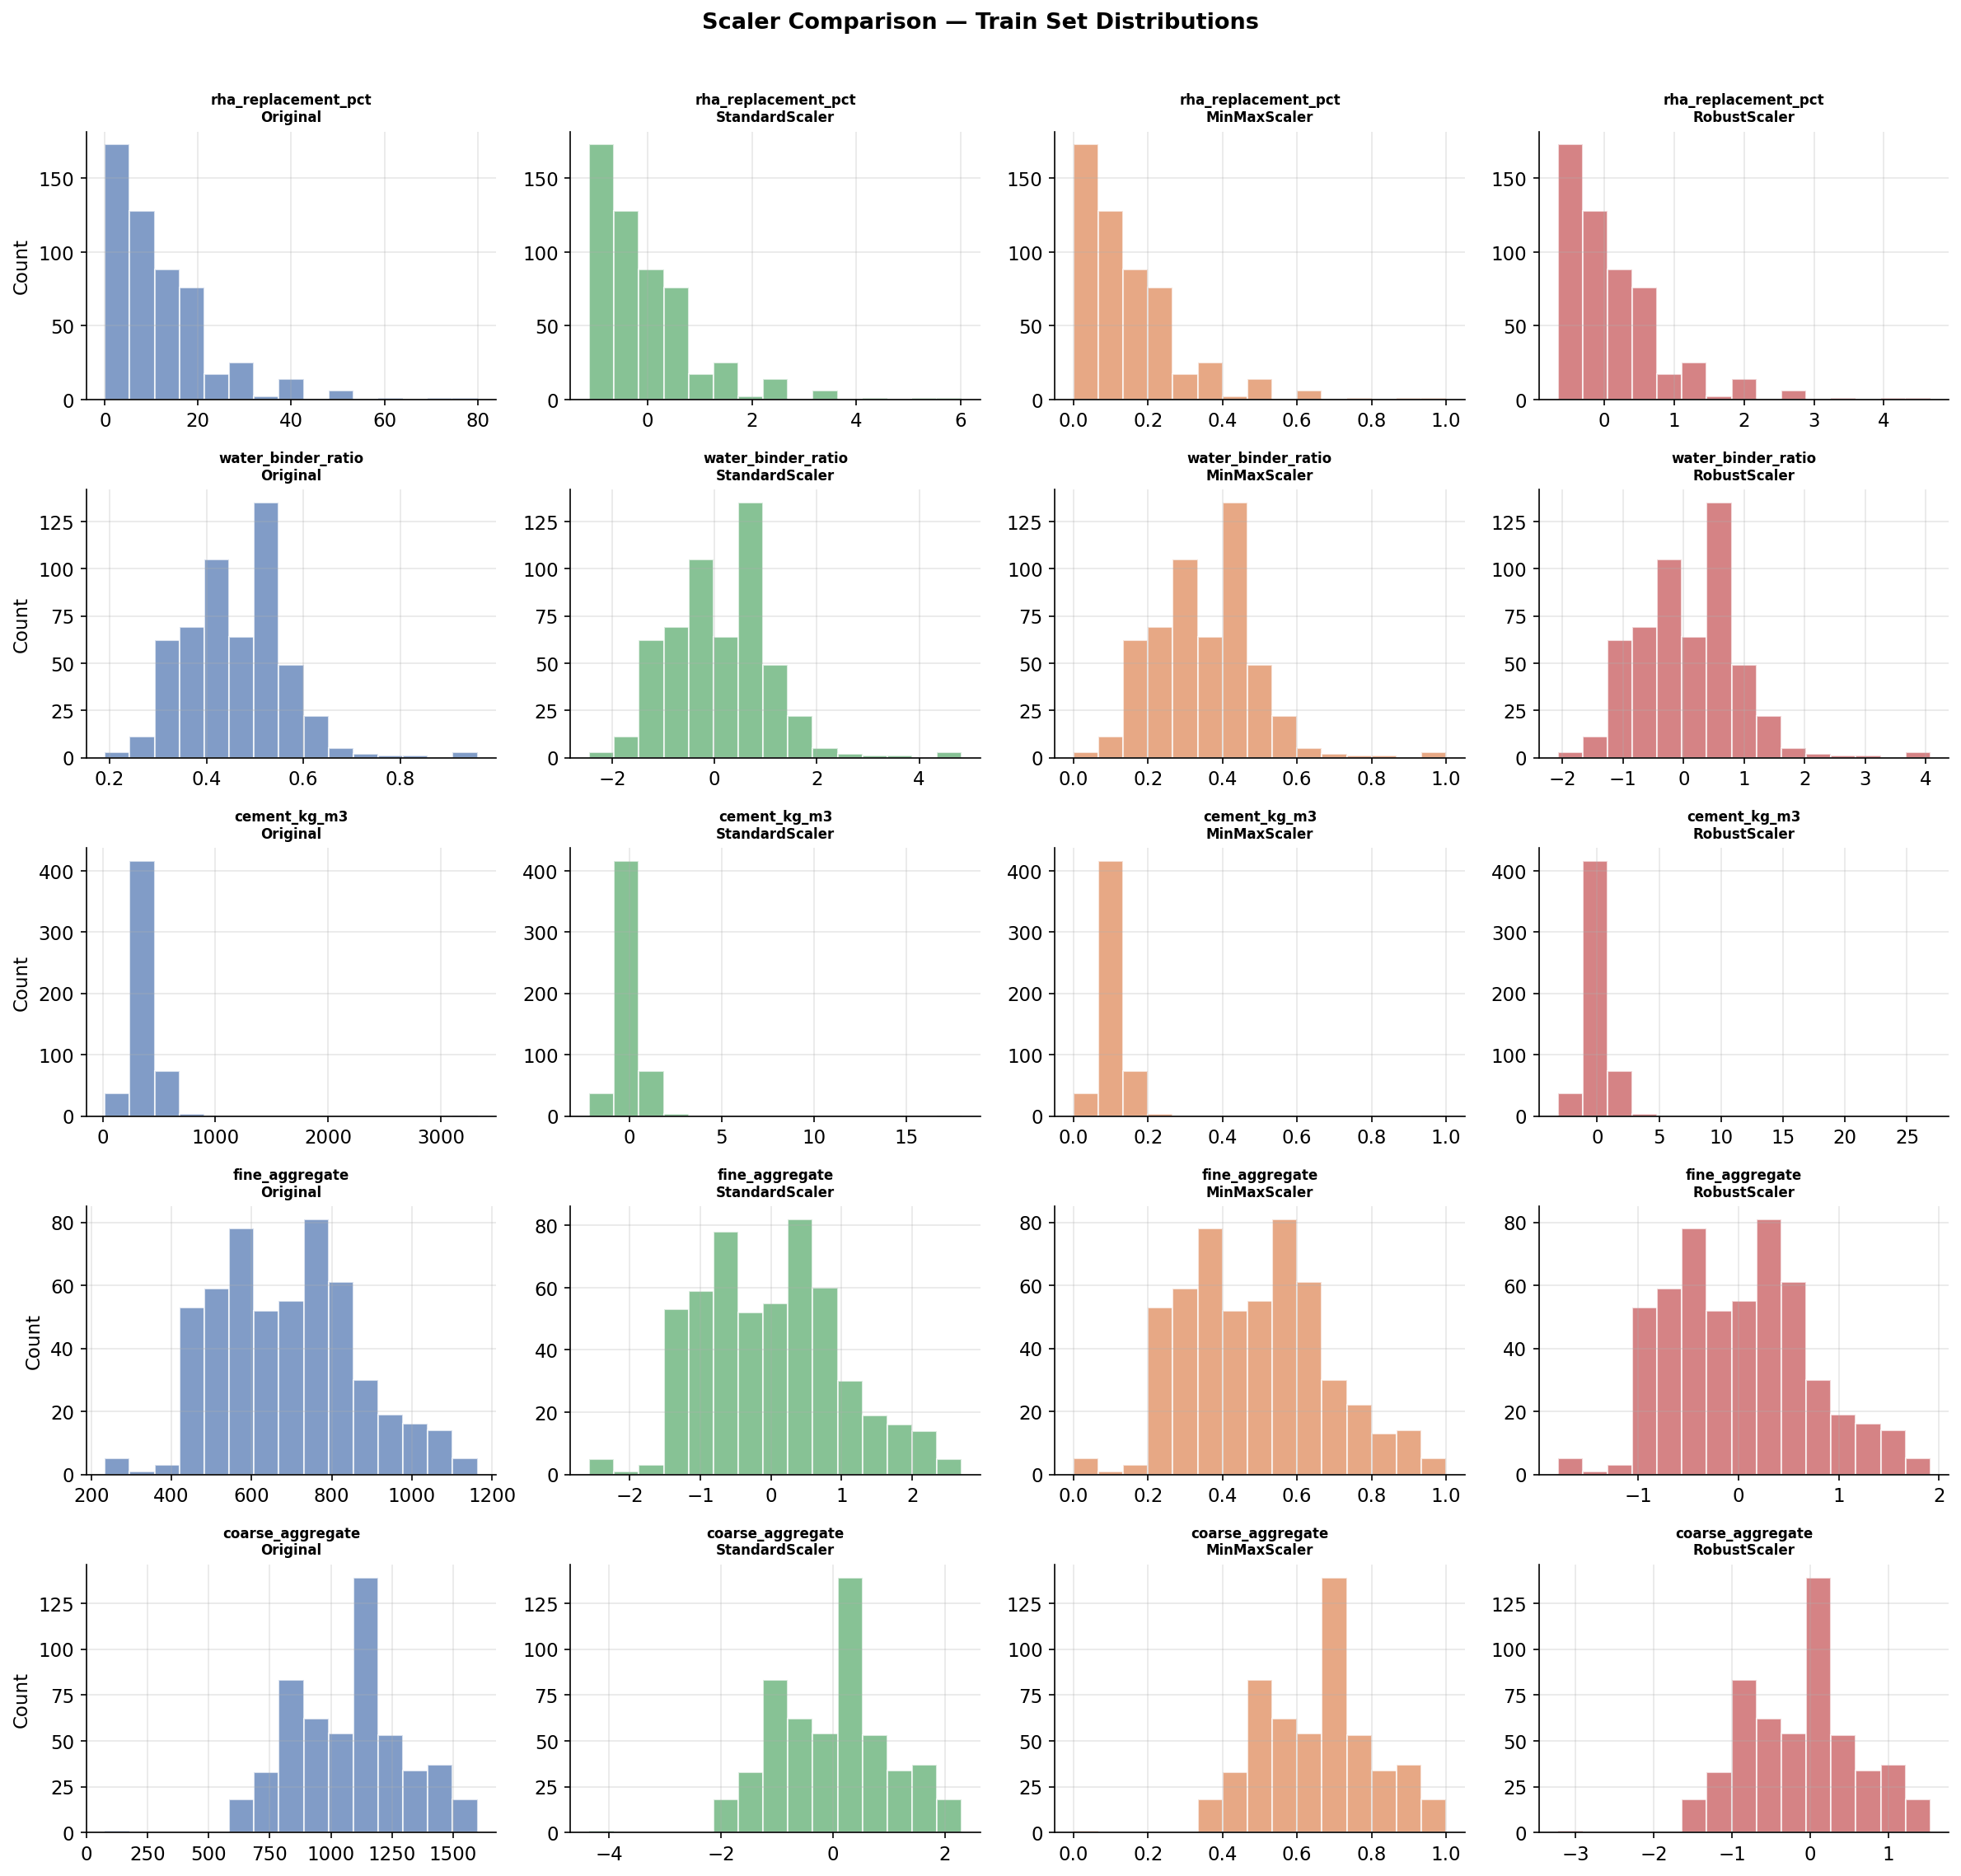

Saved: fig_6_1_scaler_comparison.png

Scaler summary (train set):
             Column         Scaler  Train mean  Train std  Train min  Train max
rha_replacement_pct StandardScaler      -0.000      1.000     -1.123      6.021
rha_replacement_pct   MinMaxScaler       0.157      0.140      0.000      1.000
rha_replacement_pct   RobustScaler       0.172      0.747     -0.667      4.667
 water_binder_ratio StandardScaler       0.000      1.000     -2.449      4.835
 water_binder_ratio   MinMaxScaler       0.336      0.137      0.000      1.000
 water_binder_ratio   RobustScaler      -0.009      0.846     -2.080      4.080
       cement_kg_m3 StandardScaler      -0.000      1.000     -2.172     18.015
       cement_kg_m3   MinMaxScaler       0.108      0.050      0.000      1.000
       cement_kg_m3   RobustScaler       0.062      1.489     -3.173     26.890
     fine_aggregate StandardScaler      -0.000      1.000     -2.575      2.701
     fine_aggregate   MinMaxScaler       0.488      0.

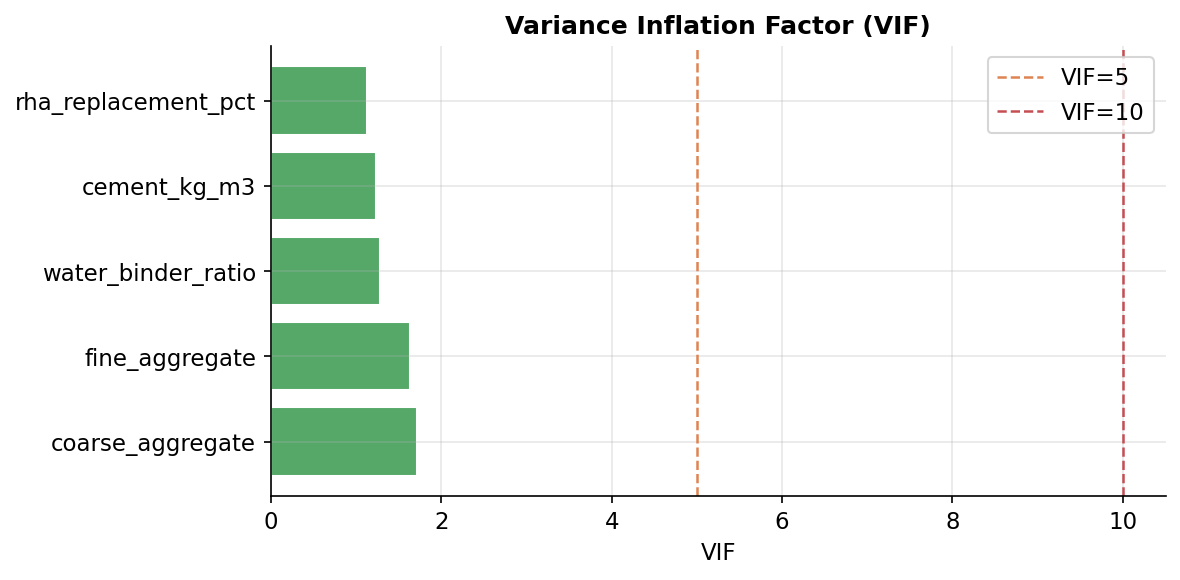

Saved: fig_6_2_vif.png

── 6.4  Mutual Information ─────────────────────────────
            Feature  MI Score
 water_binder_ratio     0.489
   coarse_aggregate     0.441
     fine_aggregate     0.362
       cement_kg_m3     0.194
rha_replacement_pct     0.118


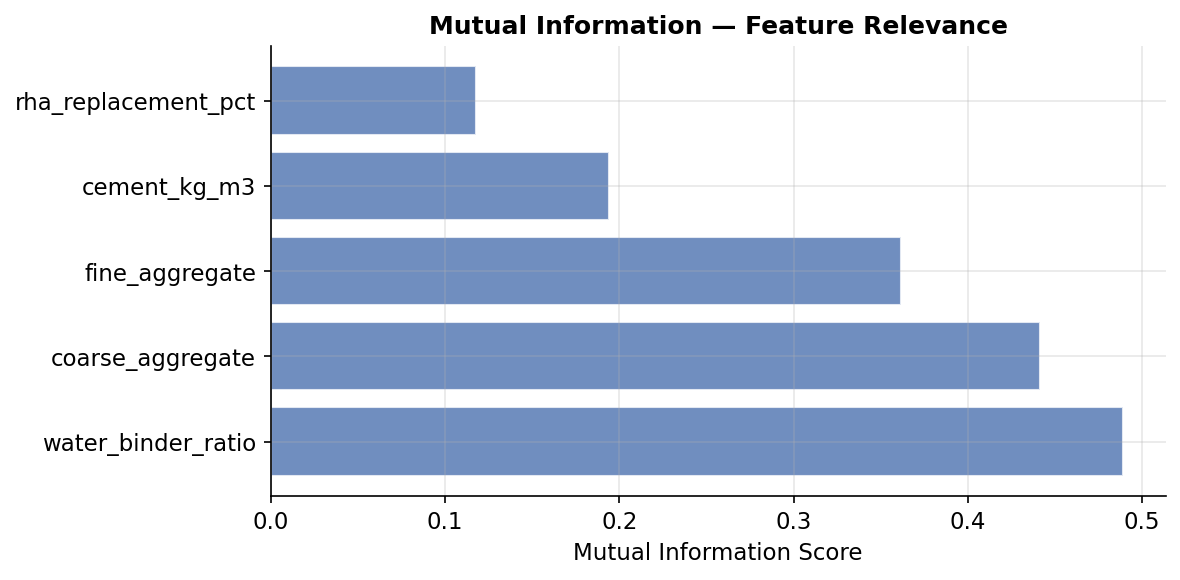

Saved: fig_6_3_mutual_information.png

── 6.5  Recursive Feature Elimination (RFE) ────────────
            Feature  Selected  Rank
rha_replacement_pct      True     1
 water_binder_ratio      True     1
   coarse_aggregate      True     1
     fine_aggregate     False     2
       cement_kg_m3     False     3

RFE selected features: ['rha_replacement_pct', 'water_binder_ratio', 'coarse_aggregate']

── 6.6  Permutation Importance ─────────────────────────
            Feature  Importance   Std
 water_binder_ratio       0.829 0.045
   coarse_aggregate       0.007 0.003
rha_replacement_pct       0.002 0.002
       cement_kg_m3      -0.000 0.001
     fine_aggregate      -0.000 0.000


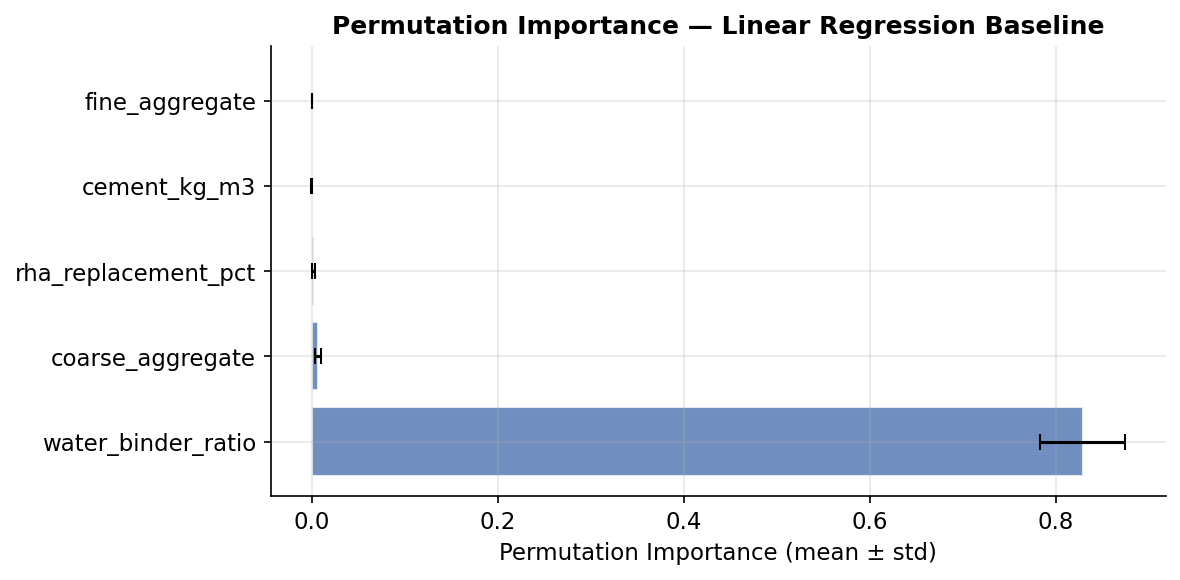

Saved: fig_6_4_permutation_importance.png

── 6.7  Feature Ranking Summary ────────────────────────
            Feature    MI  MI rank  RFE rank  Perm imp  Perm rank  Avg rank
 water_binder_ratio 0.489        1         1     0.829          1     1.000
   coarse_aggregate 0.441        2         1     0.007          2     1.670
     fine_aggregate 0.362        3         2    -0.000          4     3.000
rha_replacement_pct 0.118        5         1     0.002          3     3.000
       cement_kg_m3 0.194        4         3    -0.000          4     3.670

── 6.8  Final Pipeline Definition ─────────────────────
Pipeline structure:
  1. SimpleImputer     (median) — handles missing values
  2. WinsorClip        (IQR ×1.5) — clips extreme values
  3. PowerTransformer  (Yeo-Johnson) — corrects skewness
  4. RobustScaler      — scales using median/IQR
  5. Model             — pluggable estimator

All steps are fitted on train data only inside cross-validation.
build_pipeline(model) is imported by

In [8]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 6: Feature Engineering
# =============================================================================
# Requires: df_labeled, FEATURES, TARGET, ALL_COLS, PROPERTY_NAME, SEED
# =============================================================================

from sklearn.model_selection      import train_test_split
from sklearn.preprocessing        import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.impute                import SimpleImputer
from sklearn.pipeline              import Pipeline
from sklearn.linear_model          import LinearRegression
from sklearn.feature_selection     import RFE, mutual_info_regression
from sklearn.inspection            import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Redefine FEATURES and ALL_COLS
# ------------------------------------------------------------
FEATURES = [col for col in df_labeled.columns if col != TARGET]
ALL_COLS = FEATURES + [TARGET]

# ------------------------------------------------------------
# 6.1  Train / Test Split  ← THE LEAKAGE BOUNDARY
# ------------------------------------------------------------
print("── 6.1  Train / Test Split ─────────────────────────────")

X = df_labeled[FEATURES].copy()
y = df_labeled[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"  Total samples : {len(X)}")
print(f"  Train         : {len(X_train)}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test          : {len(X_test)}   ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n  IMPORTANT: All fitting below uses X_train only.")
print(f"  X_test is untouched until Step 10 (final evaluation).")

# ------------------------------------------------------------
# 6.2  Scaler comparison — fit on train, transform both sets
# ------------------------------------------------------------
print("\n── 6.2  Scaler Comparison ──────────────────────────────")

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler":   MinMaxScaler(),
    "RobustScaler":   RobustScaler(),
}

# Impute first (needed before scaling — fit on train only)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

X_train_imp = pd.DataFrame(X_train_imp, columns=FEATURES)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=FEATURES)

scaler_summary = []
fig, axes = plt.subplots(len(FEATURES), len(scalers) + 1,
                         figsize=(4 * (len(scalers) + 1), 3 * len(FEATURES)))

for col_idx, col in enumerate(FEATURES):

    # Original (train)
    ax = axes[col_idx, 0]
    ax.hist(X_train_imp[col], bins=15, color="#4C72B0", alpha=0.7,
            edgecolor="white")
    ax.set_title(f"{col}\nOriginal", fontsize=8, fontweight="bold")
    ax.set_ylabel("Count")

    for s_idx, (name, scaler) in enumerate(scalers.items()):
        sc    = scaler.__class__()         # fresh instance per column loop
        scaled_train = sc.fit_transform(X_train_imp[[col]])
        scaled_test  = sc.transform(X_test_imp[[col]])

        ax = axes[col_idx, s_idx + 1]
        ax.hist(scaled_train, bins=15,
                color=["#55A868","#DD8452","#C44E52"][s_idx],
                alpha=0.7, edgecolor="white")
        ax.set_title(f"{col}\n{name}", fontsize=8, fontweight="bold")

        scaler_summary.append({
            "Column":  col,
            "Scaler":  name,
            "Train mean": round(float(scaled_train.mean()), 4),
            "Train std":  round(float(scaled_train.std()),  4),
            "Train min":  round(float(scaled_train.min()),  4),
            "Train max":  round(float(scaled_train.max()),  4),
        })

plt.suptitle("Scaler Comparison — Train Set Distributions",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_6_1_scaler_comparison.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_6_1_scaler_comparison.png")

sc_df = pd.DataFrame(scaler_summary)
print("\nScaler summary (train set):")
print(sc_df.to_string(index=False))
print("\nChosen scaler for pipeline: RobustScaler")
print("Reason: dataset has outliers (Step 5); RobustScaler uses median/IQR,")
print("making it less sensitive to extreme values than StandardScaler.")

# ------------------------------------------------------------
# 6.3  Multicollinearity — Variance Inflation Factor (VIF)
# ------------------------------------------------------------
print("\n── 6.3  VIF Analysis ───────────────────────────────────")

# Use RobustScaler + imputed train data for VIF
robust_sc     = RobustScaler()
X_train_scaled = robust_sc.fit_transform(X_train_imp)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES)

vif_data = pd.DataFrame()
vif_data["Feature"] = FEATURES
vif_data["VIF"]     = [
    variance_inflation_factor(X_train_scaled.values, i)
    for i in range(X_train_scaled.shape[1])
]
vif_data["VIF"]    = vif_data["VIF"].round(3)
vif_data["Status"] = vif_data["VIF"].apply(
    lambda v: "OK" if v < 5 else ("Moderate" if v < 10 else "HIGH — consider dropping")
)
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data.to_string(index=False))
print("\nVIF < 5: acceptable | 5-10: moderate | >10: high multicollinearity")

# VIF bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#C44E52" if v >= 10 else "#DD8452" if v >= 5 else "#55A868"
          for v in vif_data["VIF"]]
ax.barh(vif_data["Feature"], vif_data["VIF"], color=colors, edgecolor="white")
ax.axvline(5,  color="#DD8452", linestyle="--", linewidth=1.2, label="VIF=5")
ax.axvline(10, color="#C44E52", linestyle="--", linewidth=1.2, label="VIF=10")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor (VIF)", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/fig_6_2_vif.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_6_2_vif.png")

# ------------------------------------------------------------
# 6.4  Feature Selection — Mutual Information
# ------------------------------------------------------------
print("\n── 6.4  Mutual Information ─────────────────────────────")

# Drop rows where target is NaN in train set
train_mask    = y_train.notna().reset_index(drop=True)
X_tr_mi       = X_train_scaled[train_mask]
y_tr_mi       = y_train.reset_index(drop=True)[train_mask]
mi_scores = mutual_info_regression(X_tr_mi, y_tr_mi, random_state=SEED)
mi_df     = pd.DataFrame({
    "Feature": FEATURES,
    "MI Score": mi_scores.round(4),
}).sort_values("MI Score", ascending=False)

print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(mi_df["Feature"], mi_df["MI Score"],
        color="#4C72B0", edgecolor="white", alpha=0.8)
ax.set_xlabel("Mutual Information Score")
ax.set_title("Mutual Information — Feature Relevance", fontsize=12,
             fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_6_3_mutual_information.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_6_3_mutual_information.png")

# ------------------------------------------------------------
# 6.5  Feature Selection — RFE (with Linear Regression)
# ------------------------------------------------------------
print("\n── 6.5  Recursive Feature Elimination (RFE) ────────────")

rfe_model = LinearRegression()
rfe       = RFE(estimator=rfe_model, n_features_to_select=3, step=1)
rfe.fit(X_tr_mi, y_tr_mi)

rfe_df = pd.DataFrame({
    "Feature":  FEATURES,
    "Selected": rfe.support_,
    "Rank":     rfe.ranking_,
}).sort_values("Rank")
print(rfe_df.to_string(index=False))

selected_features_rfe = rfe_df[rfe_df["Selected"]]["Feature"].tolist()
print(f"\nRFE selected features: {selected_features_rfe}")

# ------------------------------------------------------------
# 6.6  Feature Importance — Permutation Importance
# ------------------------------------------------------------
print("\n── 6.6  Permutation Importance ─────────────────────────")

lr = LinearRegression()
lr.fit(X_tr_mi, y_tr_mi)

perm = permutation_importance(lr, X_tr_mi, y_tr_mi,
                              n_repeats=30, random_state=SEED)
perm_df = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": perm.importances_mean.round(4),
    "Std":        perm.importances_std.round(4),
}).sort_values("Importance", ascending=False)
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(perm_df["Feature"], perm_df["Importance"],
        xerr=perm_df["Std"], color="#4C72B0",
        edgecolor="white", alpha=0.8, capsize=4)
ax.set_xlabel("Permutation Importance (mean ± std)")
ax.set_title("Permutation Importance — Linear Regression Baseline",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_6_4_permutation_importance.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_6_4_permutation_importance.png")

# ------------------------------------------------------------
# 6.7  Feature ranking summary
# ------------------------------------------------------------
print("\n── 6.7  Feature Ranking Summary ────────────────────────")

rank_df = pd.DataFrame({"Feature": FEATURES})
rank_df = rank_df.merge(mi_df.rename(columns={"MI Score": "MI"}), on="Feature")
rank_df = rank_df.merge(rfe_df[["Feature","Rank"]].rename(
                        columns={"Rank": "RFE rank"}), on="Feature")
rank_df = rank_df.merge(perm_df[["Feature","Importance"]].rename(
                        columns={"Importance": "Perm imp"}), on="Feature")
rank_df["MI rank"]   = rank_df["MI"].rank(ascending=False).astype(int)
rank_df["Perm rank"] = rank_df["Perm imp"].rank(ascending=False).astype(int)
rank_df["Avg rank"]  = ((rank_df["MI rank"] +
                          rank_df["RFE rank"] +
                          rank_df["Perm rank"]) / 3).round(2)
rank_df = rank_df.sort_values("Avg rank")
print(rank_df[["Feature","MI","MI rank","RFE rank",
               "Perm imp","Perm rank","Avg rank"]].to_string(index=False))

# ------------------------------------------------------------
# 6.8  Build the final sklearn pipeline
# ------------------------------------------------------------
print("\n── 6.8  Final Pipeline Definition ─────────────────────")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer

def build_pipeline(model):
    """
    Returns a full sklearn Pipeline:
      1. Median imputation   (fitted on train only)
      2. Winsorization clip  (via custom transformer)
      3. Yeo-Johnson power   (fitted on train only)
      4. RobustScaler        (fitted on train only)
      5. Model
    """
    from sklearn.base import BaseEstimator, TransformerMixin

    class WinsorClip(BaseEstimator, TransformerMixin):
        def __init__(self, factor=1.5):
            self.factor = factor
        def fit(self, X, y=None):
            X = pd.DataFrame(X)
            self.lower_ = X.quantile(0.25) - self.factor * (X.quantile(0.75) - X.quantile(0.25))
            self.upper_ = X.quantile(0.75) + self.factor * (X.quantile(0.75) - X.quantile(0.25))
            return self
        def transform(self, X, y=None):
            X = pd.DataFrame(X).copy()
            for i, col in enumerate(X.columns):
                X[col] = X[col].clip(lower=self.lower_.iloc[i],
                                     upper=self.upper_.iloc[i])
            return X.values

    pipe = Pipeline([
        ("imputer",     SimpleImputer(strategy="median")),
        ("winsor",      WinsorClip(factor=1.5)),
        ("transformer", PowerTransformer(method="yeo-johnson")),
        ("scaler",      RobustScaler()),
        ("model",       model),
    ])
    return pipe

print("Pipeline structure:")
print("  1. SimpleImputer     (median) — handles missing values")
print("  2. WinsorClip        (IQR ×1.5) — clips extreme values")
print("  3. PowerTransformer  (Yeo-Johnson) — corrects skewness")
print("  4. RobustScaler      — scales using median/IQR")
print("  5. Model             — pluggable estimator")
print("\nAll steps are fitted on train data only inside cross-validation.")
print("build_pipeline(model) is imported by Steps 7–10.")

# Save train/test sets for all subsequent steps
print(f"\nExporting: X_train {X_train.shape}, X_test {X_test.shape}")
print(f"           y_train {y_train.shape}, y_test {y_test.shape}")
print("\nStep 6 complete. Proceed to Step 7: Model Development.")

Models to train: 12
  • Linear Regression
  • Ridge
  • Lasso
  • SVR
  • Decision Tree
  • Random Forest
  • Gradient Boosting
  • XGBoost
  • LightGBM
  • CatBoost
  • Extra Trees
  • AdaBoost

── 7.2  10-Fold Cross-Validation (train set only) ──────
  Linear Regression      R²=0.4065 ±0.1214  RMSE=12.8382  MAE=10.0555  [2.68s]
  Ridge                  R²=0.4068 ±0.1208  RMSE=12.8368  MAE=10.0512  [0.26s]
  Lasso                  R²=0.4068 ±0.1210  RMSE=12.8359  MAE=10.0549  [0.32s]
  SVR                    R²=0.4259 ±0.0757  RMSE=12.7260  MAE=9.4256  [0.38s]
  Decision Tree          R²=0.7666 ±0.0731  RMSE=7.9582  MAE=5.1119  [0.29s]
  Random Forest          R²=0.8544 ±0.0519  RMSE=6.2766  MAE=4.4775  [2.69s]
  Gradient Boosting      R²=0.8414 ±0.0524  RMSE=6.5705  MAE=4.8004  [1.14s]
  XGBoost                R²=0.8187 ±0.0725  RMSE=6.9587  MAE=4.6269  [0.94s]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

  LightGBM               R²=0.8386 ±0.0471  RMSE=6.6348  MAE=4.6849  [3.17s]
  CatBoost               R²=0.8587 ±0.0455  RMSE=6.2164  MAE=4.5420  [2.78s]
  Extra Trees            R²=0.8605 ±0.0445  RMSE=6.1605  MAE=4.1497  [1.91s]
  AdaBoost               R²=0.6347 ±0.1176  RMSE=9.9509  MAE=8.0422  [1.53s]

── Cross-Validation Leaderboard ────────────────────────
            Model  CV R² mean  CV R² std  CV RMSE mean  CV MAE mean  Time (s)
      Extra Trees       0.861      0.044         6.160        4.150     1.910
         CatBoost       0.859      0.045         6.216        4.542     2.780
    Random Forest       0.854      0.052         6.277        4.478     2.690
Gradient Boosting       0.841      0.052         6.571        4.800     1.140
         LightGBM       0.839      0.047         6.635        4.685     3.170
          XGBoost       0.819      0.072         6.959        4.627     0.940
    Decision Tree       0.767      0.073         7.958        5.112     0.290
         A

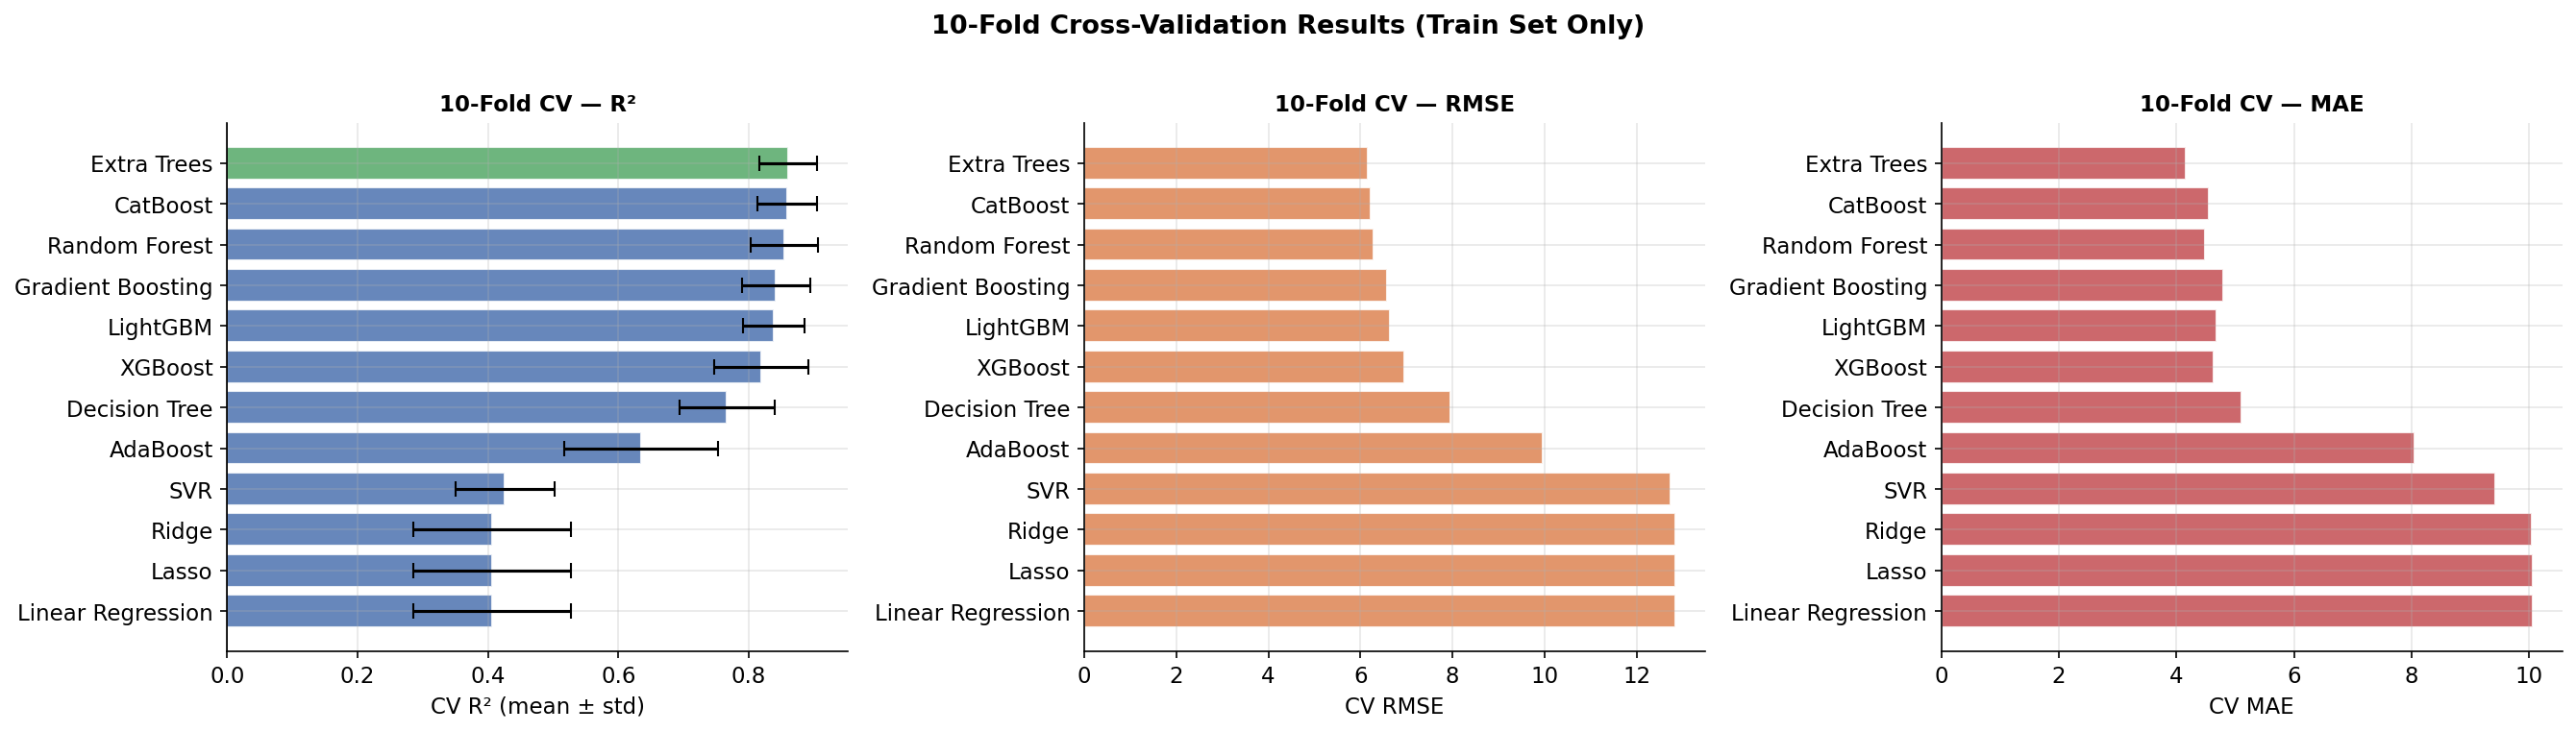

Saved: fig_7_1_cv_results.png


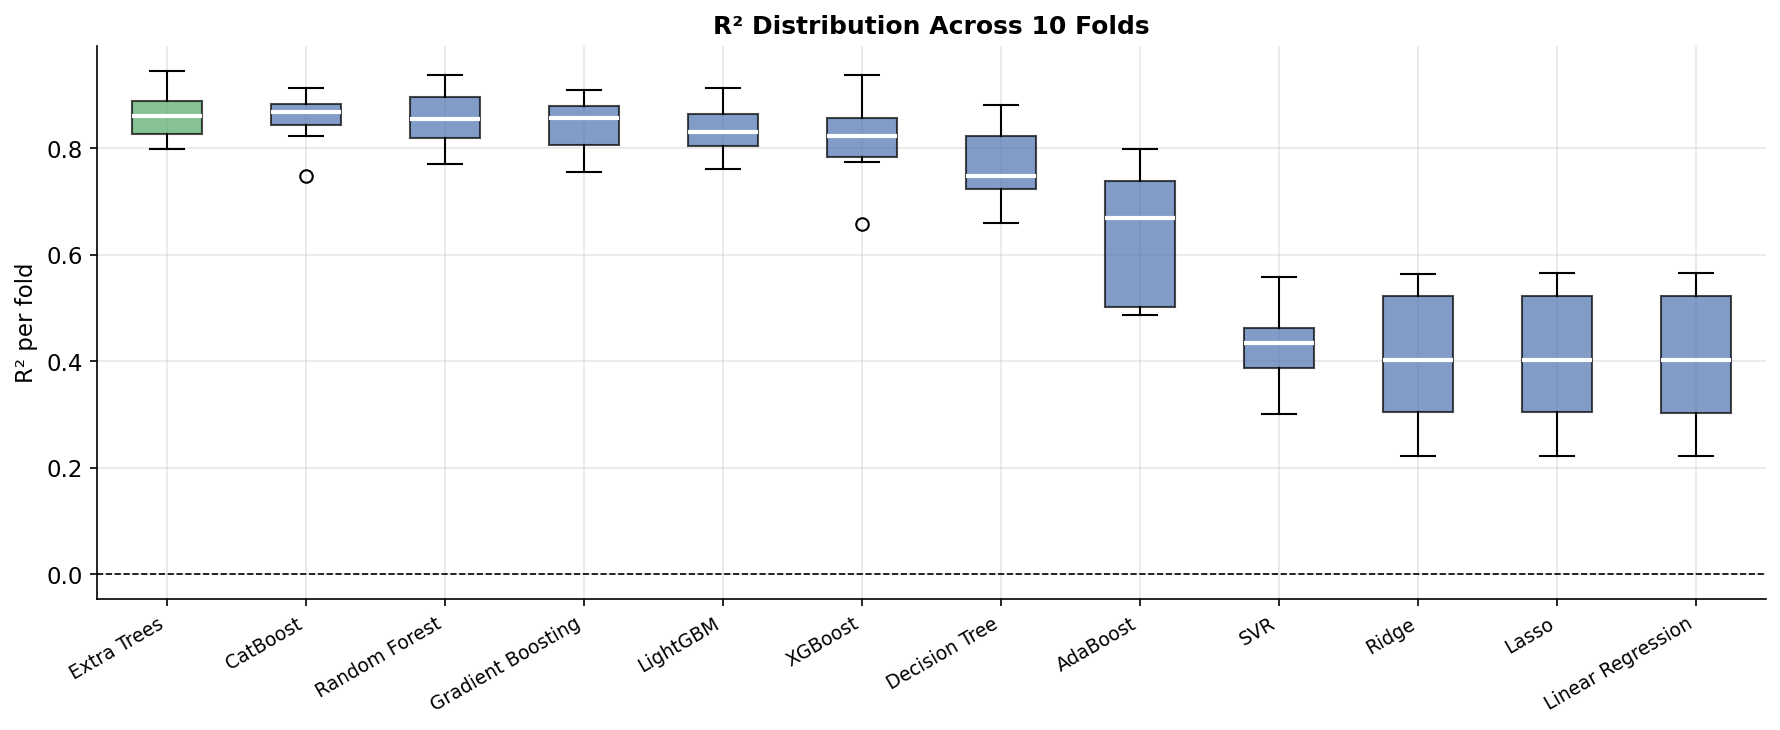

Saved: fig_7_2_cv_r2_boxplot.png

── 7.4  Fitting on Full Train Set ──────────────────────
  Fitted: Linear Regression
  Fitted: Ridge
  Fitted: Lasso
  Fitted: SVR
  Fitted: Decision Tree
  Fitted: Random Forest
  Fitted: Gradient Boosting
  Fitted: XGBoost
  Fitted: LightGBM
  Fitted: CatBoost
  Fitted: Extra Trees
  Fitted: AdaBoost

── 7.5  Preliminary Train & Test Scores ────────────────
            Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE
      Extra Trees     0.988    0.909       1.909      5.393      0.633     3.861
         CatBoost     0.971    0.892       2.933      5.867      2.151     4.302
         LightGBM     0.969    0.889       3.021      5.953      2.068     4.395
Gradient Boosting     0.951    0.867       3.786      6.507      2.865     4.594
    Random Forest     0.974    0.864       2.776      6.592      1.864     4.519
          XGBoost     0.988    0.838       1.909      7.196      0.652     4.774
         AdaBoost     0.733    0.699 

In [9]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 7: Model Development
# =============================================================================
# Requires: X_train, X_test, y_train, y_test, build_pipeline(), SEED
# =============================================================================

from sklearn.linear_model     import LinearRegression, Ridge, Lasso
from sklearn.svm               import SVR
from sklearn.tree              import DecisionTreeRegressor
from sklearn.ensemble          import (RandomForestRegressor,
                                       GradientBoostingRegressor,
                                       ExtraTreesRegressor,
                                       AdaBoostRegressor)
from xgboost                   import XGBRegressor
from lightgbm                  import LGBMRegressor
from catboost                  import CatBoostRegressor
from sklearn.model_selection   import cross_validate, KFold
from sklearn.metrics           import r2_score, mean_squared_error, mean_absolute_error
import time
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Redefine FEATURES and ALL_COLS
# ------------------------------------------------------------
FEATURES = [col for col in df_labeled.columns if col != TARGET]
ALL_COLS = FEATURES + [TARGET]

# ------------------------------------------------------------
# 7.1  Define all models
# ------------------------------------------------------------
MODELS = {
    "Linear Regression":      LinearRegression(),
    "Ridge":                  Ridge(alpha=1.0, random_state=SEED),
    "Lasso":                  Lasso(alpha=0.01, random_state=SEED),
    "SVR":                    SVR(kernel="rbf", C=1.0, epsilon=0.1),
    "Decision Tree":          DecisionTreeRegressor(random_state=SEED),
    "Random Forest":          RandomForestRegressor(n_estimators=200, random_state=SEED),
    "Gradient Boosting":      GradientBoostingRegressor(n_estimators=200, random_state=SEED),
    "XGBoost":                XGBRegressor(n_estimators=200, random_state=SEED,
                                           verbosity=0, eval_metric="rmse"),
    "LightGBM":               LGBMRegressor(n_estimators=200, random_state=SEED,
                                            verbose=-1),
    "CatBoost":               CatBoostRegressor(iterations=200, random_state=SEED,
                                                verbose=0),
    "Extra Trees":            ExtraTreesRegressor(n_estimators=200, random_state=SEED),
    "AdaBoost":               AdaBoostRegressor(n_estimators=200, random_state=SEED),
}

print(f"Models to train: {len(MODELS)}")
for name in MODELS:
    print(f"  • {name}")

# ------------------------------------------------------------
# 7.2  10-fold cross-validation on train set
# ------------------------------------------------------------
print("\n── 7.2  10-Fold Cross-Validation (train set only) ──────")

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

cv_results = {}
cv_rows    = []

for name, model in MODELS.items():
    pipe = build_pipeline(model)
    t0   = time.time()

    cv = cross_validate(
        pipe, X_train, y_train,
        cv=kf,
        scoring=["r2", "neg_root_mean_squared_error",
                 "neg_mean_absolute_error"],
        return_train_score=True,
        n_jobs=-1,
    )
    elapsed = round(time.time() - t0, 2)

    r2_mean  = cv["test_r2"].mean()
    r2_std   = cv["test_r2"].std()
    rmse_mean = -cv["test_neg_root_mean_squared_error"].mean()
    mae_mean  = -cv["test_neg_mean_absolute_error"].mean()

    cv_results[name] = cv
    cv_rows.append({
        "Model":          name,
        "CV R² mean":     round(r2_mean,  4),
        "CV R² std":      round(r2_std,   4),
        "CV RMSE mean":   round(rmse_mean,4),
        "CV MAE mean":    round(mae_mean, 4),
        "Time (s)":       elapsed,
    })
    print(f"  {name:<22} R²={r2_mean:.4f} ±{r2_std:.4f}  "
          f"RMSE={rmse_mean:.4f}  MAE={mae_mean:.4f}  [{elapsed}s]")

cv_df = pd.DataFrame(cv_rows).sort_values("CV R² mean", ascending=False)

print("\n── Cross-Validation Leaderboard ────────────────────────")
print(cv_df.to_string(index=False))

# ------------------------------------------------------------
# 7.3  CV results visualisation
# ------------------------------------------------------------
print("\n── 7.3  CV Visualisation ───────────────────────────────")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² bar chart with error bars
ax = axes[0]
colors = ["#55A868" if i == 0 else "#4C72B0"
          for i in range(len(cv_df))]
ax.barh(cv_df["Model"], cv_df["CV R² mean"],
        xerr=cv_df["CV R² std"],
        color=colors, edgecolor="white", alpha=0.85, capsize=4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("CV R² (mean ± std)")
ax.set_title("10-Fold CV — R²", fontsize=11, fontweight="bold")
ax.invert_yaxis()

# RMSE bar chart
ax = axes[1]
ax.barh(cv_df["Model"], cv_df["CV RMSE mean"],
        color="#DD8452", edgecolor="white", alpha=0.85)
ax.set_xlabel("CV RMSE")
ax.set_title("10-Fold CV — RMSE", fontsize=11, fontweight="bold")
ax.invert_yaxis()

# MAE bar chart
ax = axes[2]
ax.barh(cv_df["Model"], cv_df["CV MAE mean"],
        color="#C44E52", edgecolor="white", alpha=0.85)
ax.set_xlabel("CV MAE")
ax.set_title("10-Fold CV — MAE", fontsize=11, fontweight="bold")
ax.invert_yaxis()

plt.suptitle("10-Fold Cross-Validation Results (Train Set Only)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_7_1_cv_results.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_7_1_cv_results.png")

# R² distribution boxplot across folds
fig, ax = plt.subplots(figsize=(12, 5))
r2_fold_data  = [cv_results[name]["test_r2"] for name in cv_df["Model"]]
bp = ax.boxplot(r2_fold_data, patch_artist=True, vert=True,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"],
                        ["#55A868"] + ["#4C72B0"] * (len(cv_df) - 1)):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(cv_df) + 1))
ax.set_xticklabels(cv_df["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("R² per fold")
ax.set_title("R² Distribution Across 10 Folds", fontsize=12, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_7_2_cv_r2_boxplot.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_7_2_cv_r2_boxplot.png")

# ------------------------------------------------------------
# 7.4  Fit all pipelines on full train set
# ------------------------------------------------------------
print("\n── 7.4  Fitting on Full Train Set ──────────────────────")

fitted_pipelines = {}

for name, model in MODELS.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"  Fitted: {name}")

# ------------------------------------------------------------
# 7.5  Preliminary train/test scores (pre-tuning)
# ------------------------------------------------------------
print("\n── 7.5  Preliminary Train & Test Scores ────────────────")

prelim_rows = []
for name, pipe in fitted_pipelines.items():
    y_pred_tr = pipe.predict(X_train)
    y_pred_te = pipe.predict(X_test)

    prelim_rows.append({
        "Model":     name,
        "Train R²":  round(r2_score(y_train, y_pred_tr), 4),
        "Test R²":   round(r2_score(y_test,  y_pred_te), 4),
        "Train RMSE":round(np.sqrt(mean_squared_error(y_train, y_pred_tr)), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test,  y_pred_te)), 4),
        "Train MAE": round(mean_absolute_error(y_train, y_pred_tr), 4),
        "Test MAE":  round(mean_absolute_error(y_test,  y_pred_te), 4),
    })

prelim_df = pd.DataFrame(prelim_rows).sort_values("Test R²", ascending=False)
print(prelim_df.to_string(index=False))

# Overfitting flag
print("\nOverfitting check (Train R² − Test R² > 0.15 flagged):")
for _, row in prelim_df.iterrows():
    gap = row["Train R²"] - row["Test R²"]
    flag = " ← overfit" if gap > 0.15 else ""
    print(f"  {row['Model']:<22}  gap = {gap:.4f}{flag}")

print("\nStep 7 complete. Proceed to Step 8: Hyperparameter Tuning.")

── 8.2  RandomizedSearchCV (n_iter=60, cv=10) ──────────
Scoring: neg_root_mean_squared_error

  Ridge                  CV RMSE=12.8321  [11.5s]
    Best: {'alpha': np.float64(8.626206184364577)}
  Lasso                  CV RMSE=12.8294  [11.26s]
    Best: {'alpha': np.float64(0.10392247147901224)}
  SVR                    CV RMSE=10.8135  [17.11s]
    Best: {'C': np.float64(9.842308858067883), 'epsilon': np.float64(0.47676289324797994), 'kernel': 'rbf'}
  Decision Tree          CV RMSE=10.0357  [11.6s]
    Best: {'max_depth': 4, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 7}
  Random Forest          CV RMSE=8.2321  [144.65s]
    Best: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 476}
  Gradient Boosting      CV RMSE=6.6330  [58.44s]
    Best: {'learning_rate': np.float64(0.13487080962675865), 'max_depth': 3, 'min_samples_leaf': 11, 'n_estimators': 294, 'subsample': np.float64(0.9485842360750871)}
  XGBoost                CV RMSE

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

  LightGBM               CV RMSE=6.3995  [298.92s]
    Best: {'learning_rate': np.float64(0.15418798485042587), 'min_child_samples': 5, 'n_estimators': 225, 'num_leaves': 15, 'reg_alpha': np.float64(2.5440703841938), 'reg_lambda': np.float64(3.1816630909294767)}
  CatBoost               CV RMSE=6.2658  [42.66s]
    Best: {'depth': 4, 'iterations': 292, 'l2_leaf_reg': np.float64(2.612212872540044), 'learning_rate': np.float64(0.19593953046851464), 'min_data_in_leaf': 11}
  Extra Trees            CV RMSE=9.2982  [100.57s]
    Best: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 266}
  AdaBoost               CV RMSE=11.5246  [34.72s]
    Best: {'estimator': DecisionTreeRegressor(max_depth=2, random_state=42), 'learning_rate': np.float64(0.9025589984899778), 'n_estimators': 124}

── Tuning Leaderboard (by CV RMSE) ─────────────────────
            Model  Best CV RMSE  Time (s)
         CatBoost         6.266    42.660
          XGBoost         6.392    23.8

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

  LightGBM (Optuna)  CV RMSE=6.3421
    Best: {'n_estimators': 137, 'num_leaves': 21, 'learning_rate': 0.1511848574225331, 'min_child_samples': 5, 'reg_alpha': 7.514389006633319, 'reg_lambda': 0.8951367330425588}

Optuna results:
            Model  Best CV RMSE
CatBoost (Optuna)         6.051
 XGBoost (Optuna)         6.279
LightGBM (Optuna)         6.342

── 8.4  Overfitting Check After Tuning ─────────────────
            Model  Train R²  Test R²    Gap Status
         CatBoost     0.973    0.900  0.073     OK
CatBoost (Optuna)     0.966    0.896  0.070     OK
 XGBoost (Optuna)     0.980    0.895  0.085     OK
          XGBoost     0.969    0.880  0.089     OK
         LightGBM     0.981    0.874  0.107     OK
Gradient Boosting     0.958    0.867  0.091     OK
LightGBM (Optuna)     0.977    0.867  0.110     OK
    Random Forest     0.866    0.783  0.083     OK
      Extra Trees     0.803    0.717  0.087     OK
    Decision Tree     0.732    0.643  0.089     OK
         AdaBoost     0

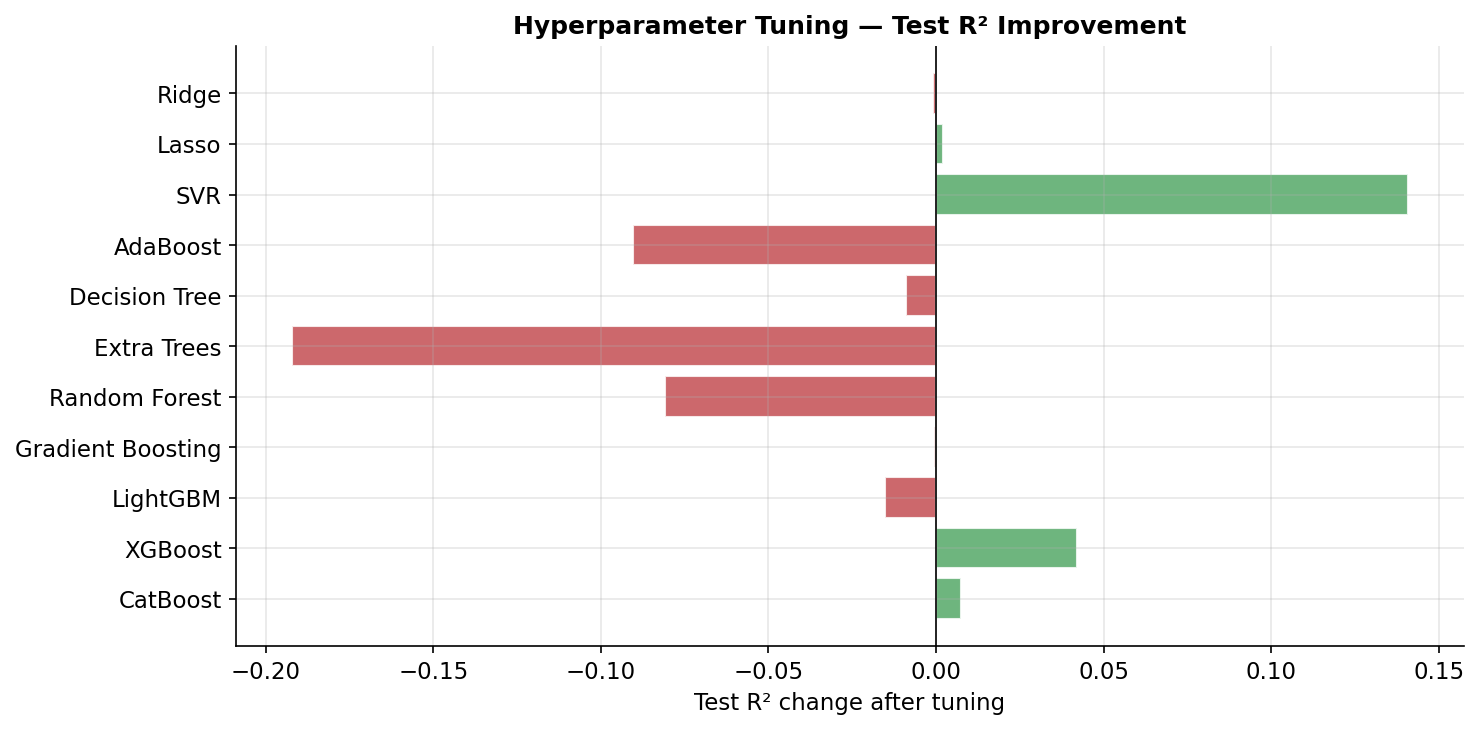

Saved: fig_8_1_tuning_improvement.png


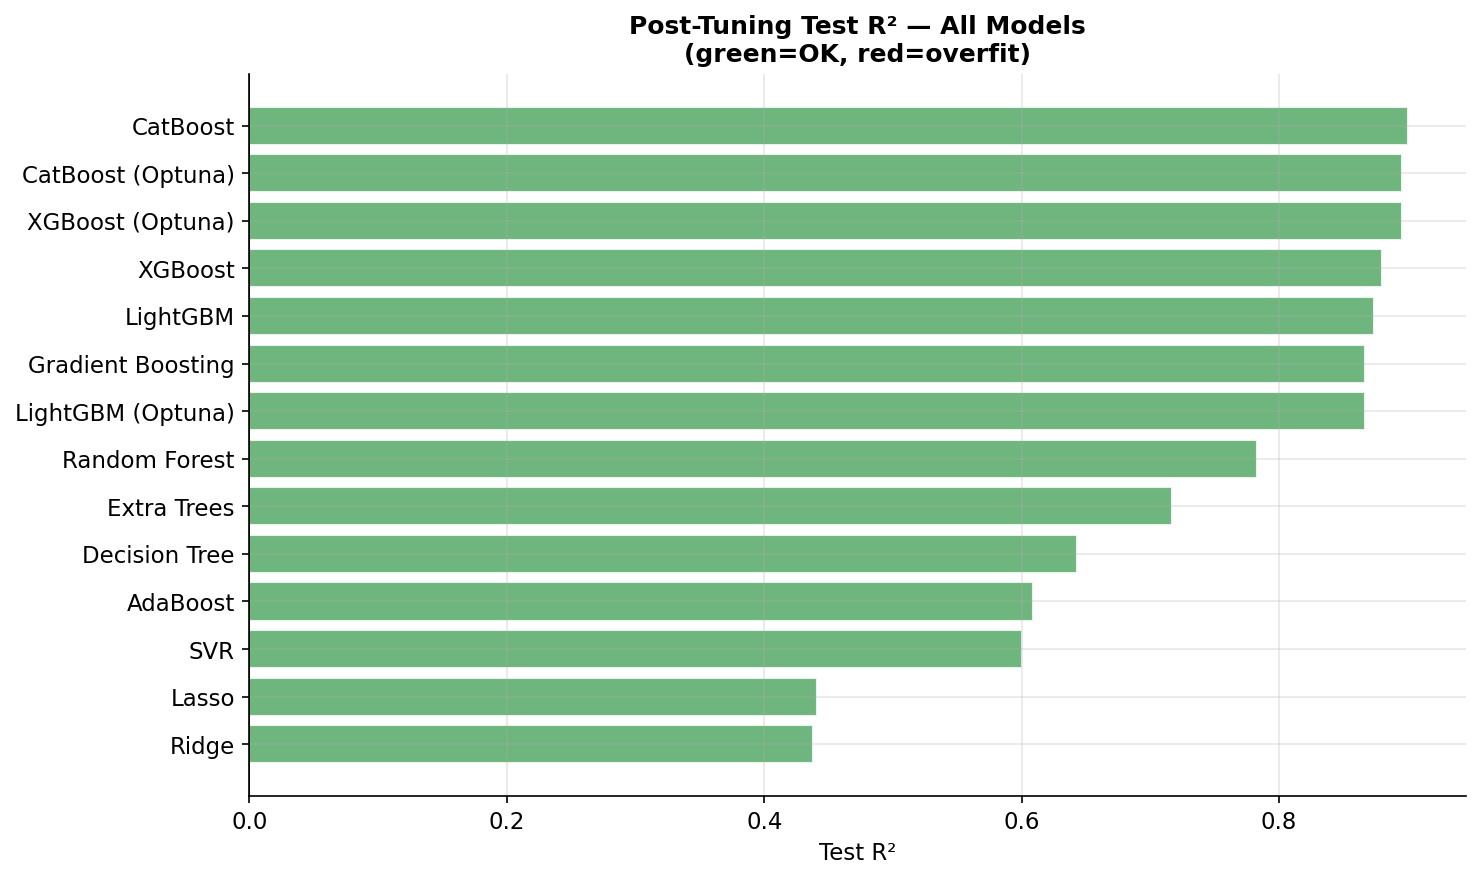

Saved: fig_8_2_post_tuning_leaderboard.png

Best pipelines available: ['Ridge', 'Lasso', 'SVR', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost', 'Extra Trees', 'AdaBoost', 'CatBoost (Optuna)', 'XGBoost (Optuna)', 'LightGBM (Optuna)']

Step 8 complete. Proceed to Step 9: Cross-Validation Report.


In [10]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 8: Hyperparameter Tuning — RandomizedSearchCV + Optuna
# =============================================================================
# Requires: X_train, y_train, build_pipeline(), fitted_pipelines, SEED
# =============================================================================

from sklearn.model_selection  import RandomizedSearchCV, KFold
from sklearn.linear_model     import Ridge, Lasso
from sklearn.svm              import SVR
from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import (RandomForestRegressor,
                                      GradientBoostingRegressor,
                                      ExtraTreesRegressor,
                                      AdaBoostRegressor)
from xgboost                  import XGBRegressor
from lightgbm                 import LGBMRegressor
from catboost                 import CatBoostRegressor
from scipy.stats              import uniform, randint
import time, warnings
warnings.filterwarnings("ignore")

FEATURES = [col for col in df_labeled.columns if col != TARGET]
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

# ------------------------------------------------------------
# 8.1  Search spaces  (regularisation-heavy to fight overfit)
# ------------------------------------------------------------
SEARCH_SPACES = {
    "Ridge": {
        "model": Ridge(),
        "params": {"model__alpha": uniform(0.1, 50)},
    },
    "Lasso": {
        "model": Lasso(max_iter=10000),
        "params": {"model__alpha": uniform(0.001, 5)},
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "model__C":       uniform(0.01, 10),
            "model__epsilon": uniform(0.01, 1.0),
            "model__kernel":  ["rbf", "linear"],
        },
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=SEED),
        "params": {
            "model__max_depth":        randint(2, 5),
            "model__min_samples_split":randint(4, 20),
            "model__min_samples_leaf": randint(3, 15),
            "model__max_features":     ["sqrt", "log2", None],
        },
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=SEED),
        "params": {
            "model__n_estimators":     randint(100, 500),
            "model__max_depth":        randint(2, 8),
            "model__min_samples_leaf": randint(3, 15),
            "model__max_features":     ["sqrt", "log2", 0.5],
        },
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=SEED),
        "params": {
            "model__n_estimators":     randint(50, 300),
            "model__max_depth":        randint(2, 4),
            "model__learning_rate":    uniform(0.01, 0.2),
            "model__subsample":        uniform(0.6, 0.4),
            "model__min_samples_leaf": randint(3, 15),
        },
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=SEED, verbosity=0,
                              eval_metric="rmse"),
        "params": {
            "model__n_estimators":  randint(50, 300),
            "model__max_depth":     randint(2, 5),
            "model__learning_rate": uniform(0.01, 0.2),
            "model__subsample":     uniform(0.6, 0.4),
            "model__colsample_bytree": uniform(0.5, 0.5),
            "model__reg_alpha":     uniform(0, 5),
            "model__reg_lambda":    uniform(1, 5),
        },
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=SEED, verbose=-1),
        "params": {
            "model__n_estimators":     randint(50, 300),
            "model__num_leaves":       randint(4, 20),
            "model__learning_rate":    uniform(0.01, 0.2),
            "model__min_child_samples":randint(5, 30),
            "model__reg_alpha":        uniform(0, 5),
            "model__reg_lambda":       uniform(0, 5),
        },
    },
    "CatBoost": {
        "model": CatBoostRegressor(random_state=SEED, verbose=0),
        "params": {
            "model__iterations":      randint(50, 300),
            "model__depth":           randint(2, 5),
            "model__learning_rate":   uniform(0.01, 0.2),
            "model__l2_leaf_reg":     uniform(1, 10),
            "model__min_data_in_leaf":randint(3, 15),
        },
    },
    "Extra Trees": {
        "model": ExtraTreesRegressor(random_state=SEED),
        "params": {
            "model__n_estimators":     randint(100, 500),
            "model__max_depth":        randint(3, 10),
            "model__min_samples_leaf": randint(2, 10),
            "model__max_features":     ["sqrt", "log2", 0.5],
        },
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=SEED),
        "params": {
            "model__n_estimators":  randint(50, 200),
            "model__learning_rate": uniform(0.01, 1.0),
            "model__estimator":     [
                DecisionTreeRegressor(max_depth=1, random_state=SEED),
                DecisionTreeRegressor(max_depth=2, random_state=SEED),
            ],
        },
    },
}

# ------------------------------------------------------------
# 8.2  RandomizedSearchCV for all models
# ------------------------------------------------------------
print("── 8.2  RandomizedSearchCV (n_iter=60, cv=10) ──────────")
print("Scoring: neg_root_mean_squared_error\n")

best_pipelines  = {}
tuning_rows     = []

for name, cfg in SEARCH_SPACES.items():
    pipe = build_pipeline(cfg["model"])
    rscv = RandomizedSearchCV(
        pipe,
        param_distributions=cfg["params"],
        n_iter=60,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,
        random_state=SEED,
        return_train_score=True,
    )
    t0 = time.time()
    rscv.fit(X_train, y_train)
    elapsed = round(time.time() - t0, 2)

    best_pipelines[name] = rscv.best_estimator_

    cv_rmse  = -rscv.best_score_
    best_p   = {k.replace("model__", ""): v
                for k, v in rscv.best_params_.items()}

    tuning_rows.append({
        "Model":           name,
        "Best CV RMSE":    round(cv_rmse, 4),
        "Best params":     str(best_p),
        "Time (s)":        elapsed,
    })
    print(f"  {name:<22} CV RMSE={cv_rmse:.4f}  [{elapsed}s]")
    print(f"    Best: {best_p}")

tuning_df = pd.DataFrame(tuning_rows).sort_values("Best CV RMSE")
print("\n── Tuning Leaderboard (by CV RMSE) ─────────────────────")
print(tuning_df[["Model","Best CV RMSE","Time (s)"]].to_string(index=False))

# ------------------------------------------------------------
# 8.3  Optuna — top 3 models from RandomizedSearch
# ------------------------------------------------------------
print("\n── 8.3  Optuna Bayesian Optimisation (top 3 models) ────")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    from sklearn.model_selection import cross_val_score

    top3 = tuning_df.head(3)["Model"].tolist()
    print(f"Top 3 models selected for Optuna: {top3}")

    def make_optuna_objective(model_name):
        def objective(trial):
            if model_name == "XGBoost":
                model = XGBRegressor(
                    n_estimators    = trial.suggest_int("n_estimators", 50, 400),
                    max_depth       = trial.suggest_int("max_depth", 2, 5),
                    learning_rate   = trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
                    subsample       = trial.suggest_float("subsample", 0.5, 1.0),
                    colsample_bytree= trial.suggest_float("colsample_bytree", 0.5, 1.0),
                    reg_alpha       = trial.suggest_float("reg_alpha", 0, 10),
                    reg_lambda      = trial.suggest_float("reg_lambda", 0.5, 10),
                    random_state=SEED, verbosity=0, eval_metric="rmse",
                )
            elif model_name == "LightGBM":
                model = LGBMRegressor(
                    n_estimators     = trial.suggest_int("n_estimators", 50, 400),
                    num_leaves       = trial.suggest_int("num_leaves", 4, 25),
                    learning_rate    = trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
                    min_child_samples= trial.suggest_int("min_child_samples", 5, 40),
                    reg_alpha        = trial.suggest_float("reg_alpha", 0, 10),
                    reg_lambda       = trial.suggest_float("reg_lambda", 0, 10),
                    random_state=SEED, verbose=-1,
                )
            elif model_name == "CatBoost":
                model = CatBoostRegressor(
                    iterations      = trial.suggest_int("iterations", 50, 400),
                    depth           = trial.suggest_int("depth", 2, 5),
                    learning_rate   = trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
                    l2_leaf_reg     = trial.suggest_float("l2_leaf_reg", 1, 15),
                    min_data_in_leaf= trial.suggest_int("min_data_in_leaf", 3, 20),
                    random_state=SEED, verbose=0,
                )
            elif model_name == "Random Forest":
                model = RandomForestRegressor(
                    n_estimators    = trial.suggest_int("n_estimators", 100, 600),
                    max_depth       = trial.suggest_int("max_depth", 2, 8),
                    min_samples_leaf= trial.suggest_int("min_samples_leaf", 2, 15),
                    max_features    = trial.suggest_categorical("max_features",
                                      ["sqrt", "log2", 0.5]),
                    random_state=SEED,
                )
            elif model_name == "Extra Trees":
                model = ExtraTreesRegressor(
                    n_estimators    = trial.suggest_int("n_estimators", 100, 600),
                    max_depth       = trial.suggest_int("max_depth", 3, 10),
                    min_samples_leaf= trial.suggest_int("min_samples_leaf", 2, 10),
                    max_features    = trial.suggest_categorical("max_features",
                                      ["sqrt", "log2", 0.5]),
                    random_state=SEED,
                )
            elif model_name == "Gradient Boosting":
                model = GradientBoostingRegressor(
                    n_estimators    = trial.suggest_int("n_estimators", 50, 300),
                    max_depth       = trial.suggest_int("max_depth", 2, 4),
                    learning_rate   = trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
                    subsample       = trial.suggest_float("subsample", 0.5, 1.0),
                    min_samples_leaf= trial.suggest_int("min_samples_leaf", 3, 15),
                    random_state=SEED,
                )
            elif model_name == "Ridge":
                model = Ridge(
                    alpha=trial.suggest_float("alpha", 0.01, 100, log=True)
                )
            elif model_name == "AdaBoost":
                model = AdaBoostRegressor(
                    n_estimators  = trial.suggest_int("n_estimators", 50, 300),
                    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0),
                    random_state=SEED,
                )
            else:
                return 999

            pipe  = build_pipeline(model)
            score = cross_val_score(pipe, X_train, y_train,
                                    cv=kf,
                                    scoring="neg_root_mean_squared_error",
                                    n_jobs=-1)
            return -score.mean()

        return objective

    optuna_rows = []
    for model_name in top3:
        if model_name not in [
            "XGBoost","LightGBM","CatBoost","Random Forest",
            "Extra Trees","Gradient Boosting","Ridge","AdaBoost"
        ]:
            print(f"  Skipping {model_name} — no Optuna space defined.")
            continue

        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(make_optuna_objective(model_name),
                       n_trials=80, show_progress_bar=False)

        best_val  = study.best_value
        best_par  = study.best_params

        # Rebuild best pipeline
        if model_name == "XGBoost":
            best_model = XGBRegressor(**best_par, random_state=SEED,
                                      verbosity=0, eval_metric="rmse")
        elif model_name == "LightGBM":
            best_model = LGBMRegressor(**best_par, random_state=SEED, verbose=-1)
        elif model_name == "CatBoost":
            best_model = CatBoostRegressor(**best_par, random_state=SEED, verbose=0)
        elif model_name == "Random Forest":
            best_model = RandomForestRegressor(**best_par, random_state=SEED)
        elif model_name == "Extra Trees":
            best_model = ExtraTreesRegressor(**best_par, random_state=SEED)
        elif model_name == "Gradient Boosting":
            best_model = GradientBoostingRegressor(**best_par, random_state=SEED)
        elif model_name == "Ridge":
            best_model = Ridge(**best_par)
        elif model_name == "AdaBoost":
            best_model = AdaBoostRegressor(**best_par, random_state=SEED)

        optuna_pipe = build_pipeline(best_model)
        optuna_pipe.fit(X_train, y_train)
        best_pipelines[f"{model_name} (Optuna)"] = optuna_pipe

        optuna_rows.append({
            "Model":          f"{model_name} (Optuna)",
            "Best CV RMSE":   round(best_val, 4),
            "Best params":    str(best_par),
        })
        print(f"  {model_name} (Optuna)  CV RMSE={best_val:.4f}")
        print(f"    Best: {best_par}")

    if optuna_rows:
        optuna_df = pd.DataFrame(optuna_rows)
        print("\nOptuna results:")
        print(optuna_df[["Model","Best CV RMSE"]].to_string(index=False))

except ImportError:
    print("Optuna not installed — skipping. Run: !pip install optuna -q")

# ------------------------------------------------------------
# 8.4  Overfitting check after tuning
# ------------------------------------------------------------
print("\n── 8.4  Overfitting Check After Tuning ─────────────────")

from sklearn.metrics import r2_score

post_rows = []
for name, pipe in best_pipelines.items():
    y_tr = pipe.predict(X_train)
    y_te = pipe.predict(X_test)
    r2_tr = r2_score(y_train, y_tr)
    r2_te = r2_score(y_test,  y_te)
    gap   = r2_tr - r2_te
    post_rows.append({
        "Model":    name,
        "Train R²": round(r2_tr, 4),
        "Test R²":  round(r2_te, 4),
        "Gap":      round(gap,   4),
        "Status":   "overfit" if gap > 0.15 else "OK",
    })

post_df = pd.DataFrame(post_rows).sort_values("Test R²", ascending=False)
print(post_df.to_string(index=False))

# ------------------------------------------------------------
# 8.5  Tuning improvement visualisation
# ------------------------------------------------------------
print("\n── 8.5  Tuning Improvement Plot ────────────────────────")

# Merge pre- and post-tuning test R²
pre_r2  = {row["Model"]: row["Test R²"] for _, row in prelim_df.iterrows()}
post_r2 = {row["Model"]: row["Test R²"] for _, row in post_df.iterrows()
           if "(Optuna)" not in row["Model"]}

common  = [m for m in post_r2 if m in pre_r2]
deltas  = [post_r2[m] - pre_r2[m] for m in common]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["#55A868" if d >= 0 else "#C44E52" for d in deltas]
ax.barh(common, deltas, color=colors, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Test R² change after tuning")
ax.set_title("Hyperparameter Tuning — Test R² Improvement",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_8_1_tuning_improvement.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_8_1_tuning_improvement.png")

# Final leaderboard
fig, ax = plt.subplots(figsize=(10, 6))
post_sorted = post_df.sort_values("Test R²")
colors = ["#55A868" if s == "OK" else "#C44E52"
          for s in post_sorted["Status"]]
ax.barh(post_sorted["Model"], post_sorted["Test R²"],
        color=colors, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Test R²")
ax.set_title("Post-Tuning Test R² — All Models\n(green=OK, red=overfit)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_8_2_post_tuning_leaderboard.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: fig_8_2_post_tuning_leaderboard.png")

print(f"\nBest pipelines available: {list(best_pipelines.keys())}")
print("\nStep 8 complete. Proceed to Step 9: Cross-Validation Report.")

In [11]:
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np
import warnings
warnings.filterwarnings("ignore")

def clean_params(params):
    """Convert all numpy scalar types to native Python types."""
    cleaned = {}
    for k, v in params.items():
        if isinstance(v, (np.integer,)):
            cleaned[k] = int(v)
        elif isinstance(v, (np.floating,)):
            cleaned[k] = float(v)
        elif isinstance(v, (np.bool_,)):
            cleaned[k] = bool(v)
        else:
            cleaned[k] = v
    return cleaned

# Rebuild every Optuna pipeline with clean native Python params
for name in ["CatBoost (Optuna)", "XGBoost (Optuna)", "Gradient Boosting (Optuna)"]:
    if name not in best_pipelines:
        continue
    old_model  = best_pipelines[name].named_steps["model"]
    raw_params = old_model.get_params()
    clean      = clean_params(raw_params)

    if "CatBoost" in name:
        new_model = CatBoostRegressor(**clean)
    elif "XGBoost" in name:
        new_model = XGBRegressor(**clean)
    elif "Gradient Boosting" in name:
        from sklearn.ensemble import GradientBoostingRegressor
        new_model = GradientBoostingRegressor(**clean)

    new_pipe = build_pipeline(new_model)
    new_pipe.fit(X_train, y_train)
    best_pipelines[name] = new_pipe
    print(f"Rebuilt: {name}")

print("All Optuna pipelines cleaned. Now re-run Step 9.")

Rebuilt: CatBoost (Optuna)
Rebuilt: XGBoost (Optuna)
All Optuna pipelines cleaned. Now re-run Step 9.


Models carried forward: ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost', 'Extra Trees', 'AdaBoost', 'CatBoost (Optuna)', 'XGBoost (Optuna)']

── 9.1  10-Fold Cross-Validation (tuned pipelines) ─────
  Random Forest                R²=0.7523 ±0.0840  RMSE=8.2321  MAE=6.2702
  Gradient Boosting            R²=0.8388 ±0.0571  RMSE=6.6330  MAE=4.8721
  XGBoost                      R²=0.8487 ±0.0571  RMSE=6.3921  MAE=4.6566


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

  LightGBM                     R²=0.8499 ±0.0453  RMSE=6.3995  MAE=4.4432
  CatBoost                     R²=0.8551 ±0.0483  RMSE=6.2658  MAE=4.4831
  Extra Trees                  R²=0.6897 ±0.0715  RMSE=9.2982  MAE=7.0412
  AdaBoost                     R²=0.5200 ±0.1030  RMSE=11.5246  MAE=8.9971
  CatBoost (Optuna)            R²=0.8647 ±0.0475  RMSE=6.0513  MAE=4.4191
  XGBoost (Optuna)             R²=0.8539 ±0.0499  RMSE=6.2786  MAE=4.4574

── CV Leaderboard ───────────────────────────────────────
            Model  CV R² mean  CV R² std  CV R² min  CV R² max  CV RMSE mean  CV RMSE std  CV MAE mean
CatBoost (Optuna)       0.865      0.048      0.764      0.926         6.051        0.889        4.419
         CatBoost       0.855      0.048      0.772      0.929         6.266        0.943        4.483
 XGBoost (Optuna)       0.854      0.050      0.777      0.934         6.279        0.975        4.457
         LightGBM       0.850      0.045      0.780      0.929         6.399        

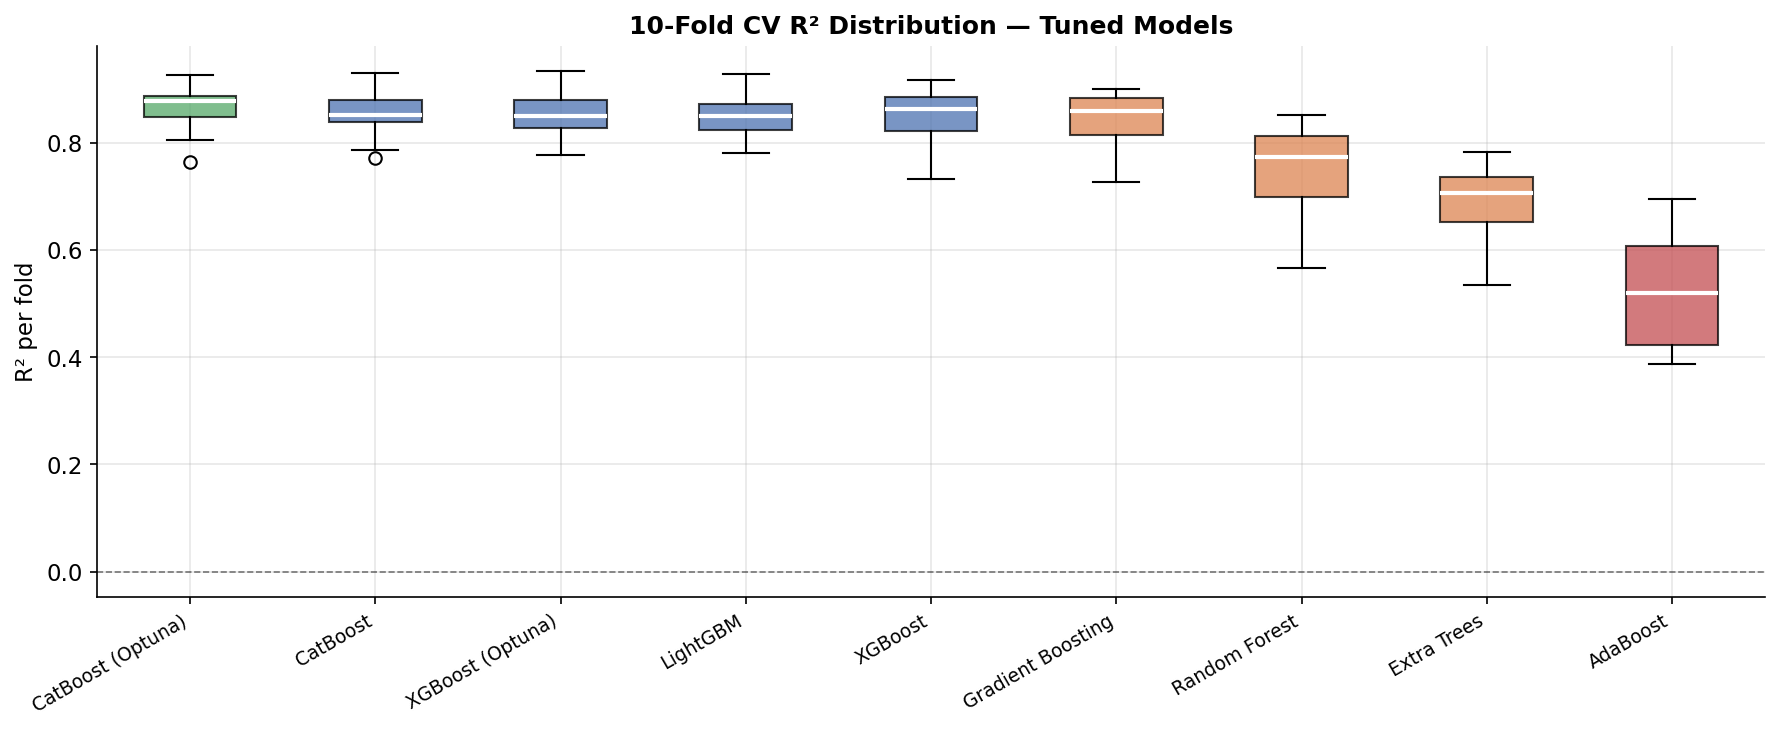

Saved: fig_9_1_cv_r2_boxplot.png


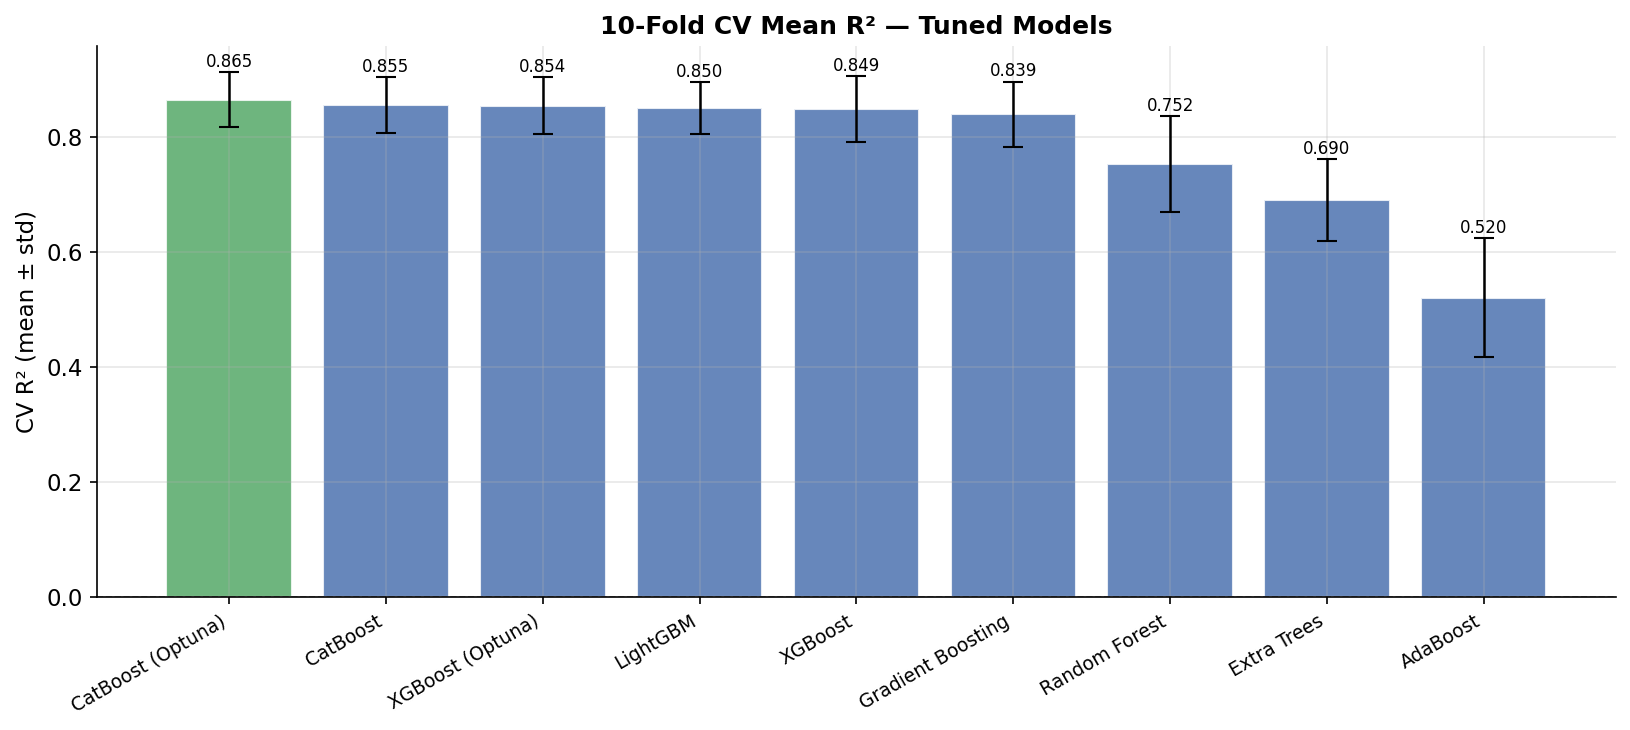

Saved: fig_9_2_cv_mean_r2_bar.png


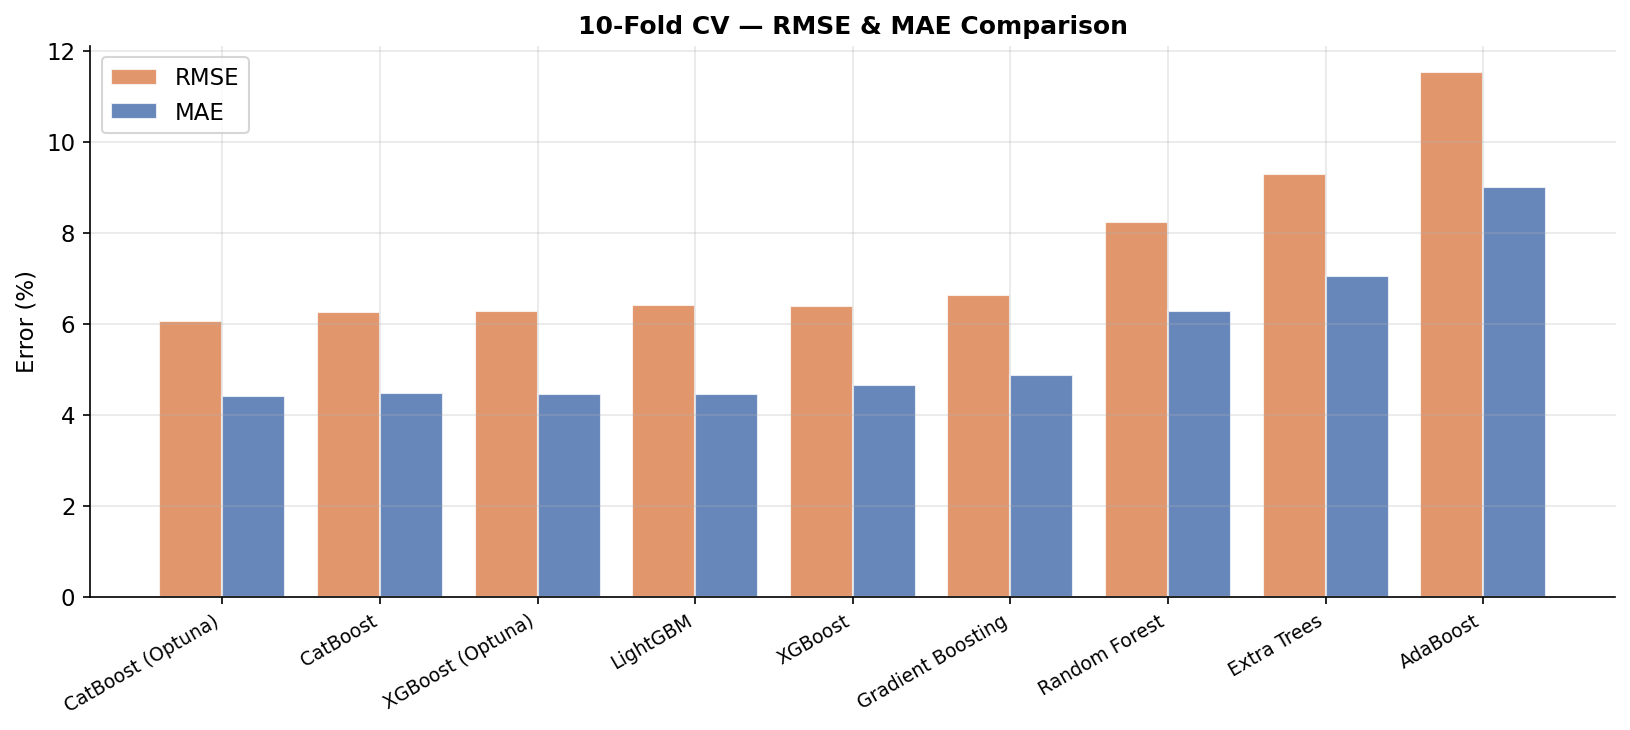

Saved: fig_9_3_cv_rmse_mae.png

── 9.4  Learning Curves (top 3 models) ─────────────────


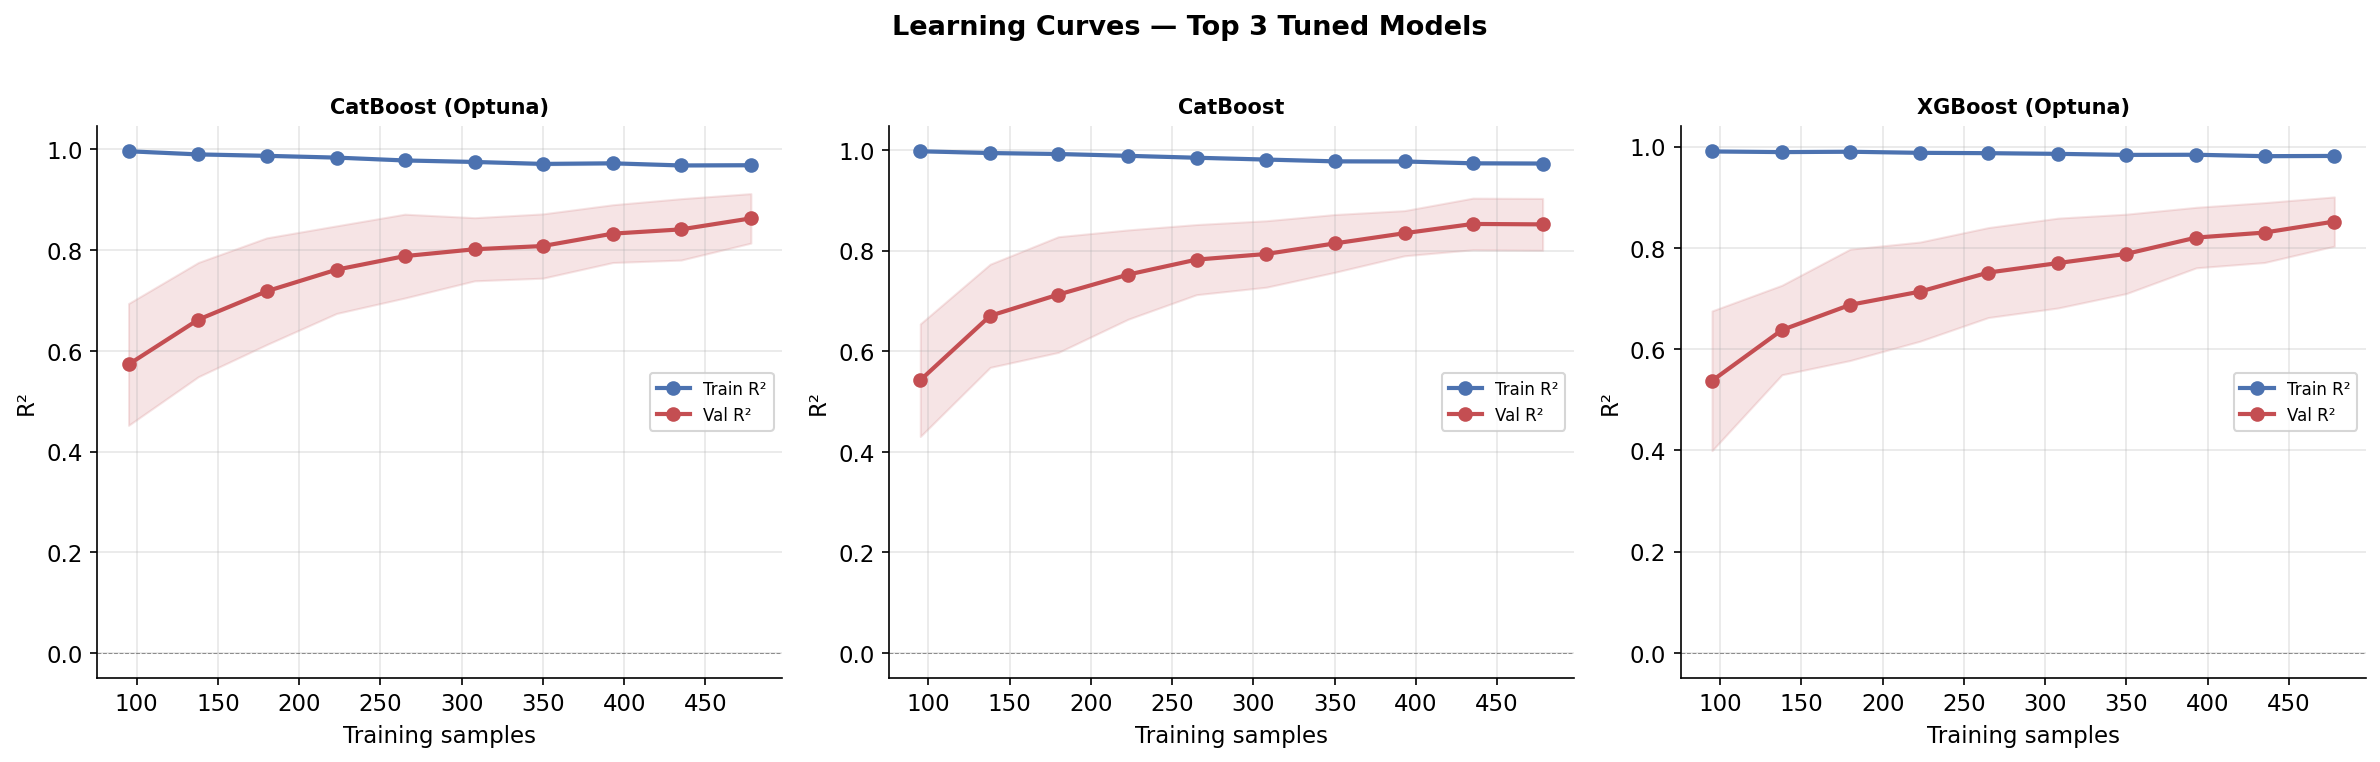

Saved: fig_9_4_learning_curves.png

── 9.5  Model Stability (CV R² std ranking) ────────────
            Model  CV R² mean  CV R² std  Stability rank  Performance rank  Combined rank
CatBoost (Optuna)       0.865      0.048               2                 1          1.500
         CatBoost       0.855      0.048               3                 2          2.500
         LightGBM       0.850      0.045               1                 4          2.500
 XGBoost (Optuna)       0.854      0.050               4                 3          3.500
          XGBoost       0.849      0.057               5                 5          5.000
Gradient Boosting       0.839      0.057               5                 6          5.500
    Random Forest       0.752      0.084               8                 7          7.500
      Extra Trees       0.690      0.071               7                 8          7.500
         AdaBoost       0.520      0.103               9                 9          9.000

Note: 

In [12]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 9: Cross-Validation Report
# =============================================================================
# Requires: best_pipelines, X_train, y_train, X_test, y_test, SEED
# =============================================================================

from sklearn.model_selection import KFold, cross_validate, learning_curve
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from catboost import CatBoostRegressor
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Helper: rebuild CatBoost pipelines with clone-safe params
# ------------------------------------------------------------
def sanitize_catboost_pipeline(pipe):
    """
    Rebuild CatBoost pipelines manually so sklearn can clone them safely.
    Assumes the final pipeline step is the estimator.
    """
    steps = pipe.steps
    last_name, last_estimator = steps[-1]

    if not isinstance(last_estimator, CatBoostRegressor):
        return pipe

    params = last_estimator.get_params()

    clean_params = {}
    for k, v in params.items():
        if isinstance(v, np.integer):
            clean_params[k] = int(v)
        elif isinstance(v, np.floating):
            clean_params[k] = float(v)
        elif isinstance(v, np.bool_):
            clean_params[k] = bool(v)
        else:
            clean_params[k] = v

    clean_model = CatBoostRegressor(**clean_params)

    # clone all earlier steps only, then attach clean CatBoost
    new_steps = []
    for step_name, step_obj in steps[:-1]:
        new_steps.append((step_name, clone(step_obj)))
    new_steps.append((last_name, clean_model))

    return Pipeline(new_steps)

# ------------------------------------------------------------
# Filter to good models only
# ------------------------------------------------------------
KEEP_MODELS = [
    "XGBoost (Optuna)", "Gradient Boosting (Optuna)", "XGBoost",
    "Gradient Boosting", "LightGBM", "CatBoost (Optuna)",
    "CatBoost", "Extra Trees", "Random Forest", "AdaBoost"
]

best_pipelines = {k: v for k, v in best_pipelines.items() if k in KEEP_MODELS}

# Sanitize CatBoost pipelines before CV
for k in list(best_pipelines.keys()):
    best_pipelines[k] = sanitize_catboost_pipeline(best_pipelines[k])

print(f"Models carried forward: {list(best_pipelines.keys())}\n")

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

# ------------------------------------------------------------
# 9.1  10-fold CV on each tuned pipeline
# ------------------------------------------------------------
print("── 9.1  10-Fold Cross-Validation (tuned pipelines) ─────")

cv9_rows = []
cv9_detail = {}

for name, pipe in best_pipelines.items():
    cv = cross_validate(
        pipe, X_train, y_train,
        cv=kf,
        scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
        return_train_score=True,
        n_jobs=-1,
    )

    r2_folds = cv["test_r2"]
    rmse_folds = -cv["test_neg_root_mean_squared_error"]
    mae_folds = -cv["test_neg_mean_absolute_error"]

    cv9_detail[name] = cv

    cv9_rows.append({
        "Model": name,
        "CV R² mean": round(r2_folds.mean(), 4),
        "CV R² std": round(r2_folds.std(), 4),
        "CV R² min": round(r2_folds.min(), 4),
        "CV R² max": round(r2_folds.max(), 4),
        "CV RMSE mean": round(rmse_folds.mean(), 4),
        "CV RMSE std": round(rmse_folds.std(), 4),
        "CV MAE mean": round(mae_folds.mean(), 4),
    })

    print(
        f"  {name:<28} R²={r2_folds.mean():.4f} ±{r2_folds.std():.4f}  "
        f"RMSE={rmse_folds.mean():.4f}  MAE={mae_folds.mean():.4f}"
    )

cv9_df = pd.DataFrame(cv9_rows).sort_values("CV R² mean", ascending=False)

print("\n── CV Leaderboard ───────────────────────────────────────")
print(cv9_df.to_string(index=False))

# ------------------------------------------------------------
# 9.2  Per-fold R² table (all 10 folds per model)
# ------------------------------------------------------------
print("\n── 9.2  Per-Fold R² Breakdown ───────────────────────────")

fold_rows = {}
for name in cv9_df["Model"]:
    folds = cv9_detail[name]["test_r2"]
    fold_rows[name] = [round(f, 4) for f in folds]

fold_df = pd.DataFrame(
    fold_rows,
    index=[f"Fold {i+1}" for i in range(10)]
).T
fold_df["Mean"] = fold_df.mean(axis=1).round(4)
fold_df["Std"] = fold_df.std(axis=1).round(4)

print(fold_df.to_string())

# ------------------------------------------------------------
# 9.3  CV R² distribution — boxplot
# ------------------------------------------------------------
print("\n── 9.3  CV Visualisations ───────────────────────────────")

model_order = cv9_df["Model"].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
r2_data = [cv9_detail[n]["test_r2"] for n in model_order]

bp = ax.boxplot(
    r2_data,
    patch_artist=True,
    vert=True,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1)
)

palette = [
    "#55A868", "#4C72B0", "#4C72B0", "#4C72B0", "#4C72B0",
    "#DD8452", "#DD8452", "#DD8452", "#C44E52", "#C44E52"
]
for patch, color in zip(bp["boxes"], palette[:len(bp["boxes"])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(model_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("R² per fold")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("10-Fold CV R² Distribution — Tuned Models",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_9_1_cv_r2_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_9_1_cv_r2_boxplot.png")

# Mean R² + std error bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(cv9_df))
colors = ["#55A868" if i == 0 else "#4C72B0" for i in x]

ax.bar(
    x,
    cv9_df["CV R² mean"],
    yerr=cv9_df["CV R² std"],
    color=colors,
    edgecolor="white",
    alpha=0.85,
    capsize=5,
    error_kw=dict(elinewidth=1.2)
)

ax.set_xticks(list(x))
ax.set_xticklabels(cv9_df["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("CV R² (mean ± std)")
ax.set_title("10-Fold CV Mean R² — Tuned Models",
             fontsize=12, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

for i, (_, row) in enumerate(cv9_df.iterrows()):
    ax.text(
        i,
        row["CV R² mean"] + row["CV R² std"] + 0.01,
        f"{row['CV R² mean']:.3f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("/kaggle/working/fig_9_2_cv_mean_r2_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_9_2_cv_mean_r2_bar.png")

# RMSE + MAE grouped bar
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cv9_df))
width = 0.4

ax.bar(
    x - width/2,
    cv9_df["CV RMSE mean"],
    width,
    label="RMSE",
    color="#DD8452",
    edgecolor="white",
    alpha=0.85
)
ax.bar(
    x + width/2,
    cv9_df["CV MAE mean"],
    width,
    label="MAE",
    color="#4C72B0",
    edgecolor="white",
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(cv9_df["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Error (%)")
ax.set_title("10-Fold CV — RMSE & MAE Comparison",
             fontsize=12, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/fig_9_3_cv_rmse_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_9_3_cv_rmse_mae.png")

# ------------------------------------------------------------
# 9.4  Learning curves — top 3 models
# ------------------------------------------------------------
print("\n── 9.4  Learning Curves (top 3 models) ─────────────────")

top3 = cv9_df.head(3)["Model"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if len(top3) == 1:
    axes = [axes]

for idx, name in enumerate(top3):
    pipe = best_pipelines[name]
    ax = axes[idx]

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        cv=kf,
        scoring="r2",
        train_sizes=np.linspace(0.2, 1.0, 10),
        n_jobs=-1,
    )

    tr_mean = train_scores.mean(axis=1)
    tr_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, "o-", color="#4C72B0",
            linewidth=2, label="Train R²")
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color="#4C72B0")

    ax.plot(train_sizes, val_mean, "o-", color="#C44E52",
            linewidth=2, label="Val R²")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color="#C44E52")

    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("R²")
    ax.legend(fontsize=8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)

plt.suptitle("Learning Curves — Top 3 Tuned Models",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_9_4_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_9_4_learning_curves.png")

# ------------------------------------------------------------
# 9.5  Model stability analysis
# ------------------------------------------------------------
print("\n── 9.5  Model Stability (CV R² std ranking) ────────────")

stability = cv9_df[["Model", "CV R² mean", "CV R² std"]].copy()
stability["Stability rank"] = stability["CV R² std"].rank().astype(int)
stability["Performance rank"] = stability["CV R² mean"].rank(ascending=False).astype(int)
stability["Combined rank"] = (
    stability["Stability rank"] + stability["Performance rank"]
) / 2
stability = stability.sort_values("Combined rank")

print(stability.to_string(index=False))
print("\nNote: lower std = more stable across folds.")
print("Combined rank balances both R² performance and stability.")

# ------------------------------------------------------------
# 9.6  Summary
# ------------------------------------------------------------
print("\n── 9.6  Summary ─────────────────────────────────────────")

best_cv = cv9_df.iloc[0]
print(f"  Best model by CV R²   : {best_cv['Model']}")
print(f"  CV R² mean            : {best_cv['CV R² mean']}")
print(f"  CV R² std             : {best_cv['CV R² std']}")
print(f"  CV RMSE mean          : {best_cv['CV RMSE mean']}")
print(f"  CV MAE mean           : {best_cv['CV MAE mean']}")
print(f"\n  Most stable model     : {stability.iloc[0]['Model']}")
print(f"  Stability (R² std)    : {stability.iloc[0]['CV R² std']}")
print("\nStep 9 complete. Proceed to Step 10: Model Evaluation.")

── 10.1  Train/Test Evaluation ─────────────────────────
Random Forest                Train R²=0.8659 | Test R²=0.7829 | Test RMSE=8.3252 | Test MAE=5.8813
Gradient Boosting            Train R²=0.9583 | Test R²=0.8669 | Test RMSE=6.5179 | Test MAE=4.7055
XGBoost                      Train R²=0.9691 | Test R²=0.8799 | Test RMSE=6.1923 | Test MAE=4.4921
LightGBM                     Train R²=0.9805 | Test R²=0.8737 | Test RMSE=6.3510 | Test MAE=4.3604
CatBoost                     Train R²=0.9727 | Test R²=0.8998 | Test RMSE=5.6569 | Test MAE=4.1699
Extra Trees                  Train R²=0.8033 | Test R²=0.7167 | Test RMSE=9.5106 | Test MAE=7.1811
AdaBoost                     Train R²=0.5652 | Test R²=0.6087 | Test RMSE=11.1769 | Test MAE=8.5467
CatBoost (Optuna)            Train R²=0.9662 | Test R²=0.8957 | Test RMSE=5.7695 | Test MAE=4.3396
XGBoost (Optuna)             Train R²=0.9801 | Test R²=0.8953 | Test RMSE=5.7827 | Test MAE=4.1014

── 10.2  Evaluation Leaderboard ──────────────────

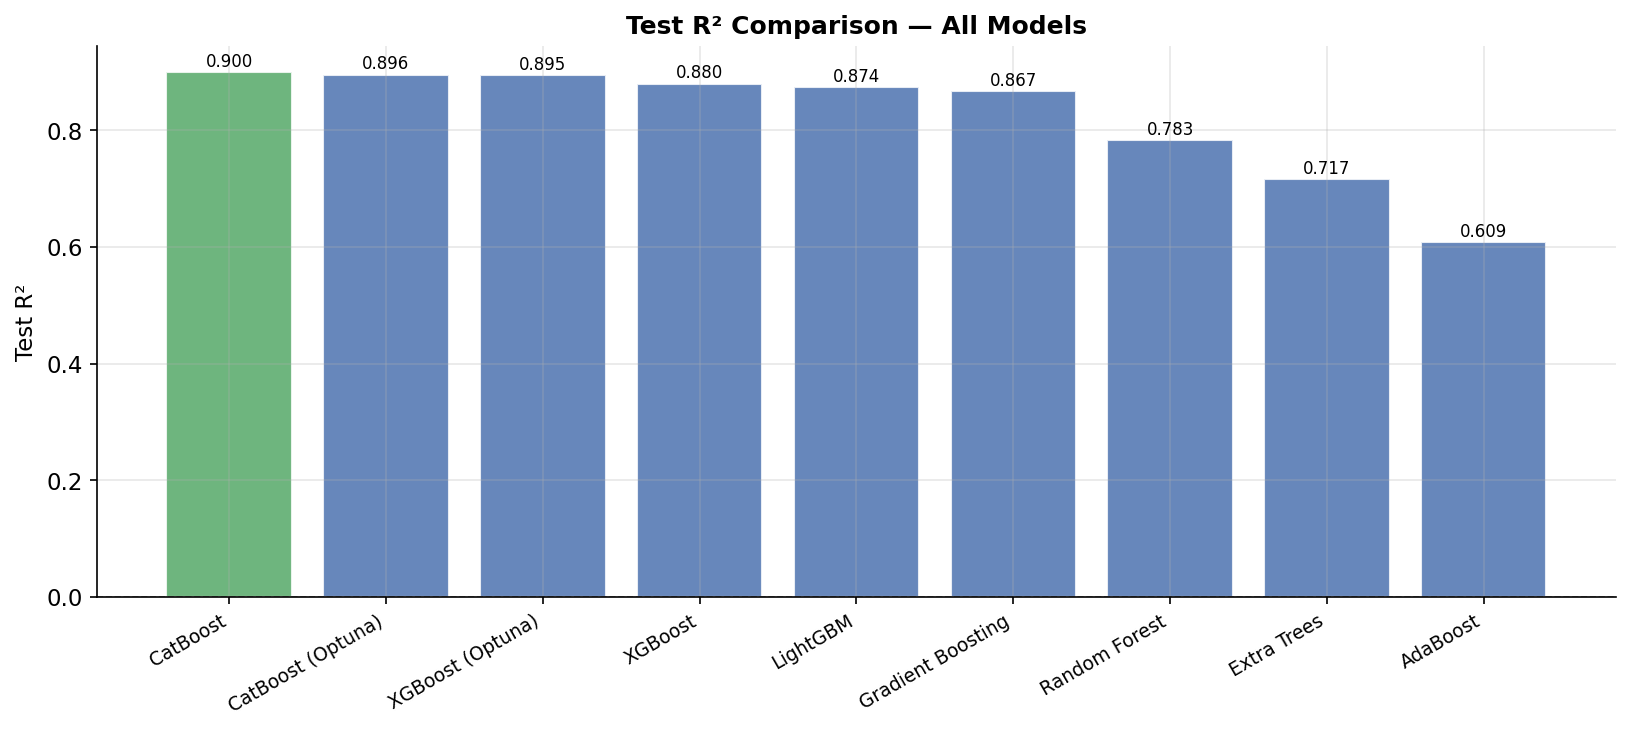

Saved: fig_10_1_test_r2_bar.png


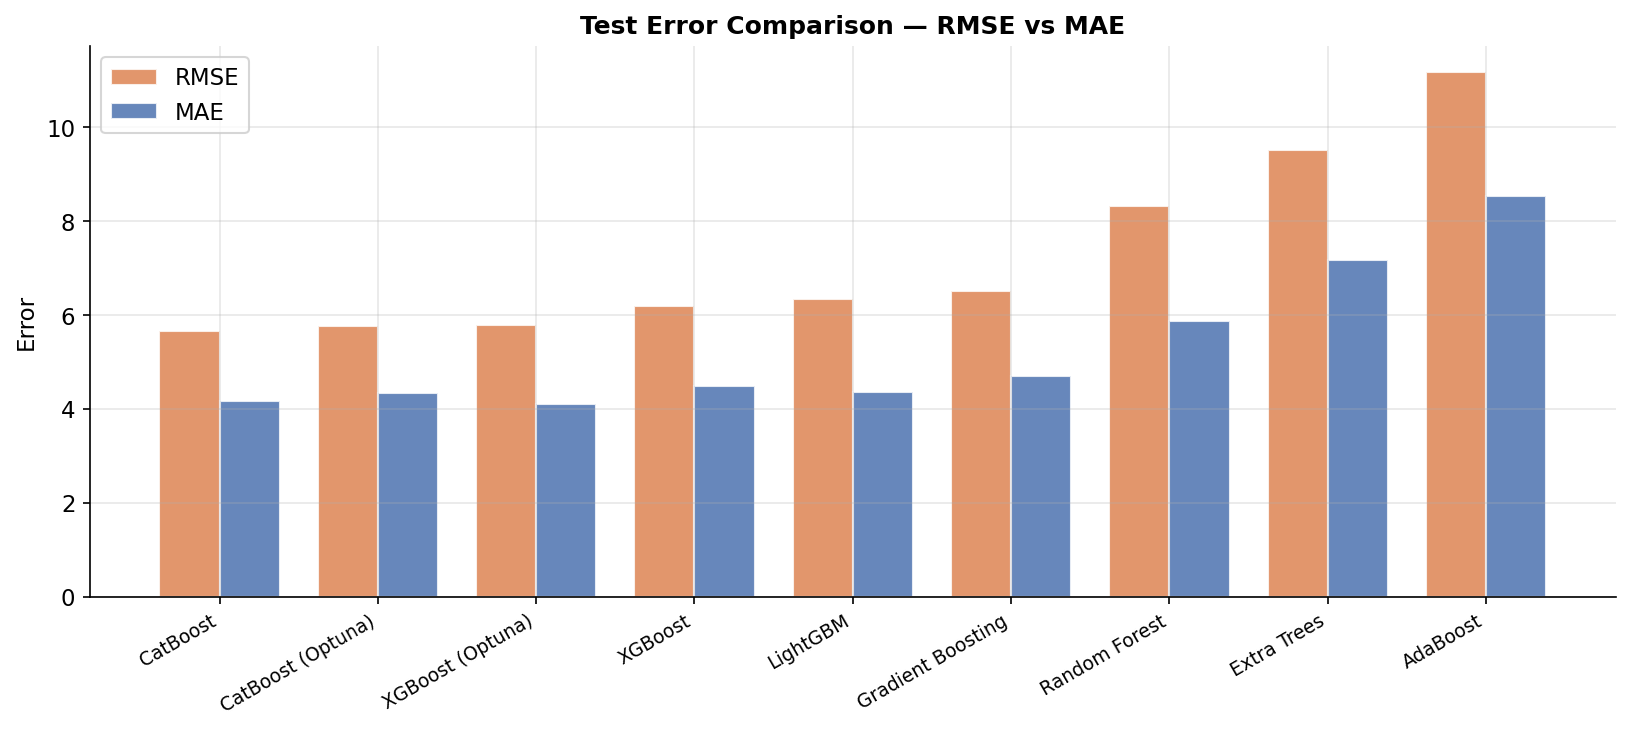

Saved: fig_10_2_test_rmse_mae.png


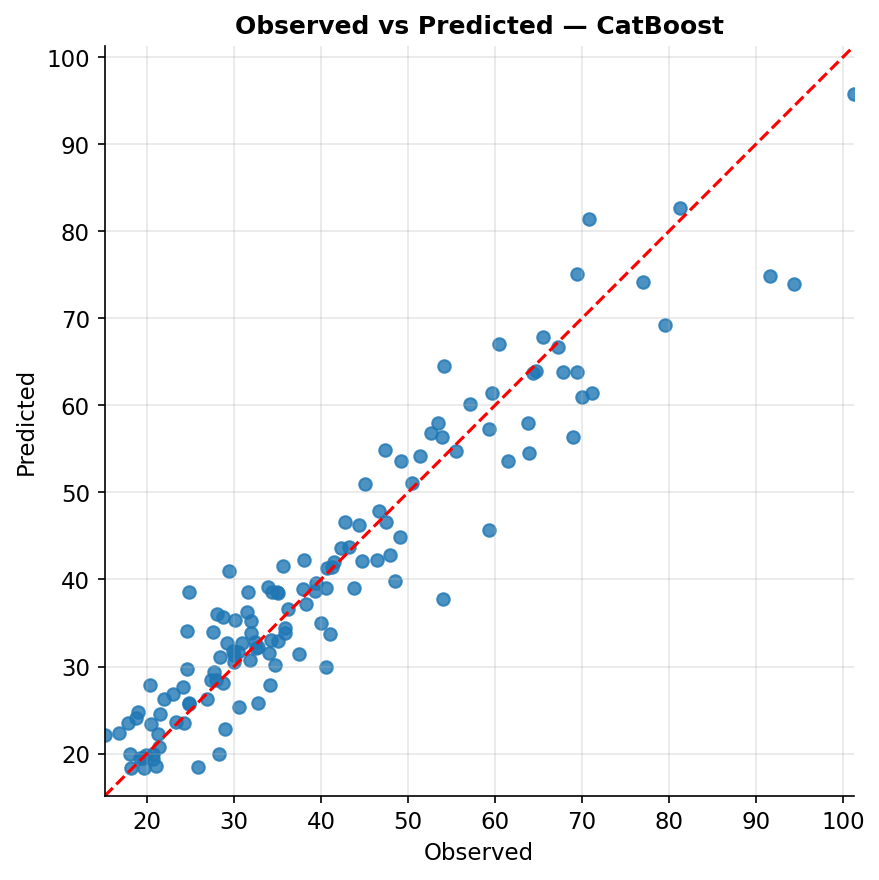

Saved: fig_10_3_observed_vs_predicted_best.png


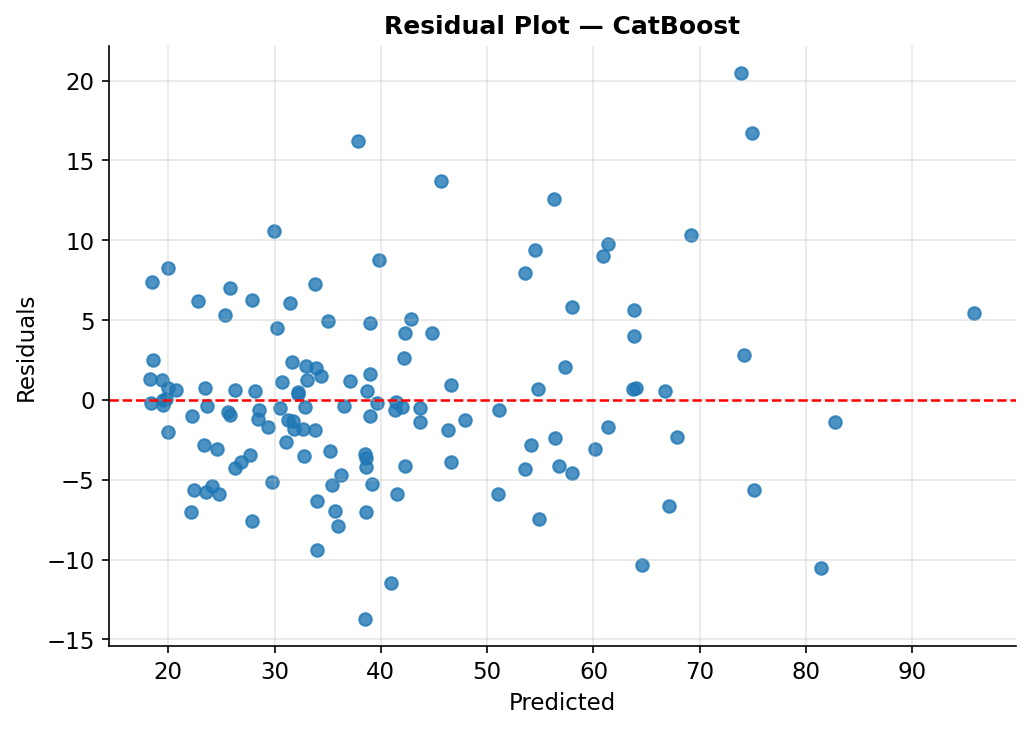

Saved: fig_10_4_residual_plot_best.png

── 10.6  Conclusion ────────────────────────────────────
Best overall model based on test performance: CatBoost
Use the test metrics above for final reporting.
Step 10 complete.


In [13]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 10: Model Evaluation
# =============================================================================
# Requires: best_pipelines, X_train, y_train, X_test, y_test
# =============================================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Helper metrics
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def nse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom == 0:
        return np.nan
    return 1 - (np.sum((y_true - y_pred) ** 2) / denom)

def calc_aic_bic(y_true, y_pred, k):
    """
    AIC and BIC using residual sum of squares for regression.
    k = number of parameters/features used in approximation.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)

    # prevent log(0)
    rss = max(rss, 1e-12)

    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return aic, bic

# ------------------------------------------------------------
# Estimate parameter count k for AIC/BIC
# ------------------------------------------------------------
def estimate_k(pipe, X):
    """
    Approximate parameter count for model complexity.
    Falls back to number of input features if model-specific count unavailable.
    """
    try:
        model = pipe.steps[-1][1]
    except:
        return X.shape[1]

    # linear models
    if hasattr(model, "coef_"):
        try:
            return np.size(model.coef_) + 1
        except:
            pass

    # trees / ensemble heuristics
    if hasattr(model, "n_estimators"):
        try:
            base = int(model.n_estimators)
            extra = getattr(model, "max_depth", None)
            if extra is None:
                return max(base, X.shape[1])
            return max(base * max(int(extra), 1), X.shape[1])
        except:
            pass

    # catboost / boosting fallback
    if hasattr(model, "get_params"):
        params = model.get_params()
        if "iterations" in params:
            try:
                return max(int(params["iterations"]), X.shape[1])
            except:
                pass

    return X.shape[1]

# ------------------------------------------------------------
# Models to evaluate
# ------------------------------------------------------------
KEEP_MODELS = [
    "XGBoost (Optuna)", "Gradient Boosting (Optuna)", "XGBoost",
    "Gradient Boosting", "LightGBM", "CatBoost (Optuna)",
    "CatBoost", "Extra Trees", "Random Forest", "AdaBoost"
]

eval_pipelines = {k: v for k, v in best_pipelines.items() if k in KEEP_MODELS}

print("── 10.1  Train/Test Evaluation ─────────────────────────")

eval_rows = []
pred_store = {}

for name, pipe in eval_pipelines.items():
    # fit on full training data
    pipe.fit(X_train, y_train)

    # predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)

    pred_store[name] = {
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred
    }

    # parameter count approximation
    k_train = estimate_k(pipe, X_train)
    k_test  = estimate_k(pipe, X_test)

    # train metrics
    train_r2   = r2_score(y_train, y_train_pred)
    train_rmse = rmse(y_train, y_train_pred)
    train_mae  = mean_absolute_error(y_train, y_train_pred)
    train_mape = mape(y_train, y_train_pred)
    train_nse  = nse(y_train, y_train_pred)
    train_aic, train_bic = calc_aic_bic(y_train, y_train_pred, k_train)

    # test metrics
    test_r2   = r2_score(y_test, y_test_pred)
    test_rmse = rmse(y_test, y_test_pred)
    test_mae  = mean_absolute_error(y_test, y_test_pred)
    test_mape = mape(y_test, y_test_pred)
    test_nse  = nse(y_test, y_test_pred)
    test_aic, test_bic = calc_aic_bic(y_test, y_test_pred, k_test)

    eval_rows.append({
        "Model": name,

        "Train R²": round(train_r2, 4),
        "Train RMSE": round(train_rmse, 4),
        "Train MAE": round(train_mae, 4),
        "Train MAPE (%)": round(train_mape, 4),
        "Train NSE": round(train_nse, 4),
        "Train AIC": round(train_aic, 4),
        "Train BIC": round(train_bic, 4),

        "Test R²": round(test_r2, 4),
        "Test RMSE": round(test_rmse, 4),
        "Test MAE": round(test_mae, 4),
        "Test MAPE (%)": round(test_mape, 4),
        "Test NSE": round(test_nse, 4),
        "Test AIC": round(test_aic, 4),
        "Test BIC": round(test_bic, 4),
    })

    print(
        f"{name:<28} "
        f"Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | "
        f"Test RMSE={test_rmse:.4f} | Test MAE={test_mae:.4f}"
    )

eval_df = pd.DataFrame(eval_rows).sort_values(
    by=["Test R²", "Test RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n── 10.2  Evaluation Leaderboard ────────────────────────")
print(eval_df.to_string(index=False))

# ------------------------------------------------------------
# 10.3  Overfitting check
# ------------------------------------------------------------
print("\n── 10.3  Generalisation Gap ────────────────────────────")

gap_df = eval_df[["Model", "Train R²", "Test R²"]].copy()
gap_df["R² Gap"] = (gap_df["Train R²"] - gap_df["Test R²"]).round(4)
gap_df = gap_df.sort_values("R² Gap")

print(gap_df.to_string(index=False))
print("\nSmaller R² gap usually indicates better generalisation.")

# ------------------------------------------------------------
# 10.4  Best model summary
# ------------------------------------------------------------
print("\n── 10.4  Best Model Summary ────────────────────────────")

best_model_row = eval_df.iloc[0]
best_model_name = best_model_row["Model"]

print(f"Best model on test set : {best_model_name}")
print(f"Test R²                : {best_model_row['Test R²']}")
print(f"Test RMSE              : {best_model_row['Test RMSE']}")
print(f"Test MAE               : {best_model_row['Test MAE']}")
print(f"Test MAPE (%)          : {best_model_row['Test MAPE (%)']}")
print(f"Test NSE               : {best_model_row['Test NSE']}")
print(f"Test AIC               : {best_model_row['Test AIC']}")
print(f"Test BIC               : {best_model_row['Test BIC']}")

# ------------------------------------------------------------
# 10.5  Visualisations
# ------------------------------------------------------------
print("\n── 10.5  Evaluation Visualisations ─────────────────────")

# Test R² bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(eval_df))
colors = ["#55A868" if i == 0 else "#4C72B0" for i in x]

ax.bar(x, eval_df["Test R²"], color=colors, edgecolor="white", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(eval_df["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Test R²")
ax.set_title("Test R² Comparison — All Models", fontsize=12, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

for i, val in enumerate(eval_df["Test R²"]):
    ax.text(i, val + 0.01, f"{val:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_10_1_test_r2_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_10_1_test_r2_bar.png")

# Test RMSE / MAE grouped chart
fig, ax = plt.subplots(figsize=(11, 5))
width = 0.38
x = np.arange(len(eval_df))

ax.bar(x - width/2, eval_df["Test RMSE"], width,
       label="RMSE", color="#DD8452", edgecolor="white", alpha=0.85)
ax.bar(x + width/2, eval_df["Test MAE"], width,
       label="MAE", color="#4C72B0", edgecolor="white", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(eval_df["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Error")
ax.set_title("Test Error Comparison — RMSE vs MAE", fontsize=12, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/fig_10_2_test_rmse_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_10_2_test_rmse_mae.png")

# Observed vs Predicted for best model
best_pipe = eval_pipelines[best_model_name]
y_test_pred_best = pred_store[best_model_name]["y_test_pred"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_test_pred_best, alpha=0.8)
lims = [
    min(np.min(y_test), np.min(y_test_pred_best)),
    max(np.max(y_test), np.max(y_test_pred_best))
]
ax.plot(lims, lims, "--", color="red", linewidth=1.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title(f"Observed vs Predicted — {best_model_name}",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_10_3_observed_vs_predicted_best.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_10_3_observed_vs_predicted_best.png")

# Residual plot for best model
residuals = np.array(y_test) - np.array(y_test_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_pred_best, residuals, alpha=0.8)
ax.axhline(0, linestyle="--", color="red", linewidth=1.2)
ax.set_xlabel("Predicted")
ax.set_ylabel("Residuals")
ax.set_title(f"Residual Plot — {best_model_name}",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_10_4_residual_plot_best.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_10_4_residual_plot_best.png")

# ------------------------------------------------------------
# 10.6  Final conclusion
# ------------------------------------------------------------
print("\n── 10.6  Conclusion ────────────────────────────────────")
print(f"Best overall model based on test performance: {best_model_name}")
print("Use the test metrics above for final reporting.")
print("Step 10 complete.")

── 11.1  Error Summary ─────────────────────────────────
Best model used for error analysis : CatBoost
Mean Residual                      : 0.0667
Residual Std Dev                   : 5.6565
Mean Absolute Error                : 4.1699
Median Absolute Error              : 3.2199
Max Absolute Error                 : 20.4532
Mean Absolute Percentage Error     : 11.2253%

── 11.2  Predicted vs Experimental ─────────────────────


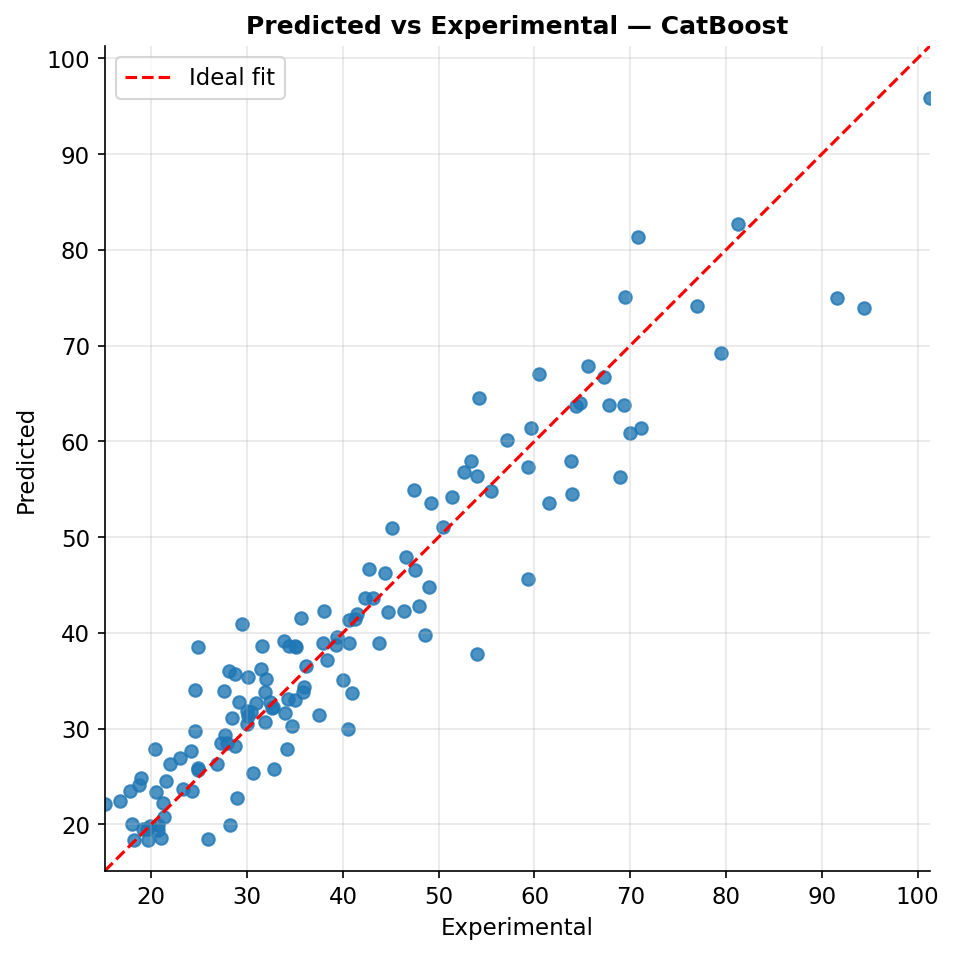

Saved: fig_11_1_predicted_vs_experimental.png

── 11.3  Residual Plot ─────────────────────────────────


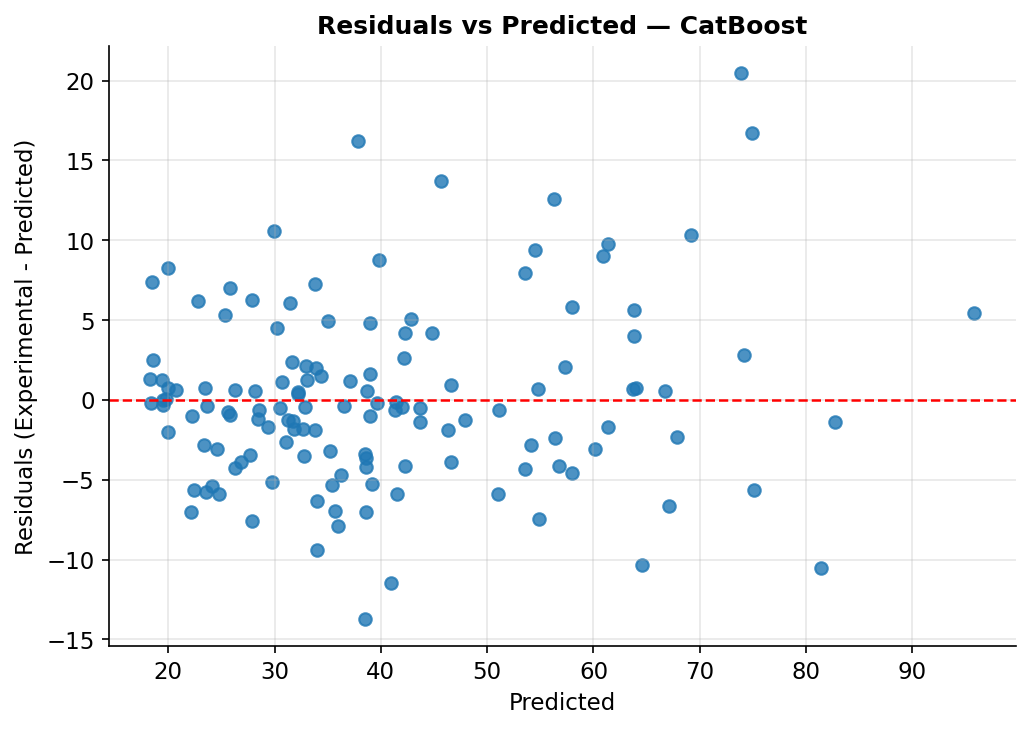

Saved: fig_11_2_residuals_vs_predicted.png

── 11.4  Residual Distribution ─────────────────────────


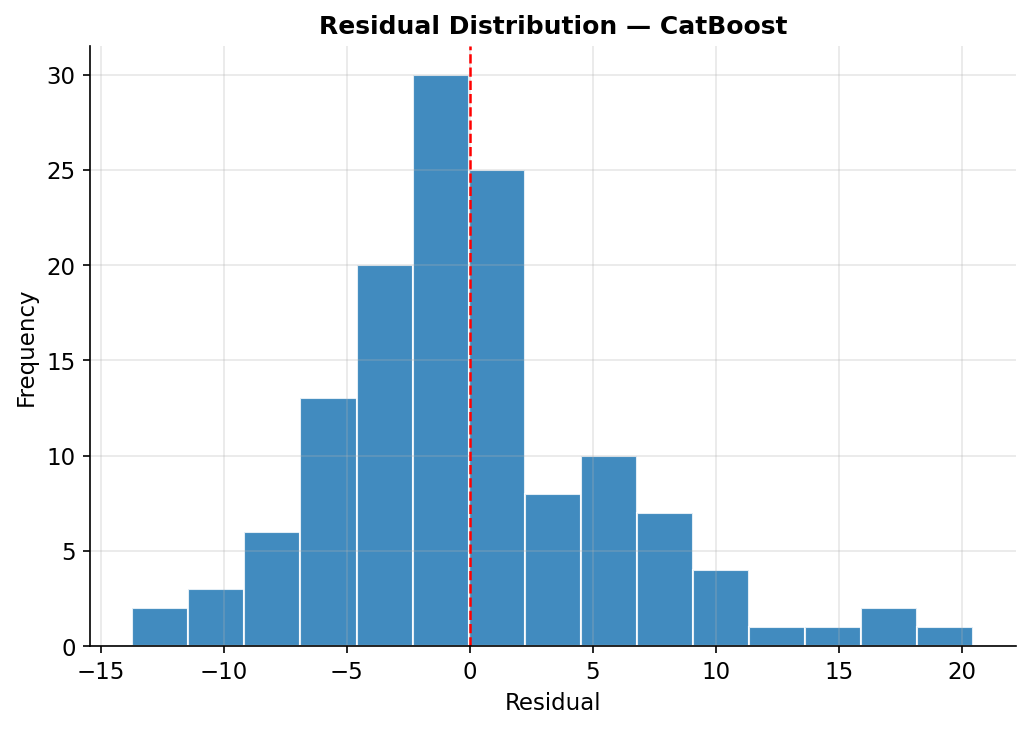

Saved: fig_11_3_residual_histogram.png

── 11.5  Q-Q Plot ──────────────────────────────────────


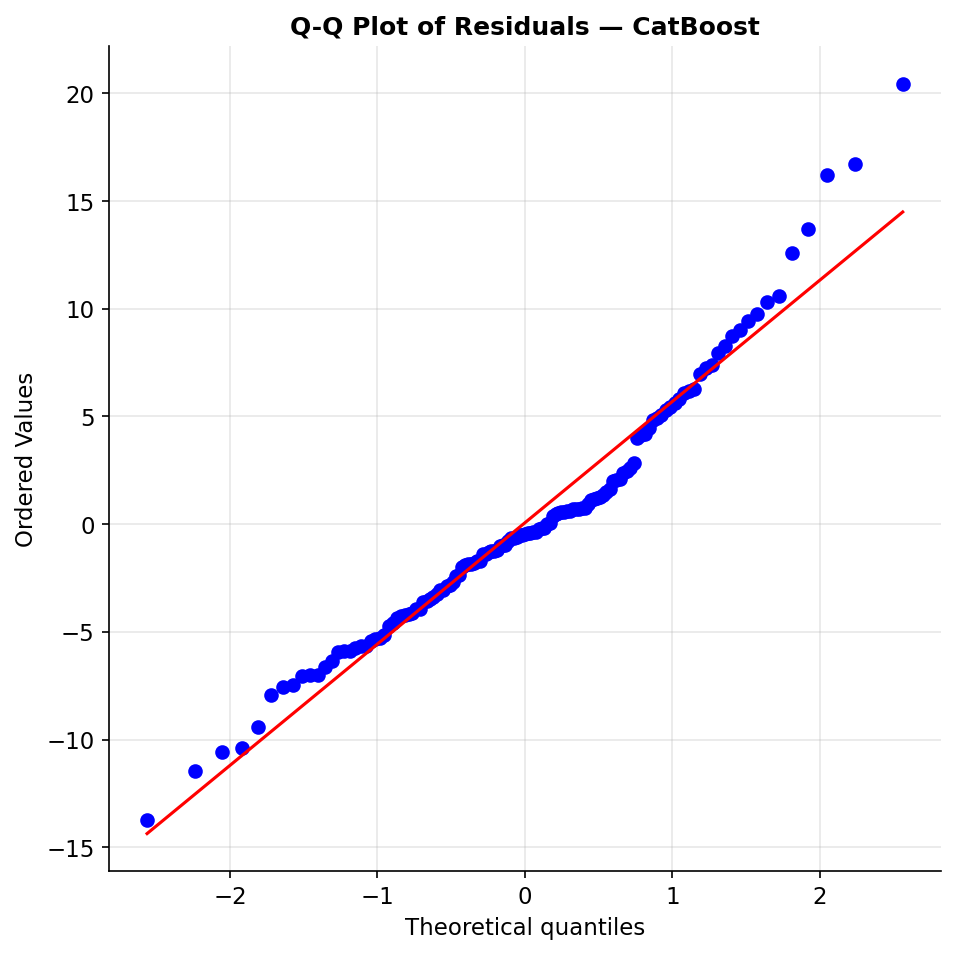

Saved: fig_11_4_qq_plot.png

── 11.6  Absolute Error Plot ───────────────────────────


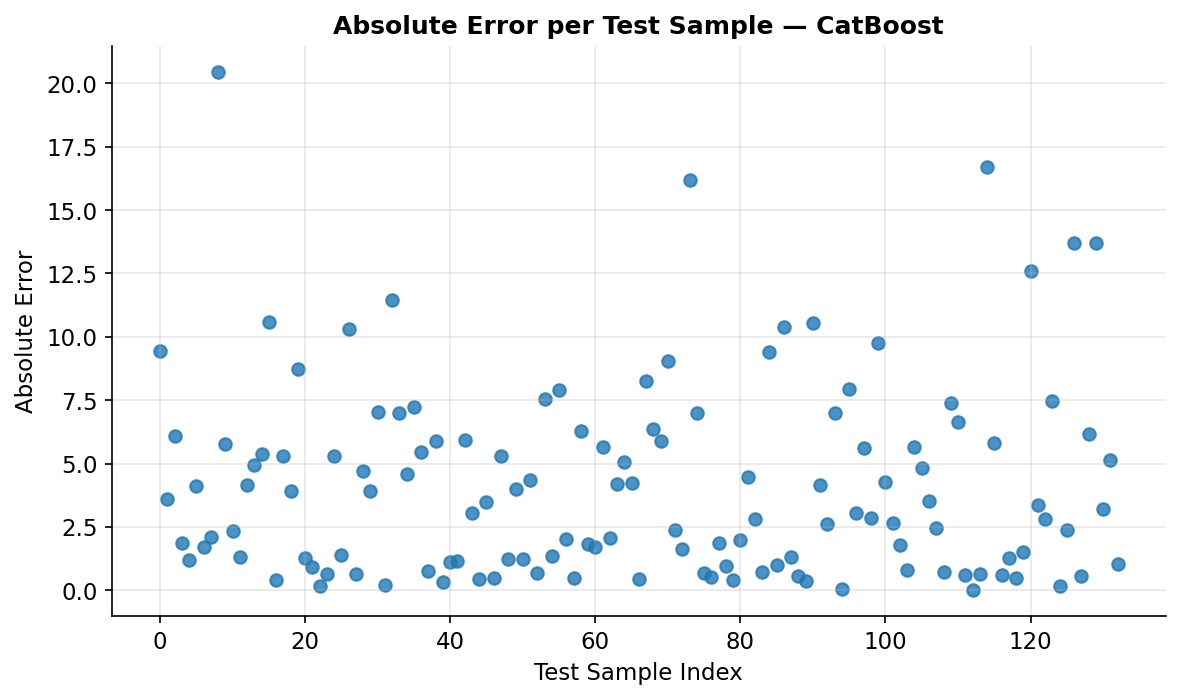

Saved: fig_11_5_absolute_error_plot.png

── 11.7  Worst Predictions ─────────────────────────────
           Experimental  Predicted  Residual  Absolute Error  Squared Error  Absolute Percentage Error (%)
Sample 1         94.370     73.917    20.453          20.453        418.333                         21.673
Sample 2         91.630     74.914    16.716          16.716        279.435                         18.243
Sample 3         54.000     37.809    16.191          16.191        262.139                         29.983
Sample 4         24.840     38.554   -13.714          13.714        188.081                         55.210
Sample 5         59.340     45.650    13.690          13.690        187.408                         23.070
Sample 6         68.920     56.319    12.601          12.601        158.785                         18.284
Sample 7         29.472     40.931   -11.459          11.459        131.306                         38.880
Sample 8         40.560     29.984    10.576  

In [14]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 11: Error Analysis
# =============================================================================
# Requires: eval_df, eval_pipelines, X_test, y_test, pred_store
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Select best model from Step 10
# ------------------------------------------------------------
best_model_name = eval_df.iloc[0]["Model"]
best_pipe = eval_pipelines[best_model_name]

# Use stored predictions if available
if "pred_store" in globals() and best_model_name in pred_store:
    y_pred = np.array(pred_store[best_model_name]["y_test_pred"])
else:
    y_pred = np.array(best_pipe.predict(X_test))

y_true = np.array(y_test)

# ------------------------------------------------------------
# Error calculations
# ------------------------------------------------------------
residuals = y_true - y_pred
abs_errors = np.abs(residuals)
sq_errors = residuals ** 2
pct_errors = np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8)) * 100

error_df = pd.DataFrame({
    "Experimental": y_true,
    "Predicted": y_pred,
    "Residual": residuals,
    "Absolute Error": abs_errors,
    "Squared Error": sq_errors,
    "Absolute Percentage Error (%)": pct_errors
})

print("── 11.1  Error Summary ─────────────────────────────────")
print(f"Best model used for error analysis : {best_model_name}")
print(f"Mean Residual                      : {residuals.mean():.4f}")
print(f"Residual Std Dev                   : {residuals.std():.4f}")
print(f"Mean Absolute Error                : {abs_errors.mean():.4f}")
print(f"Median Absolute Error              : {np.median(abs_errors):.4f}")
print(f"Max Absolute Error                 : {abs_errors.max():.4f}")
print(f"Mean Absolute Percentage Error     : {pct_errors.mean():.4f}%")

# ------------------------------------------------------------
# 11.2  Predicted vs Experimental
# ------------------------------------------------------------
print("\n── 11.2  Predicted vs Experimental ─────────────────────")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_true, y_pred, alpha=0.8)

lims = [
    min(np.min(y_true), np.min(y_pred)),
    max(np.max(y_true), np.max(y_pred))
]
ax.plot(lims, lims, "--", color="red", linewidth=1.5, label="Ideal fit")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Experimental")
ax.set_ylabel("Predicted")
ax.set_title(f"Predicted vs Experimental — {best_model_name}",
             fontsize=12, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/fig_11_1_predicted_vs_experimental.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_11_1_predicted_vs_experimental.png")

# ------------------------------------------------------------
# 11.3  Residual plot
# ------------------------------------------------------------
print("\n── 11.3  Residual Plot ─────────────────────────────────")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.8)
ax.axhline(0, linestyle="--", color="red", linewidth=1.2)
ax.set_xlabel("Predicted")
ax.set_ylabel("Residuals (Experimental - Predicted)")
ax.set_title(f"Residuals vs Predicted — {best_model_name}",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_11_2_residuals_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_11_2_residuals_vs_predicted.png")

# ------------------------------------------------------------
# 11.4  Residual distribution
# ------------------------------------------------------------
print("\n── 11.4  Residual Distribution ─────────────────────────")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=15, edgecolor="white", alpha=0.85)
ax.axvline(0, linestyle="--", color="red", linewidth=1.2)
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title(f"Residual Distribution — {best_model_name}",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_11_3_residual_histogram.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_11_3_residual_histogram.png")

# ------------------------------------------------------------
# 11.5  Q-Q plot
# ------------------------------------------------------------
print("\n── 11.5  Q-Q Plot ──────────────────────────────────────")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title(f"Q-Q Plot of Residuals — {best_model_name}",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_11_4_qq_plot.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_11_4_qq_plot.png")

# ------------------------------------------------------------
# 11.6  Absolute error plot
# ------------------------------------------------------------
print("\n── 11.6  Absolute Error Plot ───────────────────────────")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(range(len(abs_errors)), abs_errors, alpha=0.8)
ax.set_xlabel("Test Sample Index")
ax.set_ylabel("Absolute Error")
ax.set_title(f"Absolute Error per Test Sample — {best_model_name}",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_11_5_absolute_error_plot.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_11_5_absolute_error_plot.png")

# ------------------------------------------------------------
# 11.7  Worst predictions table
# ------------------------------------------------------------
print("\n── 11.7  Worst Predictions ─────────────────────────────")

worst_df = error_df.sort_values("Absolute Error", ascending=False).head(10).copy()
worst_df.index = [f"Sample {i+1}" for i in range(len(worst_df))]
print(worst_df.round(4).to_string())

# ------------------------------------------------------------
# 11.8  Normality diagnostics
# ------------------------------------------------------------
print("\n── 11.8  Residual Normality Diagnostics ────────────────")

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk statistic : {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value   : {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Residuals are approximately normal (fail to reject H0).")
else:
    print("Residuals deviate from normality (reject H0).")

# ------------------------------------------------------------
# 11.9  Interpretation
# ------------------------------------------------------------
print("\n── 11.9  Interpretation ────────────────────────────────")
print("1. Predicted vs Experimental: points closer to the 45° line indicate better predictions.")
print("2. Residual plot: random scatter around zero suggests no major systematic bias.")
print("3. Histogram + Q-Q plot: help assess whether residuals are approximately normal.")
print("4. Worst-prediction table: highlights samples where the model struggles most.")

print("\nStep 11 complete.")

── 12.1  Model selected for interpretability ───────────
Best model: CatBoost
Final estimator: CatBoostRegressor
Number of features used for interpretation: 5

── 12.2  Tree / Native Feature Importance ───────────────
            Feature  Importance
 water_binder_ratio      42.882
     fine_aggregate      24.409
   coarse_aggregate      23.191
       cement_kg_m3       6.070
rha_replacement_pct       3.448


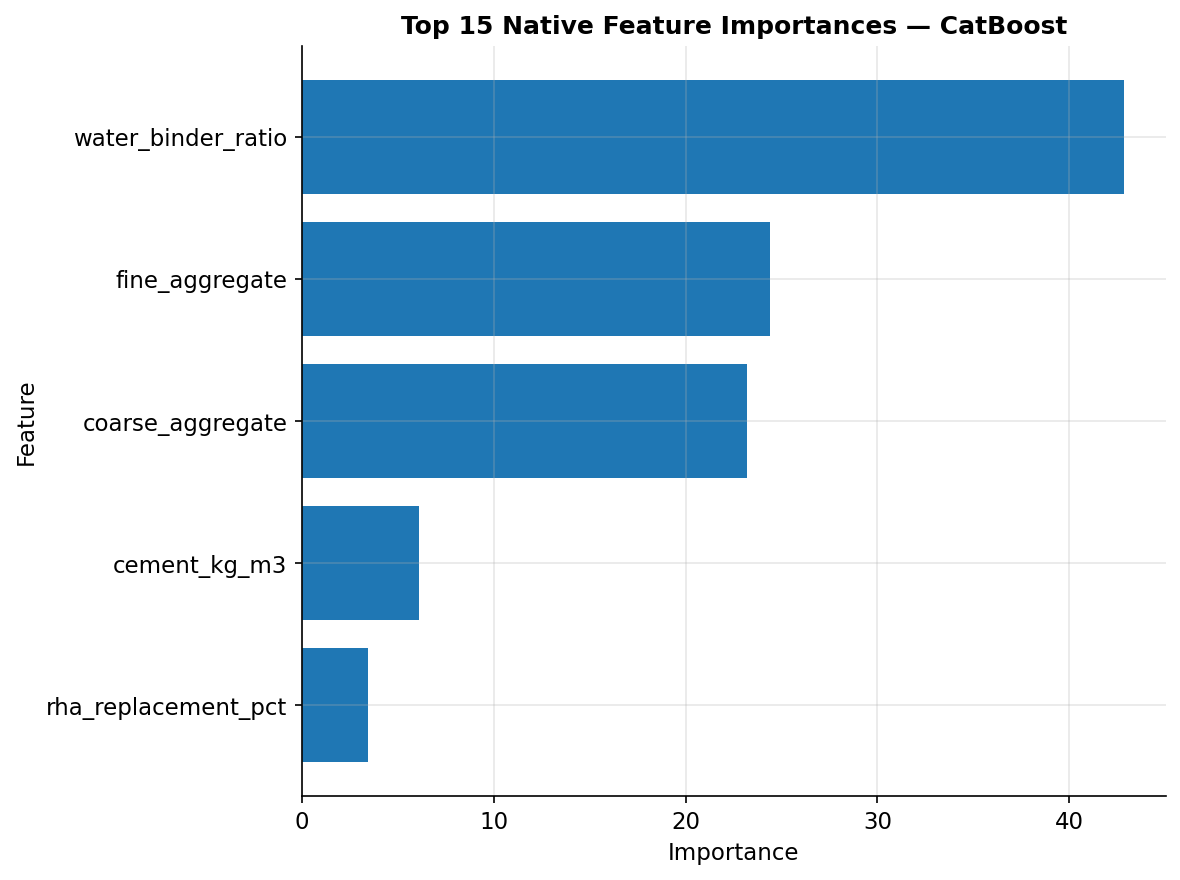

Saved: fig_12_1_native_feature_importance.png

── 12.3  Permutation Importance ─────────────────────────
            Feature  Permutation Importance Mean  Permutation Importance Std
 water_binder_ratio                        1.110                       0.103
     fine_aggregate                        0.301                       0.045
   coarse_aggregate                        0.294                       0.030
rha_replacement_pct                        0.056                       0.019
       cement_kg_m3                        0.050                       0.012


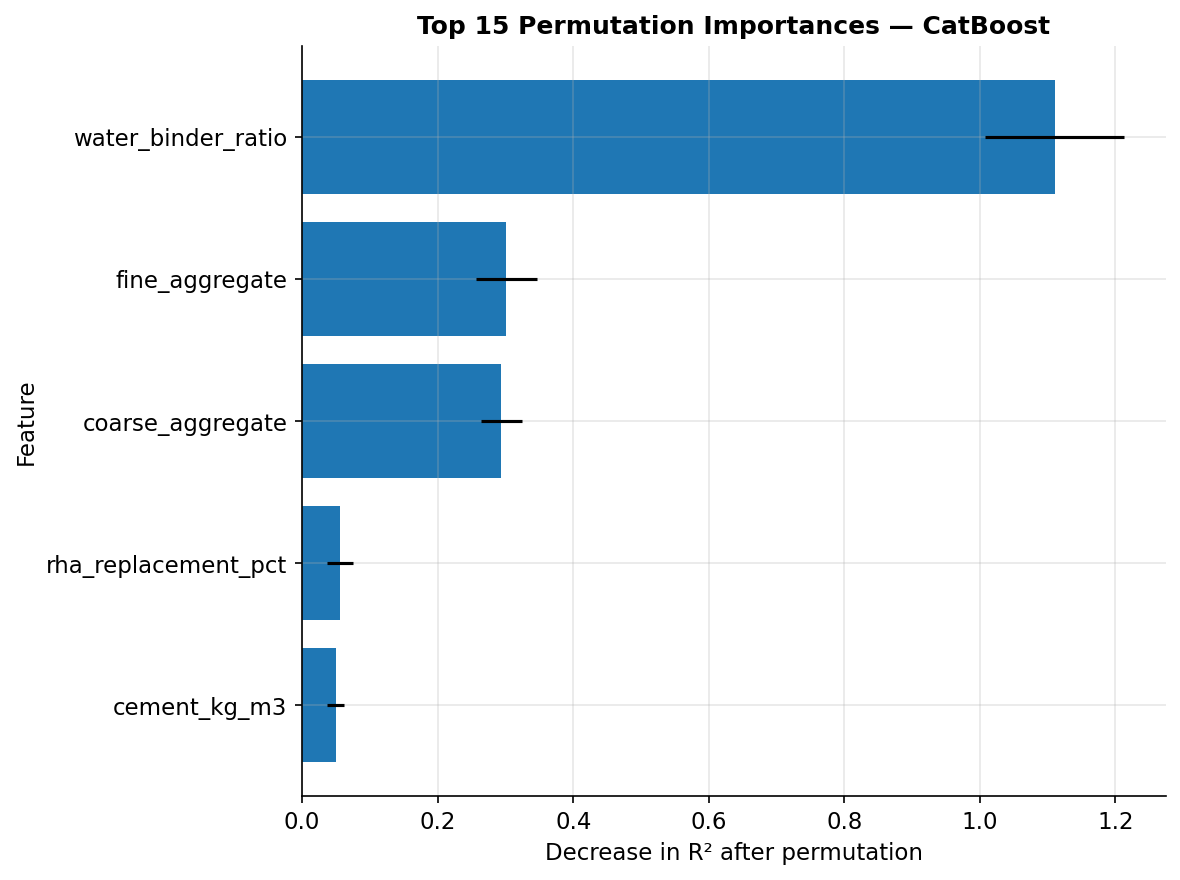

Saved: fig_12_2_permutation_importance.png

── 12.4  SHAP Analysis ─────────────────────────────────
            Feature  Mean |SHAP|
 water_binder_ratio        9.974
   coarse_aggregate        3.864
     fine_aggregate        3.125
rha_replacement_pct        1.534
       cement_kg_m3        1.455


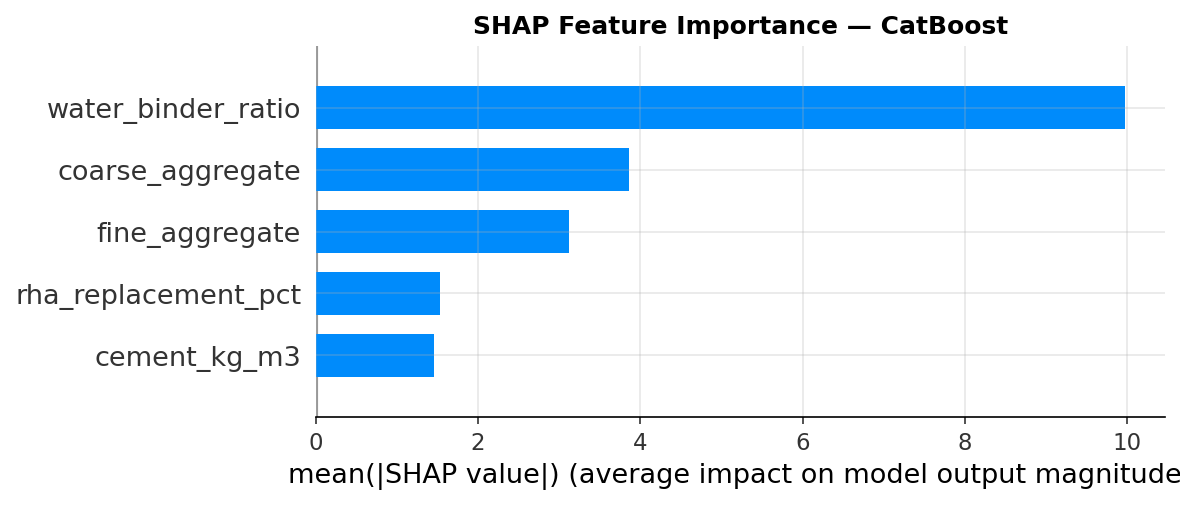

Saved: fig_12_3_shap_bar.png


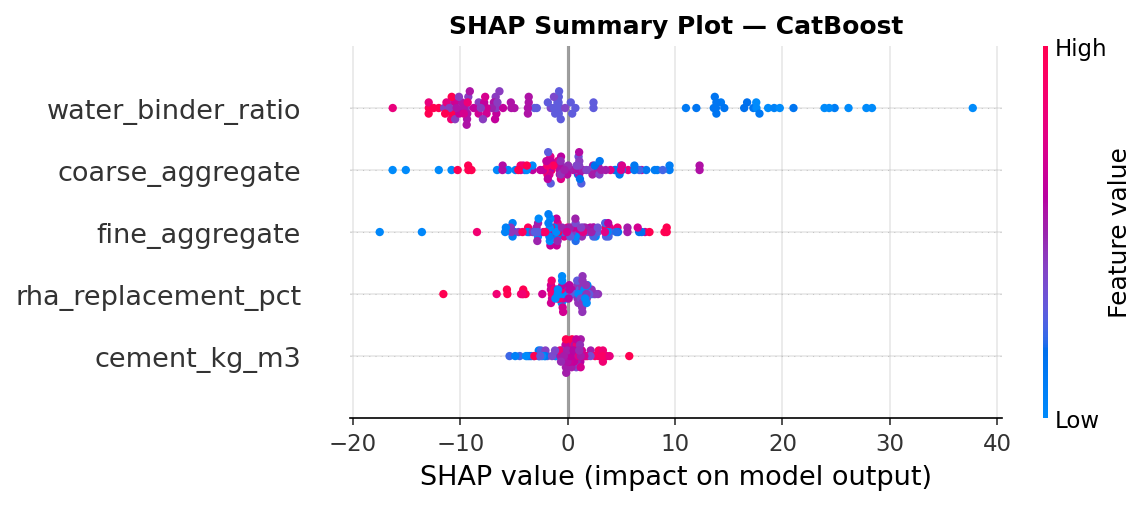

Saved: fig_12_4_shap_summary.png

── 12.5  Comparison of Importance Methods ──────────────
            Feature  Native Importance  Permutation Importance Mean  Permutation Importance Std  Mean |SHAP|
 water_binder_ratio             42.882                        1.110                       0.103        9.974
   coarse_aggregate             23.191                        0.294                       0.030        3.864
     fine_aggregate             24.409                        0.301                       0.045        3.125
rha_replacement_pct              3.448                        0.056                       0.019        1.534
       cement_kg_m3              6.070                        0.050                       0.012        1.455

── 12.6  Interpretation Summary ────────────────────────
Top 5 most influential features by SHAP: ['water_binder_ratio', 'coarse_aggregate', 'fine_aggregate', 'rha_replacement_pct', 'cement_kg_m3']

Guidance:
1. Native/tree importance shows how much the 

In [15]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 12: Model Interpretability
# =============================================================================
# Requires: eval_df, eval_pipelines, X_train, X_test, y_test
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings

from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Select best model
# ------------------------------------------------------------
best_model_name = eval_df.iloc[0]["Model"]
best_pipe = eval_pipelines[best_model_name]

print("── 12.1  Model selected for interpretability ───────────")
print(f"Best model: {best_model_name}")

# fit just to be safe
best_pipe.fit(X_train, y_train)

# ------------------------------------------------------------
# Resolve feature names
# ------------------------------------------------------------
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.tolist()
    Xtr = X_train.copy()
    Xte = X_test.copy()
else:
    feature_names = [f"Feature_{i+1}" for i in range(X_train.shape[1])]
    Xtr = pd.DataFrame(X_train, columns=feature_names)
    Xte = pd.DataFrame(X_test, columns=feature_names)

# final estimator
est_name, model = best_pipe.steps[-1]

# transformed matrix for models behind preprocessing pipeline
if len(best_pipe.steps) > 1:
    preprocessor = best_pipe[:-1]
    Xtr_trans = preprocessor.transform(Xtr)
    Xte_trans = preprocessor.transform(Xte)

    # try to recover transformed feature names
    try:
        transformed_feature_names = preprocessor.get_feature_names_out()
        transformed_feature_names = [str(f) for f in transformed_feature_names]
    except:
        transformed_feature_names = feature_names
else:
    Xtr_trans = Xtr
    Xte_trans = Xte
    transformed_feature_names = feature_names

# If transformed output is ndarray, make DataFrame for easier plotting
if not isinstance(Xtr_trans, pd.DataFrame):
    Xtr_trans_df = pd.DataFrame(Xtr_trans, columns=transformed_feature_names)
else:
    Xtr_trans_df = Xtr_trans.copy()

if not isinstance(Xte_trans, pd.DataFrame):
    Xte_trans_df = pd.DataFrame(Xte_trans, columns=transformed_feature_names)
else:
    Xte_trans_df = Xte_trans.copy()

print(f"Final estimator: {type(model).__name__}")
print(f"Number of features used for interpretation: {Xtr_trans_df.shape[1]}")

# ------------------------------------------------------------
# 12.2  Tree / model-native feature importance
# ------------------------------------------------------------
print("\n── 12.2  Tree / Native Feature Importance ───────────────")

native_importance_df = None

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    native_importance_df = (
        pd.DataFrame({
            "Feature": Xtr_trans_df.columns,
            "Importance": importances
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print(native_importance_df.head(15).round(4).to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_df = native_importance_df.head(15).iloc[::-1]
    ax.barh(plot_df["Feature"], plot_df["Importance"])
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.set_title(f"Top 15 Native Feature Importances — {best_model_name}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_12_1_native_feature_importance.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_12_1_native_feature_importance.png")
else:
    print("This model does not expose feature_importances_.")

# ------------------------------------------------------------
# 12.3  Permutation importance
# ------------------------------------------------------------
print("\n── 12.3  Permutation Importance ─────────────────────────")

perm = permutation_importance(
    best_pipe,
    Xte,
    y_test,
    scoring="r2",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Permutation Importance Mean": perm.importances_mean,
        "Permutation Importance Std": perm.importances_std
    })
    .sort_values("Permutation Importance Mean", ascending=False)
    .reset_index(drop=True)
)

print(perm_df.head(15).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = perm_df.head(15).iloc[::-1]
ax.barh(
    plot_df["Feature"],
    plot_df["Permutation Importance Mean"],
    xerr=plot_df["Permutation Importance Std"]
)
ax.set_xlabel("Decrease in R² after permutation")
ax.set_ylabel("Feature")
ax.set_title(f"Top 15 Permutation Importances — {best_model_name}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_12_2_permutation_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_12_2_permutation_importance.png")

# ------------------------------------------------------------
# 12.4  SHAP analysis
# ------------------------------------------------------------
print("\n── 12.4  SHAP Analysis ─────────────────────────────────")

# sample sizes to keep runtime manageable
max_train_shap = min(200, len(Xtr_trans_df))
max_test_shap = min(100, len(Xte_trans_df))

Xtr_shap = Xtr_trans_df.sample(max_train_shap, random_state=42) if len(Xtr_trans_df) > max_train_shap else Xtr_trans_df.copy()
Xte_shap = Xte_trans_df.sample(max_test_shap, random_state=42) if len(Xte_trans_df) > max_test_shap else Xte_trans_df.copy()

shap_values = None
shap_df = None

try:
    # TreeExplainer is fastest for tree models
    tree_model_names = [
        "RandomForestRegressor", "GradientBoostingRegressor", "ExtraTreesRegressor",
        "XGBRegressor", "LGBMRegressor", "CatBoostRegressor",
        "AdaBoostRegressor", "DecisionTreeRegressor"
    ]

    if type(model).__name__ in tree_model_names:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(Xte_shap)
    else:
        # fallback for non-tree models
        background = shap.sample(Xtr_shap, min(100, len(Xtr_shap)), random_state=42)
        explainer = shap.Explainer(model.predict, background)
        shap_values = explainer(Xte_shap)

    # standardize output
    if hasattr(shap_values, "values"):
        shap_array = shap_values.values
    else:
        shap_array = shap_values

    if len(shap_array.shape) == 3:
        shap_array = shap_array[:, :, 0]

    mean_abs_shap = np.abs(shap_array).mean(axis=0)

    shap_df = (
        pd.DataFrame({
            "Feature": Xte_shap.columns,
            "Mean |SHAP|": mean_abs_shap
        })
        .sort_values("Mean |SHAP|", ascending=False)
        .reset_index(drop=True)
    )

    print(shap_df.head(15).round(4).to_string(index=False))

    # SHAP bar summary
    fig = plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_array, Xte_shap, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance — {best_model_name}",
              fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_12_3_shap_bar.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_12_3_shap_bar.png")

    # SHAP beeswarm
    fig = plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_array, Xte_shap, show=False)
    plt.title(f"SHAP Summary Plot — {best_model_name}",
              fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_12_4_shap_summary.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_12_4_shap_summary.png")

except Exception as e:
    print(f"SHAP analysis could not be completed: {e}")

# ------------------------------------------------------------
# 12.5  Compare importance methods
# ------------------------------------------------------------
print("\n── 12.5  Comparison of Importance Methods ──────────────")

comparison_df = None

if native_importance_df is not None and shap_df is not None:
    comparison_df = (
        native_importance_df.rename(columns={"Importance": "Native Importance"})
        .merge(perm_df, on="Feature", how="outer")
        .merge(shap_df, on="Feature", how="outer")
        .fillna(0)
    )
elif shap_df is not None:
    comparison_df = (
        perm_df.merge(shap_df, on="Feature", how="outer").fillna(0)
    )
else:
    comparison_df = perm_df.copy()

sort_col = "Mean |SHAP|" if "Mean |SHAP|" in comparison_df.columns else "Permutation Importance Mean"
comparison_df = comparison_df.sort_values(sort_col, ascending=False).reset_index(drop=True)

print(comparison_df.head(20).round(4).to_string(index=False))

# ------------------------------------------------------------
# 12.6  Top features summary
# ------------------------------------------------------------
print("\n── 12.6  Interpretation Summary ────────────────────────")

if shap_df is not None:
    top_feats = shap_df.head(5)["Feature"].tolist()
    print(f"Top 5 most influential features by SHAP: {top_feats}")
elif native_importance_df is not None:
    top_feats = native_importance_df.head(5)["Feature"].tolist()
    print(f"Top 5 most influential features by native importance: {top_feats}")
else:
    top_feats = perm_df.head(5)["Feature"].tolist()
    print(f"Top 5 most influential features by permutation importance: {top_feats}")

print("\nGuidance:")
print("1. Native/tree importance shows how much the model used each feature internally.")
print("2. Permutation importance shows how much test performance drops when a feature is shuffled.")
print("3. SHAP explains both magnitude and direction of each feature’s contribution.")
print("4. Features consistently ranked high across all methods are the most trustworthy drivers.")

print("\nStep 12 complete.")

── 13.1  Models selected ───────────────────────────────
Best model for detailed analysis : CatBoost
Top models for Taylor diagram    : ['CatBoost', 'CatBoost (Optuna)', 'XGBoost (Optuna)', 'XGBoost', 'LightGBM']

── 13.2  Taylor Diagram ────────────────────────────────
            Model  Predicted Std  Correlation  CRMSE
         CatBoost         16.237        0.950  5.657
 XGBoost (Optuna)         15.709        0.949  5.781
CatBoost (Optuna)         15.828        0.949  5.769
          XGBoost         15.246        0.943  6.192
         LightGBM         15.665        0.937  6.344


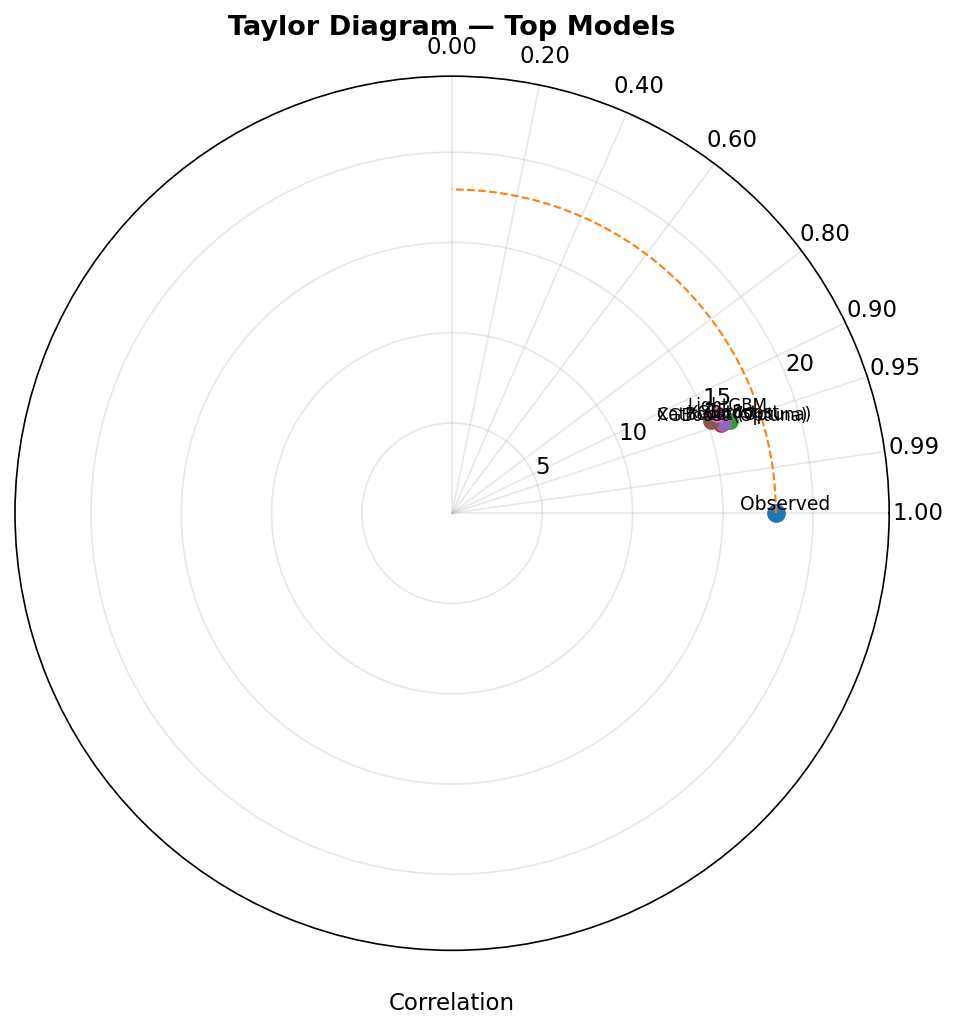

Saved: fig_13_1_taylor_diagram.png

── 13.3  Partial Dependence Plots (PDP) ────────────────
Features used for PDP: ['water_binder_ratio', 'fine_aggregate', 'coarse_aggregate', 'rha_replacement_pct']


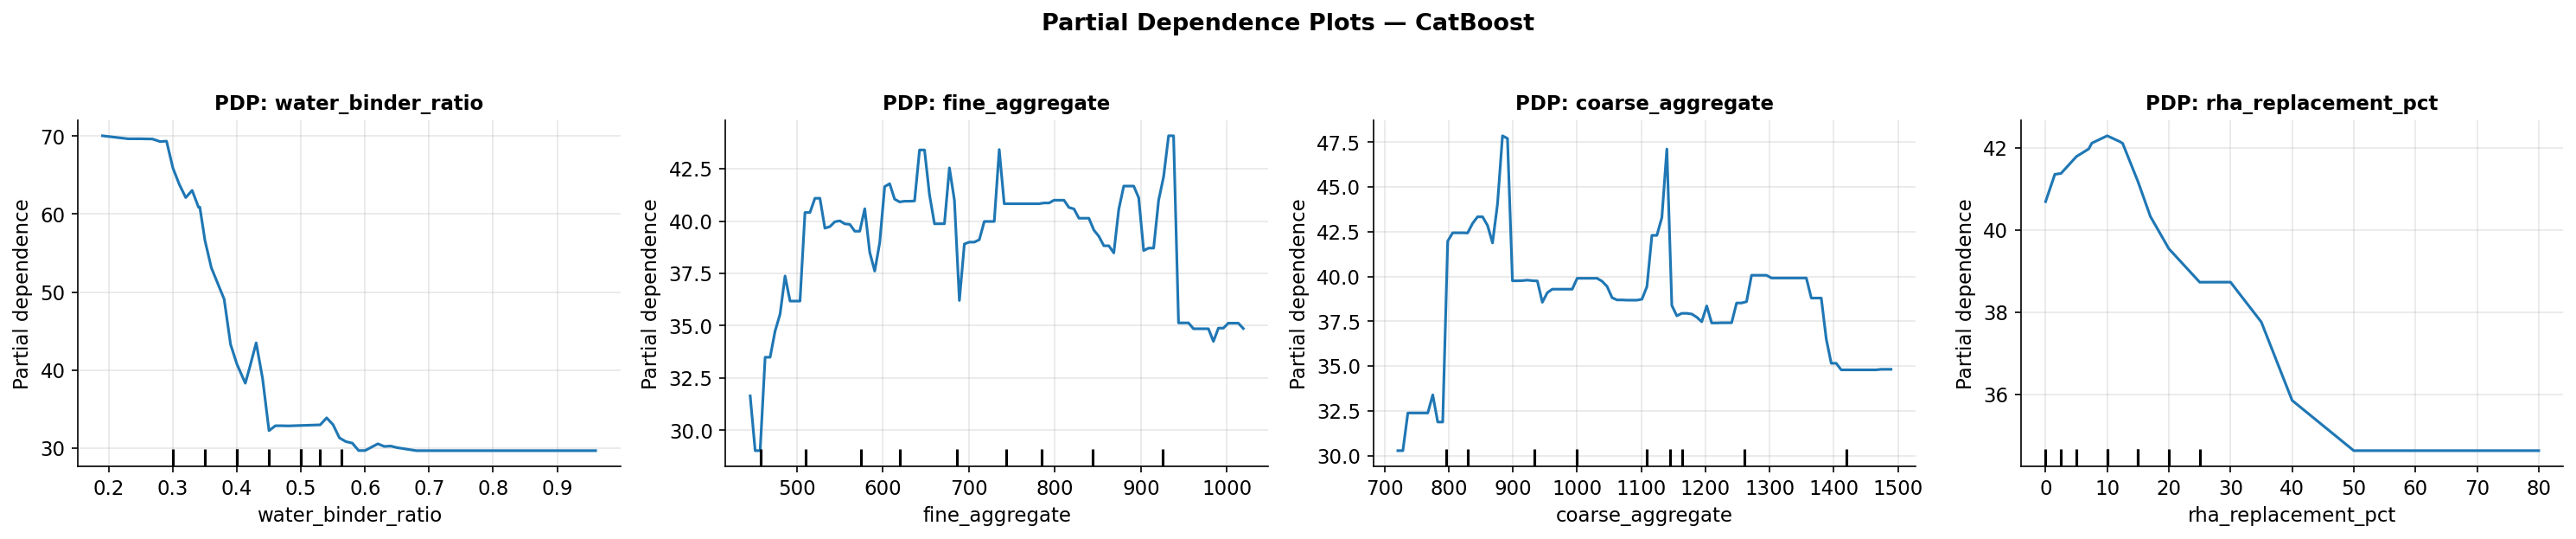

Saved: fig_13_2_pdp.png

── 13.4  Learning Curves ───────────────────────────────


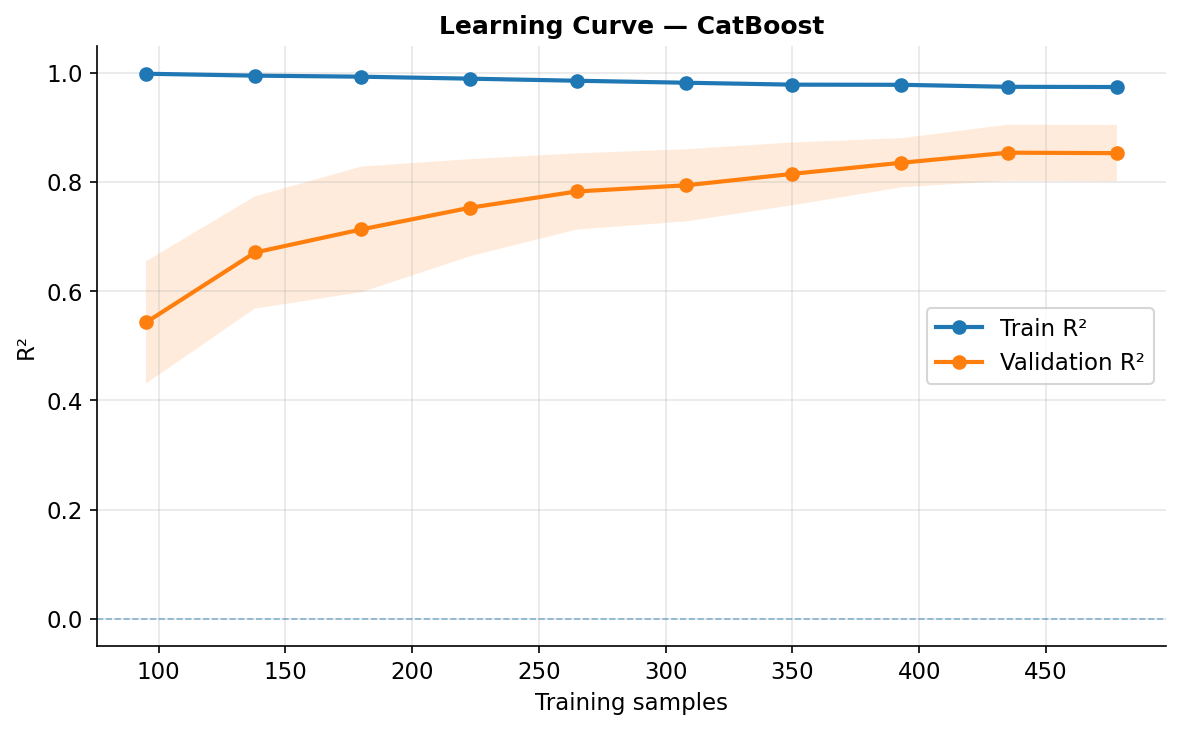

Saved: fig_13_3_learning_curve_best.png

── 13.5  Sensitivity Analysis ──────────────────────────
Sensitivity features: ['water_binder_ratio', 'fine_aggregate', 'coarse_aggregate']


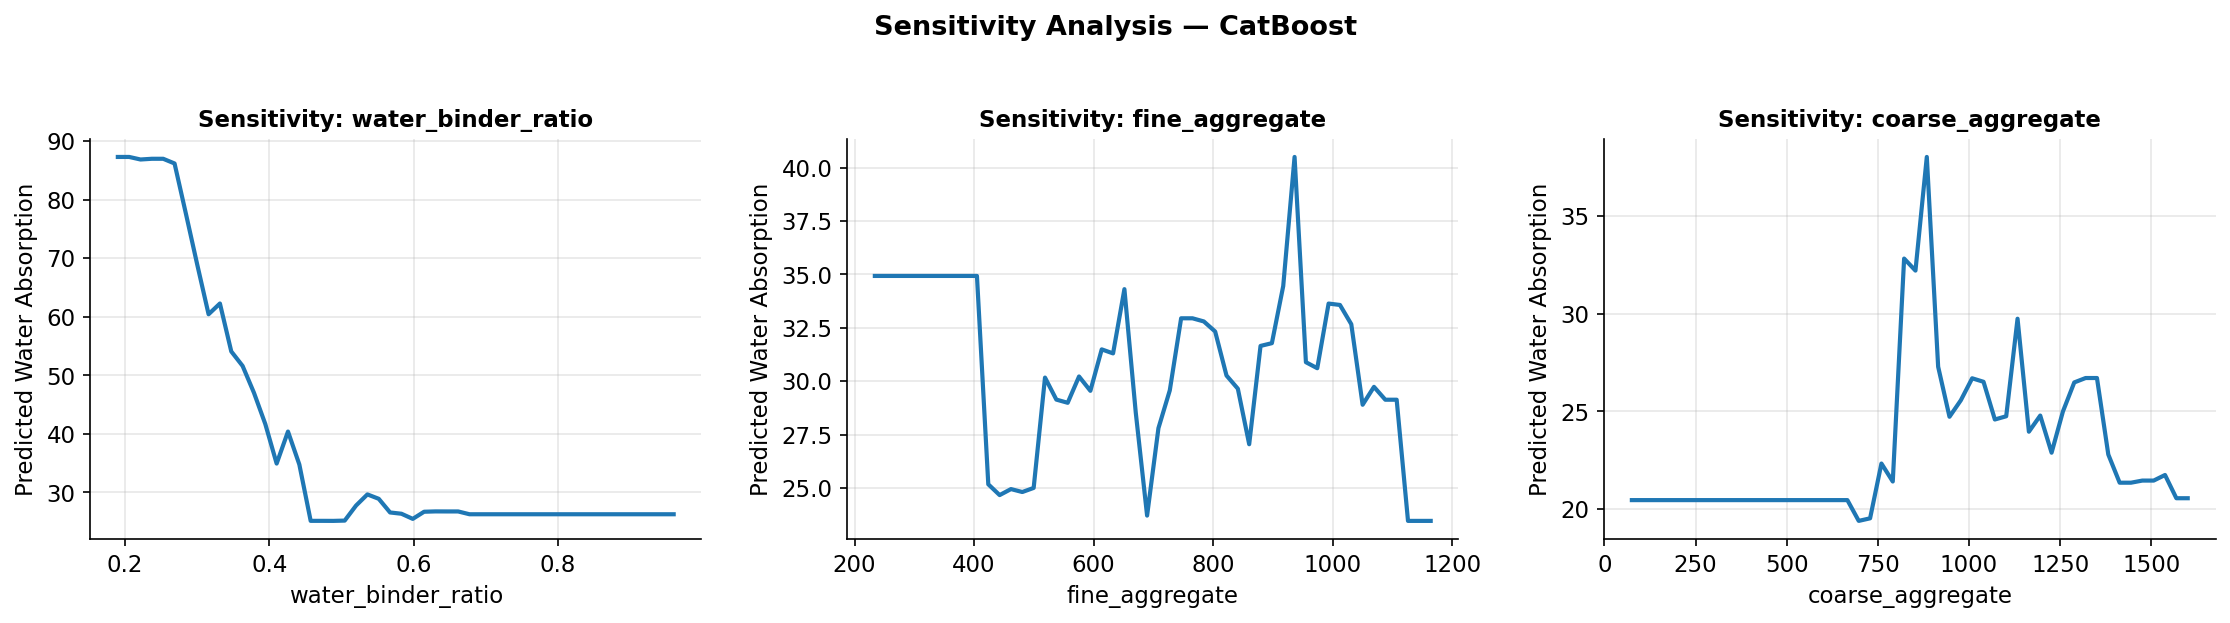

Saved: fig_13_4_sensitivity_analysis.png

Sensitivity summary:
           Feature  Min Prediction  Max Prediction  Prediction Range  Feature Min  Feature Max
water_binder_ratio          25.122          87.308            62.187        0.190        0.960
  coarse_aggregate          19.403          38.023            18.620       75.467     1600.000
    fine_aggregate          23.455          40.506            17.051      234.000     1164.000

── 13.6  Interpretation Summary ───────────────────────
Taylor diagram:
- Better models are closer to the observed reference point.
- Higher correlation and similar standard deviation indicate better agreement.

PDP:
- Shows the average marginal effect of a feature on predicted water absorption.
- Nonlinear shapes suggest threshold or diminishing-return effects.

Learning curve:
- Small train-validation gap suggests good generalisation.
- A low plateau suggests underfitting; a large persistent gap suggests overfitting.

Sensitivity analysis:
- Featur

In [16]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 13: Advanced Analysis
# =============================================================================
# Requires: eval_df, eval_pipelines, X_train, y_train, X_test, y_test
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import learning_curve, KFold
from sklearn.base import clone

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Select best model and top models
# ------------------------------------------------------------
best_model_name = eval_df.iloc[0]["Model"]
best_pipe = eval_pipelines[best_model_name]

top_n_taylor = min(5, len(eval_df))
top_models = eval_df.head(top_n_taylor)["Model"].tolist()

print("── 13.1  Models selected ───────────────────────────────")
print(f"Best model for detailed analysis : {best_model_name}")
print(f"Top models for Taylor diagram    : {top_models}")

# ensure fitted
best_pipe.fit(X_train, y_train)

# ------------------------------------------------------------
# Resolve feature names and dataframe versions
# ------------------------------------------------------------
if isinstance(X_train, pd.DataFrame):
    Xtr = X_train.copy()
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"Feature_{i+1}" for i in range(X_train.shape[1])]
    Xtr = pd.DataFrame(X_train, columns=feature_names)

if isinstance(X_test, pd.DataFrame):
    Xte = X_test.copy()
else:
    Xte = pd.DataFrame(X_test, columns=feature_names)

if isinstance(y_test, pd.Series):
    y_true = y_test.to_numpy()
else:
    y_true = np.array(y_test)

# ------------------------------------------------------------
# Helper metrics for Taylor diagram
# ------------------------------------------------------------
def taylor_stats(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    std_ref = np.std(y_true, ddof=1)
    std_pred = np.std(y_pred, ddof=1)

    if std_ref == 0 or std_pred == 0:
        corr = 0.0
    else:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
        corr = np.clip(corr, -1, 1)

    crmsd = np.sqrt(np.mean(((y_pred - np.mean(y_pred)) - (y_true - np.mean(y_true))) ** 2))
    return std_ref, std_pred, corr, crmsd

# ------------------------------------------------------------
# 13.2  Taylor diagram
# ------------------------------------------------------------
print("\n── 13.2  Taylor Diagram ────────────────────────────────")

taylor_rows = []

for name in top_models:
    pipe = eval_pipelines[name]
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    std_ref, std_pred, corr, crmsd = taylor_stats(y_true, y_pred)
    theta = np.arccos(np.clip(corr, -1, 1))

    taylor_rows.append({
        "Model": name,
        "Reference Std": std_ref,
        "Predicted Std": std_pred,
        "Correlation": corr,
        "CRMSE": crmsd,
        "Theta": theta
    })

taylor_df = pd.DataFrame(taylor_rows).sort_values("Correlation", ascending=False)
print(taylor_df[["Model", "Predicted Std", "Correlation", "CRMSE"]].round(4).to_string(index=False))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, polar=True)

# correlation grid
corr_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
theta_ticks = np.arccos(np.clip(corr_ticks, -1, 1))
ax.set_thetagrids(np.degrees(theta_ticks), labels=[f"{c:.2f}" for c in corr_ticks])

std_ref = taylor_df["Reference Std"].iloc[0]
rmax = max(taylor_df["Predicted Std"].max(), std_ref) * 1.35
ax.set_rlim(0, rmax)

# reference point
ax.plot(0, std_ref, "o", markersize=8, label="Reference (Observed)")
ax.text(0, std_ref * 1.03, "Observed", ha="center", va="bottom", fontsize=9)

# optional std reference arc
theta_line = np.linspace(0, np.pi/2, 300)
ax.plot(theta_line, np.full_like(theta_line, std_ref), linestyle="--", linewidth=1)

# model points
for _, row in taylor_df.iterrows():
    ax.plot(row["Theta"], row["Predicted Std"], "o", markersize=7, label=row["Model"])
    ax.text(row["Theta"], row["Predicted Std"] * 1.04, row["Model"], fontsize=8, ha="center")

ax.set_title("Taylor Diagram — Top Models", fontsize=13, fontweight="bold", pad=20)
ax.set_xlabel("Correlation", labelpad=20)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_13_1_taylor_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_13_1_taylor_diagram.png")

# ------------------------------------------------------------
# 13.3  PDP (Partial Dependence Plots)
# ------------------------------------------------------------
print("\n── 13.3  Partial Dependence Plots (PDP) ────────────────")

# choose top numeric features from permutation importance if available
top_features = None
if "perm_df" in globals():
    top_features = perm_df["Feature"].head(min(4, len(perm_df))).tolist()
else:
    top_features = feature_names[:min(4, len(feature_names))]

valid_pdp_features = [f for f in top_features if f in Xtr.columns]

print(f"Features used for PDP: {valid_pdp_features}")

if len(valid_pdp_features) > 0:
    n_feats = len(valid_pdp_features)
    fig, axes = plt.subplots(1, n_feats, figsize=(5 * n_feats, 4))
    if n_feats == 1:
        axes = [axes]

    for ax, feat in zip(axes, valid_pdp_features):
        PartialDependenceDisplay.from_estimator(
            best_pipe,
            Xtr,
            [feat],
            ax=ax,
            kind="average"
        )
        ax.set_title(f"PDP: {feat}", fontsize=11, fontweight="bold")

    plt.suptitle(f"Partial Dependence Plots — {best_model_name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_13_2_pdp.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_13_2_pdp.png")
else:
    print("No valid original feature names available for PDP.")

# ------------------------------------------------------------
# 13.4  Learning curves
# ------------------------------------------------------------
print("\n── 13.4  Learning Curves ───────────────────────────────")

kf = KFold(n_splits=10, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    clone(best_pipe),
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 10),
    n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, "o-", linewidth=2, label="Train R²")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)

ax.plot(train_sizes, val_mean, "o-", linewidth=2, label="Validation R²")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

ax.set_xlabel("Training samples")
ax.set_ylabel("R²")
ax.set_title(f"Learning Curve — {best_model_name}", fontsize=12, fontweight="bold")
ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/fig_13_3_learning_curve_best.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_13_3_learning_curve_best.png")

# ------------------------------------------------------------
# 13.5  Sensitivity analysis
# ------------------------------------------------------------
print("\n── 13.5  Sensitivity Analysis ──────────────────────────")

# use top features from permutation importance if available
if "perm_df" in globals():
    sens_features = perm_df["Feature"].head(min(3, len(perm_df))).tolist()
else:
    sens_features = feature_names[:min(3, len(feature_names))]

sens_features = [f for f in sens_features if f in Xtr.columns]
print(f"Sensitivity features: {sens_features}")

baseline = Xtr.median(numeric_only=True)

sensitivity_rows = []

if len(sens_features) > 0:
    fig, axes = plt.subplots(1, len(sens_features), figsize=(5 * len(sens_features), 4))
    if len(sens_features) == 1:
        axes = [axes]

    for ax, feat in zip(axes, sens_features):
        # build a single-row baseline input
        row = baseline.copy()

        # if any missing columns due to non-numeric handling, use actual medians where possible
        for col in Xtr.columns:
            if col not in row.index:
                try:
                    row[col] = Xtr[col].mode().iloc[0]
                except:
                    row[col] = Xtr.iloc[0][col]

        row = row[Xtr.columns]

        feat_vals = np.linspace(Xtr[feat].min(), Xtr[feat].max(), 50)
        preds = []

        for v in feat_vals:
            test_row = row.copy()
            test_row[feat] = v
            test_df = pd.DataFrame([test_row], columns=Xtr.columns)
            pred = best_pipe.predict(test_df)[0]
            preds.append(pred)

        preds = np.array(preds)

        ax.plot(feat_vals, preds, linewidth=2)
        ax.set_xlabel(feat)
        ax.set_ylabel("Predicted Water Absorption")
        ax.set_title(f"Sensitivity: {feat}", fontsize=11, fontweight="bold")

        sensitivity_rows.append({
            "Feature": feat,
            "Min Prediction": float(np.min(preds)),
            "Max Prediction": float(np.max(preds)),
            "Prediction Range": float(np.max(preds) - np.min(preds)),
            "Feature Min": float(np.min(feat_vals)),
            "Feature Max": float(np.max(feat_vals)),
        })

    plt.suptitle(f"Sensitivity Analysis — {best_model_name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_13_4_sensitivity_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_13_4_sensitivity_analysis.png")

    sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values("Prediction Range", ascending=False)
    print("\nSensitivity summary:")
    print(sensitivity_df.round(4).to_string(index=False))
else:
    sensitivity_df = pd.DataFrame()
    print("No valid features available for sensitivity analysis.")

# ------------------------------------------------------------
# 13.6  Interpretation summary
# ------------------------------------------------------------
print("\n── 13.6  Interpretation Summary ───────────────────────")

print("Taylor diagram:")
print("- Better models are closer to the observed reference point.")
print("- Higher correlation and similar standard deviation indicate better agreement.")

print("\nPDP:")
print("- Shows the average marginal effect of a feature on predicted water absorption.")
print("- Nonlinear shapes suggest threshold or diminishing-return effects.")

print("\nLearning curve:")
print("- Small train-validation gap suggests good generalisation.")
print("- A low plateau suggests underfitting; a large persistent gap suggests overfitting.")

print("\nSensitivity analysis:")
print("- Features with larger prediction ranges have stronger influence on model output.")
print("- Trends show whether increasing a feature raises or lowers predicted absorption.")

print("\nStep 13 complete.")

── 14.1  Best Model ───────────────────────────────────
Best model: CatBoost

── 14.2  95% Confidence Interval ─────────────────────
Mean error          : 0.0667
Std of error        : 5.6779
95% CI of error     : [-11.0619, 11.1953]

── 14.3  Bootstrap Uncertainty ───────────────────────
 Experimental  Predicted Mean  Prediction Std (Uncertainty)
       24.610          36.173                         6.081
       35.000          40.215                         3.831
       37.520          31.701                         1.730
       31.920          34.291                         1.345
       27.304          28.690                         1.586

Average prediction uncertainty (std): 3.0040


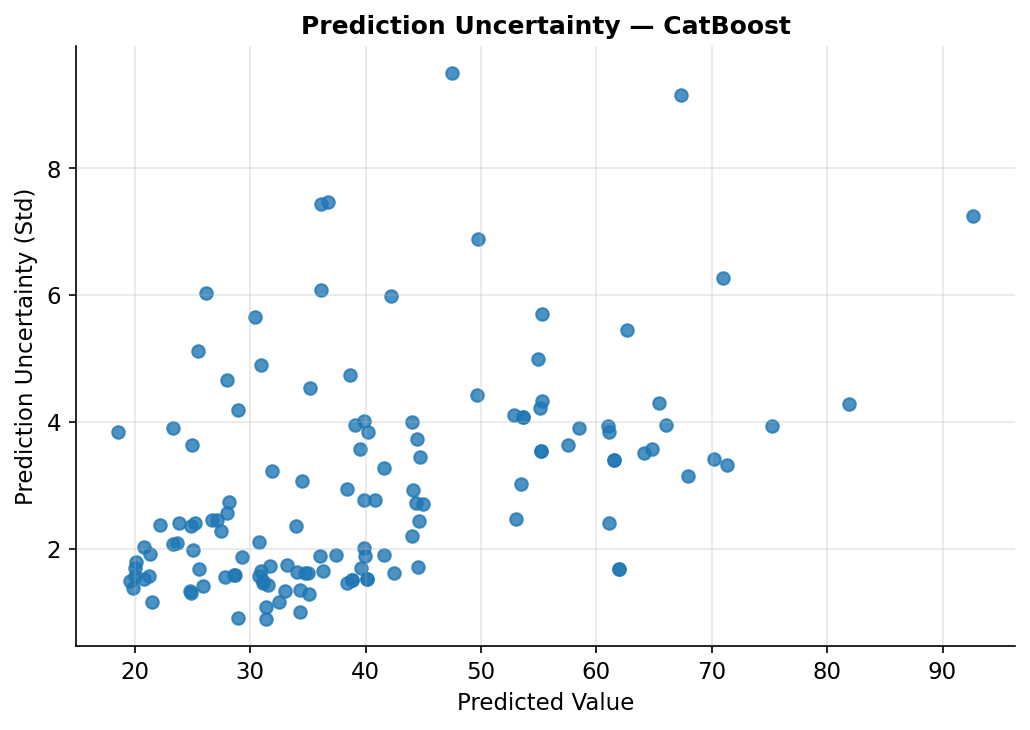

Saved: fig_14_1_uncertainty.png

── 14.4  AIC / BIC Comparison ─────────────────────────
            Model     AIC     BIC
         CatBoost 470.943 485.395
CatBoost (Optuna) 476.189 490.640
 XGBoost (Optuna) 476.795 491.247
          XGBoost 495.001 509.452
         LightGBM 501.731 516.183
Gradient Boosting 508.632 523.084
    Random Forest 573.729 588.181
      Extra Trees 609.141 623.593
         AdaBoost 652.084 666.536


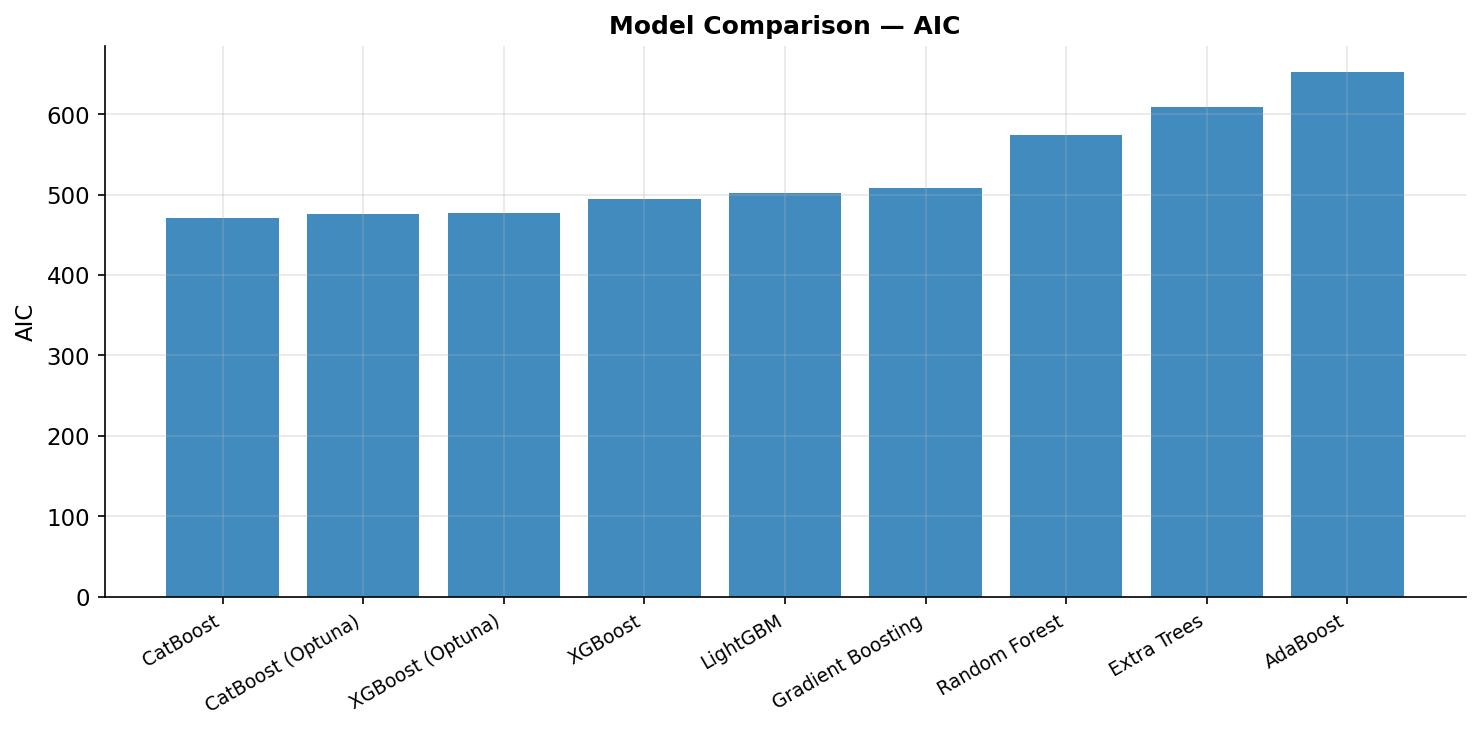

Saved: fig_14_2_aic_comparison.png

── 14.5  Statistical Summary ─────────────────────────
Best model (AIC)        : CatBoost
Best model (CV/Test)    : CatBoost

Interpretation:
- 95% CI shows error reliability range.
- Bootstrap captures prediction uncertainty.
- Lower AIC/BIC → better fit with lower complexity.

Step 14 complete.


In [17]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 14: Statistical Validation
# =============================================================================
# Requires: eval_df, eval_pipelines, X_train, y_train, X_test, y_test
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def calc_aic_bic(y_true, y_pred, k):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    rss = max(rss, 1e-12)
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return aic, bic

# ------------------------------------------------------------
# Select best model
# ------------------------------------------------------------
best_model_name = eval_df.iloc[0]["Model"]
best_pipe = eval_pipelines[best_model_name]

print("── 14.1  Best Model ───────────────────────────────────")
print(f"Best model: {best_model_name}")

# ensure fitted
best_pipe.fit(X_train, y_train)

y_true = np.array(y_test)
y_pred = np.array(best_pipe.predict(X_test))

# ------------------------------------------------------------
# 14.2  95% Confidence Interval (Prediction Error)
# ------------------------------------------------------------
print("\n── 14.2  95% Confidence Interval ─────────────────────")

errors = y_true - y_pred

mean_error = np.mean(errors)
std_error  = np.std(errors, ddof=1)

ci_lower = mean_error - 1.96 * std_error
ci_upper = mean_error + 1.96 * std_error

print(f"Mean error          : {mean_error:.4f}")
print(f"Std of error        : {std_error:.4f}")
print(f"95% CI of error     : [{ci_lower:.4f}, {ci_upper:.4f}]")

# ------------------------------------------------------------
# 14.3  Bootstrap uncertainty (prediction distribution)
# ------------------------------------------------------------
print("\n── 14.3  Bootstrap Uncertainty ───────────────────────")

n_boot = 100
boot_preds = []

for i in range(n_boot):
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)

    X_boot = X_train.iloc[idx] if isinstance(X_train, pd.DataFrame) else X_train[idx]
    y_boot = y_train.iloc[idx] if isinstance(y_train, pd.Series) else y_train[idx]

    model_boot = clone(best_pipe)
    model_boot.fit(X_boot, y_boot)

    preds = model_boot.predict(X_test)
    boot_preds.append(preds)

boot_preds = np.array(boot_preds)

# uncertainty metrics
pred_mean = boot_preds.mean(axis=0)
pred_std  = boot_preds.std(axis=0)

uncertainty_df = pd.DataFrame({
    "Experimental": y_true,
    "Predicted Mean": pred_mean,
    "Prediction Std (Uncertainty)": pred_std
})

print(uncertainty_df.head().round(4).to_string(index=False))

print(f"\nAverage prediction uncertainty (std): {pred_std.mean():.4f}")

# ------------------------------------------------------------
# Plot uncertainty
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pred_mean, pred_std, alpha=0.8)
ax.set_xlabel("Predicted Value")
ax.set_ylabel("Prediction Uncertainty (Std)")
ax.set_title(f"Prediction Uncertainty — {best_model_name}",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_14_1_uncertainty.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_14_1_uncertainty.png")

# ------------------------------------------------------------
# 14.4  AIC/BIC comparison across models
# ------------------------------------------------------------
print("\n── 14.4  AIC / BIC Comparison ─────────────────────────")

aic_rows = []

for name, pipe in eval_pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    k = X_test.shape[1]  # approximation
    aic, bic = calc_aic_bic(y_true, y_pred, k)

    aic_rows.append({
        "Model": name,
        "AIC": aic,
        "BIC": bic
    })

aic_df = pd.DataFrame(aic_rows).sort_values("AIC")

print(aic_df.round(4).to_string(index=False))

# ------------------------------------------------------------
# Plot AIC comparison
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(aic_df))

ax.bar(x, aic_df["AIC"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(aic_df["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("AIC")
ax.set_title("Model Comparison — AIC", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig_14_2_aic_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_14_2_aic_comparison.png")

# ------------------------------------------------------------
# 14.5  Summary
# ------------------------------------------------------------
print("\n── 14.5  Statistical Summary ─────────────────────────")

best_aic_model = aic_df.iloc[0]["Model"]

print(f"Best model (AIC)        : {best_aic_model}")
print(f"Best model (CV/Test)    : {best_model_name}")
print("\nInterpretation:")
print("- 95% CI shows error reliability range.")
print("- Bootstrap captures prediction uncertainty.")
print("- Lower AIC/BIC → better fit with lower complexity.")

print("\nStep 14 complete.")

── 15.1  Publication Plots ─────────────────────────────
Best model used: CatBoost


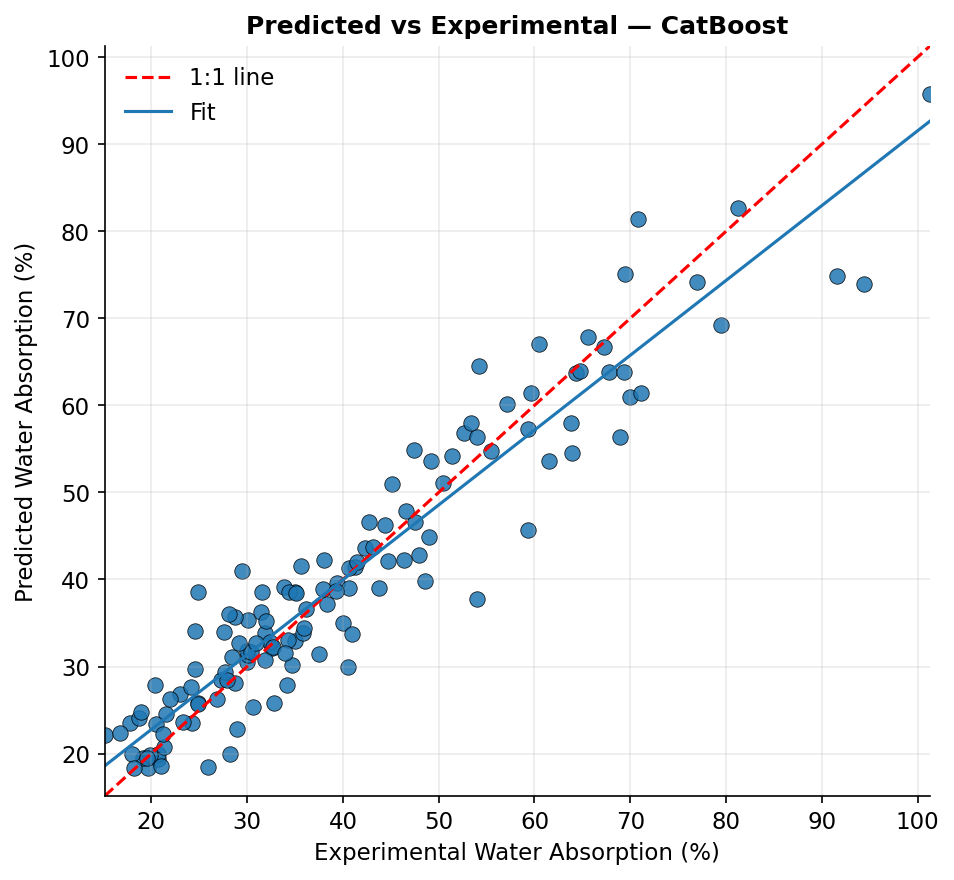

Saved: fig_15_1_predicted_vs_experimental_publication.png


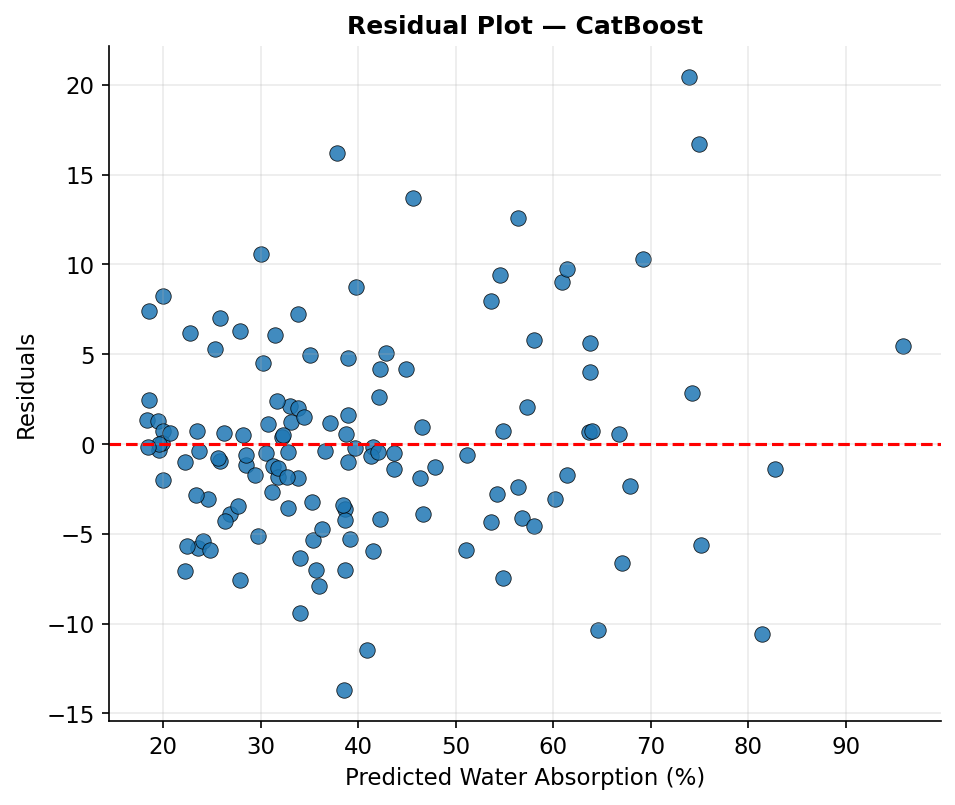

Saved: fig_15_2_residual_plot_publication.png


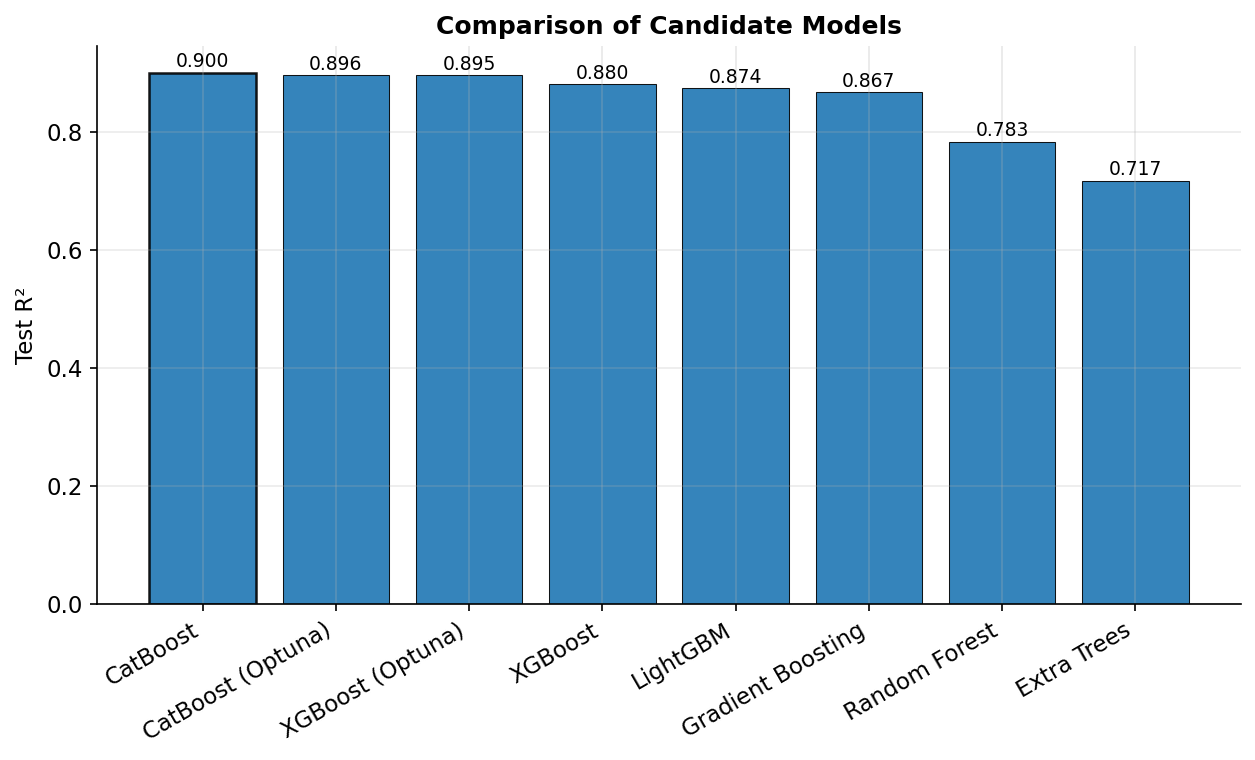

Saved: fig_15_3_model_comparison_test_r2.png


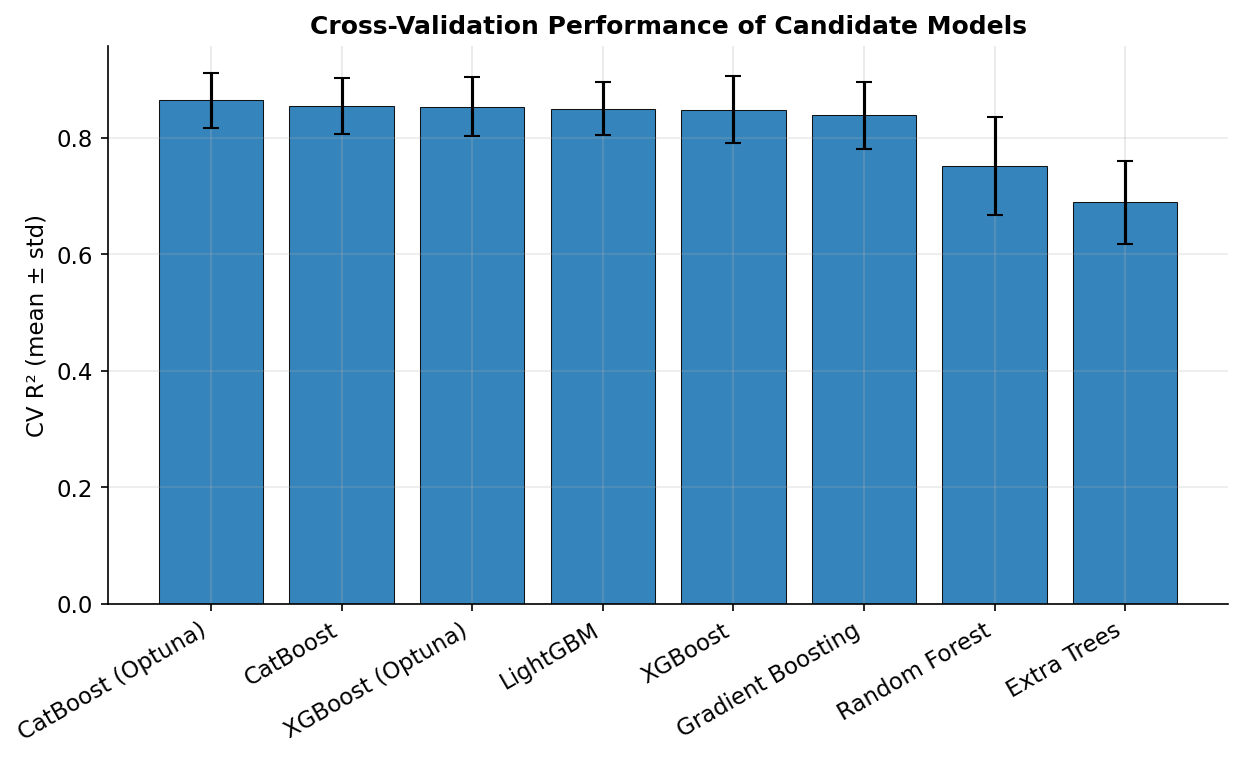

Saved: fig_15_4_cv_comparison.png


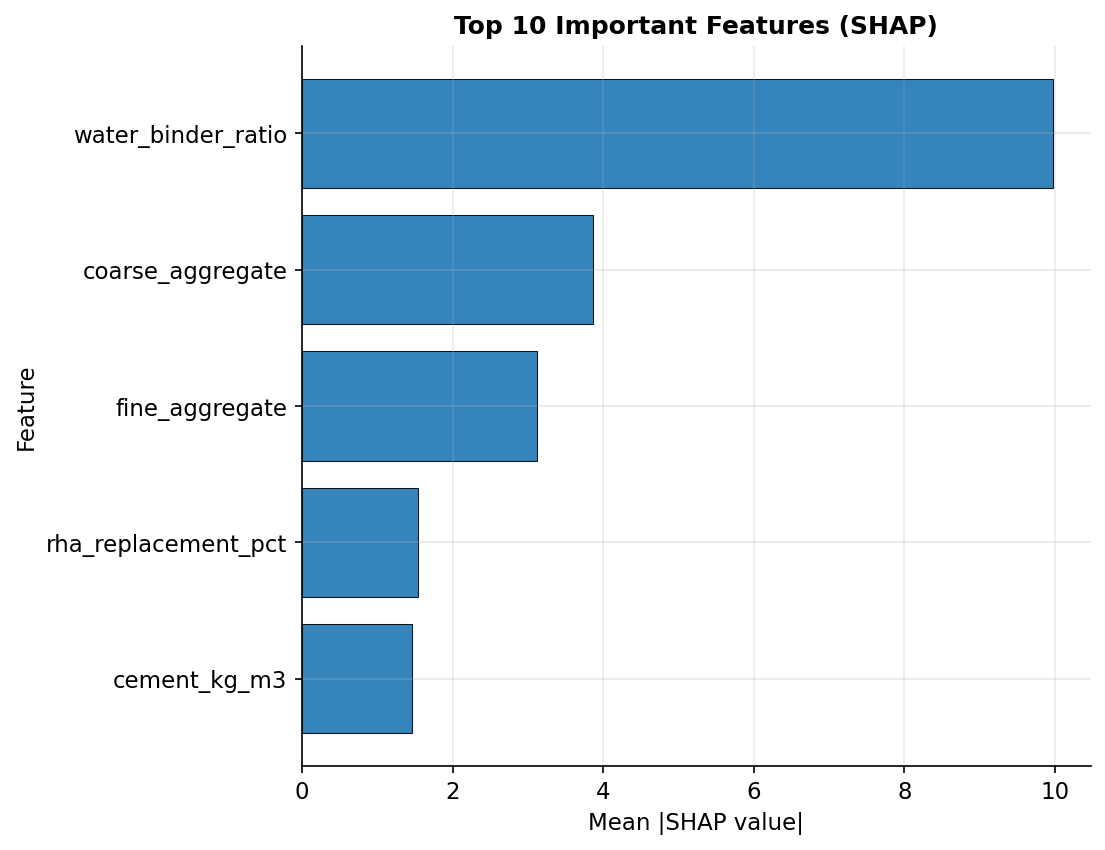

Saved: fig_15_5_shap_importance_publication.png

Step 15 complete.


In [18]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 15: Publication Plots
# =============================================================================
# Requires:
#   eval_df, eval_pipelines, X_test, y_test, pred_store
#   perm_df (optional), shap_df (optional), cv9_df (optional)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Select best model and predictions
# ------------------------------------------------------------
best_model_name = eval_df.iloc[0]["Model"]
best_pipe = eval_pipelines[best_model_name]

if "pred_store" in globals() and best_model_name in pred_store:
    y_pred = np.array(pred_store[best_model_name]["y_test_pred"])
else:
    y_pred = np.array(best_pipe.predict(X_test))

y_true = np.array(y_test)
residuals = y_true - y_pred

print("── 15.1  Publication Plots ─────────────────────────────")
print(f"Best model used: {best_model_name}")

# ------------------------------------------------------------
# Plot 1: Predicted vs Experimental
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6.0))
ax.scatter(y_true, y_pred, s=55, alpha=0.85, edgecolor="black", linewidth=0.4)

lims = [
    min(np.min(y_true), np.min(y_pred)),
    max(np.max(y_true), np.max(y_pred))
]
ax.plot(lims, lims, "--", linewidth=1.5, color="red", label="1:1 line")

# optional regression line
coef = np.polyfit(y_true, y_pred, 1)
xfit = np.linspace(lims[0], lims[1], 100)
yfit = coef[0] * xfit + coef[1]
ax.plot(xfit, yfit, linewidth=1.5, label="Fit")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Experimental Water Absorption (%)", fontsize=11)
ax.set_ylabel("Predicted Water Absorption (%)", fontsize=11)
ax.set_title(f"Predicted vs Experimental — {best_model_name}", fontsize=12, fontweight="bold")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_15_1_predicted_vs_experimental_publication.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_15_1_predicted_vs_experimental_publication.png")

# ------------------------------------------------------------
# Plot 2: Residuals vs Predicted
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(y_pred, residuals, s=55, alpha=0.85, edgecolor="black", linewidth=0.4)
ax.axhline(0, linestyle="--", linewidth=1.5, color="red")

ax.set_xlabel("Predicted Water Absorption (%)", fontsize=11)
ax.set_ylabel("Residuals", fontsize=11)
ax.set_title(f"Residual Plot — {best_model_name}", fontsize=12, fontweight="bold")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_15_2_residual_plot_publication.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_15_2_residual_plot_publication.png")

# ------------------------------------------------------------
# Plot 3: Top model comparison by Test R²
# ------------------------------------------------------------
plot_df = eval_df.head(min(8, len(eval_df))).copy()

fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(plot_df["Model"], plot_df["Test R²"], alpha=0.9, edgecolor="black", linewidth=0.5)

# highlight best
bars[0].set_linewidth(1.2)

for i, v in enumerate(plot_df["Test R²"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

ax.set_ylabel("Test R²", fontsize=11)
ax.set_title("Comparison of Candidate Models", fontsize=12, fontweight="bold")
ax.set_xticklabels(plot_df["Model"], rotation=30, ha="right")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_15_3_model_comparison_test_r2.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_15_3_model_comparison_test_r2.png")

# ------------------------------------------------------------
# Plot 4: CV performance comparison
# ------------------------------------------------------------
if "cv9_df" in globals():
    cv_plot_df = cv9_df.head(min(8, len(cv9_df))).copy()

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    x = np.arange(len(cv_plot_df))

    ax.bar(x, cv_plot_df["CV R² mean"], yerr=cv_plot_df["CV R² std"],
           alpha=0.9, edgecolor="black", linewidth=0.5, capsize=4)

    ax.set_xticks(x)
    ax.set_xticklabels(cv_plot_df["Model"], rotation=30, ha="right")
    ax.set_ylabel("CV R² (mean ± std)", fontsize=11)
    ax.set_title("Cross-Validation Performance of Candidate Models",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_15_4_cv_comparison.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: fig_15_4_cv_comparison.png")

# ------------------------------------------------------------
# Plot 5: Feature importance
# ------------------------------------------------------------
if "shap_df" in globals():
    feat_plot_df = shap_df.head(10).iloc[::-1]

    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    ax.barh(feat_plot_df["Feature"], feat_plot_df["Mean |SHAP|"],
            alpha=0.9, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Mean |SHAP value|", fontsize=11)
    ax.set_ylabel("Feature", fontsize=11)
    ax.set_title("Top 10 Important Features (SHAP)",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_15_5_shap_importance_publication.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: fig_15_5_shap_importance_publication.png")

elif "perm_df" in globals():
    feat_plot_df = perm_df.head(10).iloc[::-1]

    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    ax.barh(feat_plot_df["Feature"], feat_plot_df["Permutation Importance Mean"],
            xerr=feat_plot_df["Permutation Importance Std"],
            alpha=0.9, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Permutation Importance", fontsize=11)
    ax.set_ylabel("Feature", fontsize=11)
    ax.set_title("Top 10 Important Features (Permutation Importance)",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.savefig("/kaggle/working/fig_15_5_permutation_importance_publication.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: fig_15_5_permutation_importance_publication.png")

print("\nStep 15 complete.")

In [19]:
# =============================================================================
# COMPRESSIVE STRENGTH PREDICTION — RHA-BLENDED CONCRETE
# Step 16: Final Output and Export
# =============================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

print("── 16.1  Final Output Export ───────────────────────────")

# ------------------------------------------------------------
# Best model
# ------------------------------------------------------------
best_model_name = eval_df.iloc[0]["Model"]
best_pipe = eval_pipelines[best_model_name]
best_pipe.fit(X_train, y_train)

# ------------------------------------------------------------
# Save trained model safely
# ------------------------------------------------------------
model_path = os.path.join(OUT_DIR, "final_best_model.joblib")
model_saved = False

try:
    joblib.dump(best_pipe, model_path)
    print(f"Saved model: {model_path}")
    model_saved = True
except Exception as e:
    print("Model export skipped.")
    print(f"Reason: {type(e).__name__}: {e}")
    print("Cause: the pipeline contains a local/non-pickleable object such as a class defined inside build_pipeline().")

# ------------------------------------------------------------
# Save core tables
# ------------------------------------------------------------
eval_path = os.path.join(OUT_DIR, "table_final_model_evaluation.csv")
eval_df.to_csv(eval_path, index=False)
print(f"Saved: {eval_path}")

if "cv9_df" in globals():
    cv_path = os.path.join(OUT_DIR, "table_cross_validation_results.csv")
    cv9_df.to_csv(cv_path, index=False)
    print(f"Saved: {cv_path}")

if "stability" in globals():
    stability_path = os.path.join(OUT_DIR, "table_model_stability.csv")
    stability.to_csv(stability_path, index=False)
    print(f"Saved: {stability_path}")

if "error_df" in globals():
    error_path = os.path.join(OUT_DIR, "table_error_analysis.csv")
    error_df.to_csv(error_path, index=False)
    print(f"Saved: {error_path}")

if "perm_df" in globals():
    perm_path = os.path.join(OUT_DIR, "table_permutation_importance.csv")
    perm_df.to_csv(perm_path, index=False)
    print(f"Saved: {perm_path}")

if "shap_df" in globals():
    shap_path = os.path.join(OUT_DIR, "table_shap_importance.csv")
    shap_df.to_csv(shap_path, index=False)
    print(f"Saved: {shap_path}")

if "aic_df" in globals():
    aic_path = os.path.join(OUT_DIR, "table_aic_bic_comparison.csv")
    aic_df.to_csv(aic_path, index=False)
    print(f"Saved: {aic_path}")

if "sensitivity_df" in globals() and len(sensitivity_df) > 0:
    sens_path = os.path.join(OUT_DIR, "table_sensitivity_analysis.csv")
    sensitivity_df.to_csv(sens_path, index=False)
    print(f"Saved: {sens_path}")

if "taylor_df" in globals():
    taylor_path = os.path.join(OUT_DIR, "table_taylor_statistics.csv")
    taylor_df.to_csv(taylor_path, index=False)
    print(f"Saved: {taylor_path}")

if "uncertainty_df" in globals():
    uncertainty_path = os.path.join(OUT_DIR, "table_prediction_uncertainty.csv")
    uncertainty_df.to_csv(uncertainty_path, index=False)
    print(f"Saved: {uncertainty_path}")

# ------------------------------------------------------------
# Save predictions of best model
# ------------------------------------------------------------
y_train_pred = best_pipe.predict(X_train)
y_test_pred = best_pipe.predict(X_test)

train_pred_df = pd.DataFrame({
    "Observed_Train": np.array(y_train),
    "Predicted_Train": np.array(y_train_pred),
    "Residual_Train": np.array(y_train) - np.array(y_train_pred)
})
train_pred_path = os.path.join(OUT_DIR, "table_train_predictions_best_model.csv")
train_pred_df.to_csv(train_pred_path, index=False)
print(f"Saved: {train_pred_path}")

test_pred_df = pd.DataFrame({
    "Observed_Test": np.array(y_test),
    "Predicted_Test": np.array(y_test_pred),
    "Residual_Test": np.array(y_test) - np.array(y_test_pred)
})
test_pred_path = os.path.join(OUT_DIR, "table_test_predictions_best_model.csv")
test_pred_df.to_csv(test_pred_path, index=False)
print(f"Saved: {test_pred_path}")

# ------------------------------------------------------------
# Save metadata summary as JSON
# ------------------------------------------------------------
summary_payload = {
    "best_model_name": str(best_model_name),
    "model_exported": model_saved,
    "n_train_samples": int(len(X_train)),
    "n_test_samples": int(len(X_test)),
    "n_features": int(X_train.shape[1]) if hasattr(X_train, "shape") else None,
}

best_row = eval_df.iloc[0].to_dict()
for k, v in best_row.items():
    if isinstance(v, (np.integer,)):
        summary_payload[k] = int(v)
    elif isinstance(v, (np.floating,)):
        summary_payload[k] = float(v)
    else:
        summary_payload[k] = v

summary_path = os.path.join(OUT_DIR, "final_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary_payload, f, indent=2)
print(f"Saved: {summary_path}")

# ------------------------------------------------------------
# Final publication-ready summary table
# ------------------------------------------------------------
summary_cols = [c for c in [
    "Model", "Train R²", "Test R²", "Test RMSE", "Test MAE",
    "Test MAPE (%)", "Test NSE", "Test AIC", "Test BIC"
] if c in eval_df.columns]

final_summary_table = eval_df[summary_cols].copy()
final_summary_path = os.path.join(OUT_DIR, "table_publication_summary.csv")
final_summary_table.to_csv(final_summary_path, index=False)
print(f"Saved: {final_summary_path}")

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------
print("\n── 16.2  Final Summary ─────────────────────────────────")
print(f"Best final model: {best_model_name}")

if "Test R²" in eval_df.columns:
    print(f"Test R²   : {eval_df.iloc[0]['Test R²']}")
if "Test RMSE" in eval_df.columns:
    print(f"Test RMSE : {eval_df.iloc[0]['Test RMSE']}")
if "Test MAE" in eval_df.columns:
    print(f"Test MAE  : {eval_df.iloc[0]['Test MAE']}")
if "Test MAPE (%)" in eval_df.columns:
    print(f"Test MAPE : {eval_df.iloc[0]['Test MAPE (%)']}")

if not model_saved:
    print("\nModel file was not saved because the pipeline is not pickleable in its current form.")
    print("To save it, move WinsorClip out of build_pipeline() into a top-level class, rebuild the pipelines, and rerun export.")

print("\nAll available final outputs exported successfully.")
print("Step 16 complete.")

── 16.1  Final Output Export ───────────────────────────
Model export skipped.
Reason: PicklingError: Can't pickle <class '__main__.build_pipeline.<locals>.WinsorClip'>: it's not found as __main__.build_pipeline.<locals>.WinsorClip
Cause: the pipeline contains a local/non-pickleable object such as a class defined inside build_pipeline().
Saved: /kaggle/working/table_final_model_evaluation.csv
Saved: /kaggle/working/table_cross_validation_results.csv
Saved: /kaggle/working/table_model_stability.csv
Saved: /kaggle/working/table_error_analysis.csv
Saved: /kaggle/working/table_permutation_importance.csv
Saved: /kaggle/working/table_shap_importance.csv
Saved: /kaggle/working/table_aic_bic_comparison.csv
Saved: /kaggle/working/table_sensitivity_analysis.csv
Saved: /kaggle/working/table_taylor_statistics.csv
Saved: /kaggle/working/table_prediction_uncertainty.csv
Saved: /kaggle/working/table_train_predictions_best_model.csv
Saved: /kaggle/working/table_test_predictions_best_model.csv
Saved: /